# Reach for Change - Predicting Donor Response to Optimize Outreach for Social Good

# Group Member Contribution

All four members contributed equally across every section — EDA, preprocessing, modelling, tuning, threshold optimisation, deployment, and the open-ended analysis — through joint working sessions with collective decisions.

**Estimated avg contribution: 100% per member.**

| Member | Student ID |
|--------|-----------|
| Alexandre Duarte | 20250961 |
| Diogo Merca | 20250191 |
| Madalina Noje | 20250888 |
| Matilde Cordeiro | 20250202 |

# Abstract

The Civic Support Alliance (CSA) seeks to replace mass solicitation with targeted outreach: *will this person donate if contacted?* We address this via supervised binary classification on **13,560 records × 41 features** (75/25 imbalance toward non-donors), evaluated by **F1-score** — accuracy is uninformative under imbalance and F1 is the Kaggle metric.

**Methodology.** Stratified 80/20 holdout reserved upfront; every preprocessing step (invalid handling, imputation, feature engineering, log transformation, scaling, encoding, filter FS) fitted on training only and applied to validation. Explicit step-by-step transformations (no sklearn `Pipeline`) expose intermediate diagnostics.

**Modelling.** Eight algorithms across five families (probabilistic, discriminant, linear, tree, ensemble) screened with literature-informed defaults. Four finalists selected via joint F1 + error complementarity (Kuncheva & Whitaker, 2003): LR, GB, DT, GNB. Each tuned by **Random + Grid Search with 5-fold CV** and **robust selection** between Screening/Random/Grid on validation (mitigates CV optimization bias; Cawley & Talbot, 2010). Decision thresholds optimised via `TunedThresholdClassifierCV` on train.

**Result.** The deployed model — a **stacking ensemble with passthrough and threshold tuning** — achieves **F1 val = 0.416** (threshold = 0.415; +0.035 F1 over the default 0.5 cut-off) and **Kaggle public F1 = 0.423**, slightly above the validation estimate, confirming the absence of overfitting. An extensive sensitivity analysis (alternative architectures, expanded hyperparameter ranges, regularisation schemes, metrics, and feature-count sweeps) failed to surpass this, with all variants converging to F1 ≈ 0.41 — evidence the task is **data-limited** (maximum mutual information of 0.014), not model-limited, consistent with KDD Cup '98-style donor data (Cacciarelli & Boresta, 2022). The open-en

# Setup

## Imports

In [ ]:
# All imports consolidated — single source of truth.
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy, pearsonr, loguniform, randint, uniform

# Sklearn — preprocessing & encoding
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler

# Sklearn — feature selection
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif

# Sklearn — model selection & evaluation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    GridSearchCV,
    TunedThresholdClassifierCV,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    roc_curve,
    roc_auc_score,
)

# Sklearn — baselines & models
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)


# Reproducibility configuration — applied globally.
GLOBAL_SEED = 42
N_JOBS = 1
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
warnings.filterwarnings('ignore')

print(f"Setup complete (seed={GLOBAL_SEED}, n_jobs={N_JOBS}).")

Setup complete (seed=42, n_jobs=1).


In [ ]:
# Visual settings — unified palette across all plots.
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Palette — used everywhere for consistency.
COLOR_PRIMARY   = '#2E86AB'   # main bars, post-action values
COLOR_SECONDARY = '#A8DADC'   # secondary bars, pre-action / contrast
COLOR_ACCENT    = '#E63946'   # highlights, important values
COLOR_NEUTRAL   = '#36454F'   # text annotations, neutral details
COLOR_BLACK     = 'black'     # edges and reference lines

CMAP_DIVERGING  = 'coolwarm'  # correlation-style heatmaps (signed values)
CMAP_SEQUENTIAL = 'Blues'     # association-style heatmaps (positive only)

## Loading Data

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/DM2_Project/'
df_train  = pd.read_csv(BASE_PATH + 'donors_train.csv')
df_kaggle = pd.read_csv(BASE_PATH + 'donors_test.csv')

print(f"df_train  : {df_train.shape}")
print(f"df_kaggle : {df_kaggle.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_train  : (13560, 41)
df_kaggle : (5812, 40)


# I. Introduction

## Problem Statement

> Despite the growing number of charitable causes, repeated and untargeted solicitations have led to **donor fatigue**, reducing engagement and long-term support for humanitarian initiatives.
>
> The **Civic Support Alliance (CSA)** seeks to modernize its outreach strategy by identifying individuals most likely to donate when contacted. This project transitions from traditional mass-outreach to a **data-driven targeted strategy**.

## Project Objective

The primary goal is to develop a **supervised learning classification model** to predict donor response. This enables the CSA to focus outreach efforts on high-probability leads, maximising campaign efficiency while minimising unnecessary contact and donor disengagement.

## Research Question

> *"Based on historical and demographic profiles, what is the probability of a specific individual donating if contacted during this campaign?"*

## Methodology Overview

Project follows **CRISP-DM** (Chapman et al., 2000).

![CRISP-DM Process](https://stellarconsulting.co.nz/wp-content/uploads/2017/08/CRISP-DM_Process_1000x600.jpg)

*Figure 1 — CRISP-DM phases. Adapted from Stellar Consulting.*

**Pipeline:**

1. **Stratified 80/20 holdout** — reserved before any analysis.
2. **EDA** on training only — missing patterns, distributions, redundancy (Spearman + Theil's U), target signal.
3. **Step-by-step preprocessing** — invalid handling → imputation → feature engineering → log transformation → scaling → encoding. Each step fitted on train, applied to val; intermediate state inspectable.
4. **Filter FS** (3 stages) — Variance Threshold → Correlation Redundancy (Hall, 1999) → SelectKBest with Mutual Information (Brown et al., 2012).
5. **Screening** — 8 algorithms covering probabilistic, discriminant, linear, tree, and ensemble (bagging, boosting) families, with literature-informed hyperparameters. Symmetric imbalance handling: `class_weight='balanced'`, `sample_weight`, or balanced priors.
6. **Finalist selection** — F1 + error complementarity (Pearson correlation on val error vectors; Kuncheva & Whitaker, 2003).
7. **Hyperparameter tuning** — combined Random + Grid Search with 5-fold StratifiedKFold on train. **Robust selection** between Screening, Random and Grid candidates on val mitigates CV optimization bias (Cawley & Talbot, 2010).
8. **Threshold optimisation** — `TunedThresholdClassifierCV` (sklearn ≥1.5), 5-fold CV on train only.
9. **Final evaluation on val**, then refit on `X_train + X_val` for Kaggle submission.

## Evaluation Strategy

### Primary metric — F1-score

Under 75/25 imbalance, F1 balances false negatives (missed donors) and false positives (wasted outreach). Accuracy is uninformative (a majority predictor achieves ~75% accuracy with zero donors identified). F1 is also the Kaggle competition metric.

### Validation — stratified 80/20 holdout

Single stratified holdout: **10,848 train + 2,712 val (~678 positive)**. Val is large enough for stable F1 estimation, small enough to permit step-by-step diagnostics. **Val is touched only for final model evaluation** — hyperparameter and threshold optimisation use 5-fold CV on training. After model selection, refit on `X_train + X_val` before Kaggle submission.

### Anti-leakage protocol

Every sklearn transformer (imputer, scaler, encoder, selector):
1. Instantiated with config.
2. `.fit(X_train_clean)` learns parameters (medians, modes, IQRs, vocabularies).
3. `.transform()` applied to both `X_train_clean` and `X_val_clean`.

No sklearn `Pipeline` — each step is a separate cell, so `statistics_`, `center_`, `scale_`, `categories_` are inspectable. This is the holdout equivalent of what `Pipeline` automates inside CV: same anti-leakage guarantee, more transparency.

### Baselines

`DummyClassifier` benchmarks (`strategy='most_frequent'` ZeroR; `strategy='stratified'` random) confirm that any candidate model is genuinely learning rather than exploiting the class distribution.

### Threshold optimisation

The F1-optimal threshold is rarely 0.5 under imbalance. `TunedThresholdClassifierCV` (sklearn ≥1.5) runs 5-fold CV on training to identify it. Default and tuned-threshold F1 are both reported on val to quantify the gain.

# II. Data Exploration and Preprocessing

## Feature Type Classification (a priori, from codebook)

We classify all features into four mutually exclusive types based solely on the **codebook** (documented data dictionary), not on empirical inspection of any partition. This classification drives all subsequent preprocessing decisions (invalid handling, imputation strategy, encoding, scaling) and is defined once here to ensure consistency across the notebook.

## A. Exploratory Data Analysis

### Dataset Metadata & Features

Features organised around the **RFM framework** (Hughes, 1994): **R**ecency (how recently the donor gave), **F**requency (how often), **M**onetary (how much). All definitions follow the project codebook.

**Demographics**
- `DONOR_AGE` — age as of last year's mail solicitation
- `DONOR_GENDER` — gender of individual
- `CHILDREN` — number of children the individual has
- `HOME_OWNER` — H if homeowner, U if unknown
- `URBANICITY` — location type: U = Urban, C = City, T = Town, R = Rural, S = Suburban
- `SES` — socio-economic profile, 1 of 5 demographic codes
- `INCOME_GROUP` — income level, 1 of 7 codes
- `WEALTH_RATING` — wealth group, 1 of 10 codes

**Recency**
- `MONTHS_SINCE_LAST_GIFT` — months since most recent donation
- `MONTHS_SINCE_FIRST_GIFT` — months since first donation
- `MONTHS_SINCE_LAST_PROM_RESP` — months since last response to a promotion
- `RECENCY_STATUS_96NK` — donor status: A (active), E (inactive), F (first-time), L (lapsing), N (new), S (star)

**Frequency**
- `LIFETIME_GIFT_COUNT` — total number of donations
- `FREQUENCY_STATUS_97NK` — number of donations in the last period (window varies by recency group)
- `RECENT_RESPONSE_COUNT` — responses to any promotion in the last four years
- `RECENT_CARD_RESPONSE_COUNT` — responses to card solicitations in the last four years
- `RECENT_RESPONSE_PROP` — proportion of solicitations responded to in the last four years
- `RECENT_CARD_RESPONSE_PROP` — responses to card solicitations in the last four years (proportion)

**Monetary**
- `LAST_GIFT_AMT` — amount of the most recent donation
- `LIFETIME_GIFT_AMOUNT` — total lifetime donation amount
- `LIFETIME_MAX_GIFT_AMT` — maximum single donation
- `LIFETIME_MIN_GIFT_AMT` — minimum single donation
- `FILE_CARD_GIFT` — lifetime average donation to all card solicitations
- `RECENT_AVG_GIFT_AMT` — average donation in the last four years
- `RECENT_AVG_CARD_GIFT_AMT` — average card donation in the last four years

**Promotion**
- `LIFETIME_PROM` — total promotions (card or other) sent
- `LIFETIME_CARD_PROM` — total card promotions sent
- `NUMBER_PROM_12` — promotions sent in the last 12 months
- `CARD_PROM_12` — card promotions sent in the last 12 months

**Donor Status**
- `PEP_STAR` — achieved STAR status (donated to 3 consecutive campaigns)
- `RECENT_STAR_STATUS` — achieved STAR within the last 4 years

**Neighbourhood** (census-derived, area-level, in $100's where monetary)
- `MEDIAN_HOME_VALUE` — area median home value
- `MEDIAN_HOUSEHOLD_INCOME` — area median household income
- `PER_CAPITA_INCOME` — area per-capita income
- `PCT_OWNER_OCCUPIED` — % owner-occupied housing nearby
- `PCT_ATTRIBUTE1` — % neighbourhood male active military
- `PCT_ATTRIBUTE2` — % neighbourhood male veterans
- `PCT_ATTRIBUTE3` — % neighbourhood Vietnam veterans
- `PCT_ATTRIBUTE4` — % neighbourhood WW2 veterans

### Target Variable Analysis (Pre-Split)

Inspecting the class distribution before splitting confirms the imbalance we must account for in both the stratification of the holdout and the choice of evaluation metric.

In [ ]:
# Feature type classification — defined a priori from the codebook (mutually exclusive, exhaustive)
FEATURE_TYPES = {
    'binary': [
        'PEP_STAR', 'RECENT_STAR_STATUS',
    ],
    'categorical': [
        'DONOR_GENDER', 'HOME_OWNER', 'URBANICITY', 'RECENCY_STATUS_96NK',
    ],
    'ordinal': [
        'SES', 'CHILDREN', 'INCOME_GROUP', 'WEALTH_RATING', 'FREQUENCY_STATUS_97NK',
    ],
    'continuous': [
        # Recency
        'DONOR_AGE', 'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT',
        'MONTHS_SINCE_LAST_PROM_RESP',
        # Frequency
        'LIFETIME_GIFT_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_PROP', 'RECENT_CARD_RESPONSE_PROP',
        # Monetary
        'LAST_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_MAX_GIFT_AMT',
        'LIFETIME_MIN_GIFT_AMT', 'FILE_CARD_GIFT', 'RECENT_AVG_GIFT_AMT',
        'RECENT_AVG_CARD_GIFT_AMT',
        # Promotion
        'LIFETIME_PROM', 'LIFETIME_CARD_PROM', 'NUMBER_PROM_12', 'CARD_PROM_12',
        # Neighbourhood
        'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'PCT_OWNER_OCCUPIED',
        'PER_CAPITA_INCOME', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2',
        'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
    ],
}

# Convenience aliases for each type
BINARY_FEATURES      = FEATURE_TYPES['binary']
CATEGORICAL_FEATURES = FEATURE_TYPES['categorical']
ORDINAL_FEATURES     = FEATURE_TYPES['ordinal']
CONTINUOUS_FEATURES  = FEATURE_TYPES['continuous']

# Sanity check — every feature (except ID and target) must be classified exactly once
expected   = set(df_train.columns) - {'CONTROL_NUMBER', 'TARGET_B'}
classified = set(BINARY_FEATURES + CATEGORICAL_FEATURES + ORDINAL_FEATURES + CONTINUOUS_FEATURES)
assert not (expected - classified), f"Unclassified features: {expected - classified}"
assert not (classified - expected), f"Classified but not in dataset: {classified - expected}"

# Report the classification counts
print(f"Feature classification: {len(classified)} features, all accounted for.")
print(f"  Binary     : {len(BINARY_FEATURES)}  -> {BINARY_FEATURES}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}  -> {CATEGORICAL_FEATURES}")
print(f"  Ordinal    : {len(ORDINAL_FEATURES)}  -> {ORDINAL_FEATURES}")
print(f"  Continuous : {len(CONTINUOUS_FEATURES)}")

Feature classification: 39 features, all accounted for.
  Binary     : 2  -> ['PEP_STAR', 'RECENT_STAR_STATUS']
  Categorical: 4  -> ['DONOR_GENDER', 'HOME_OWNER', 'URBANICITY', 'RECENCY_STATUS_96NK']
  Ordinal    : 5  -> ['SES', 'CHILDREN', 'INCOME_GROUP', 'WEALTH_RATING', 'FREQUENCY_STATUS_97NK']
  Continuous : 28


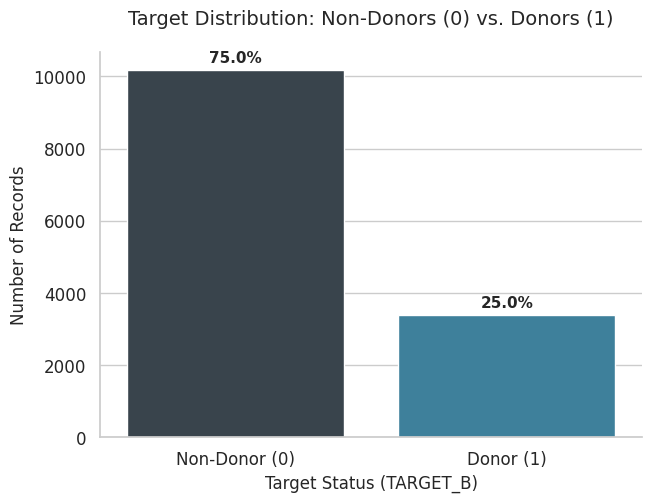

Imbalance ratio: 3.00 : 1


In [ ]:
# Compute target class counts and percentages
target_counts = df_train['TARGET_B'].value_counts()
target_pct    = df_train['TARGET_B'].value_counts(normalize=True) * 100

# Bar plot of the class distribution
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    x=target_counts.index, y=target_counts.values,
    hue=target_counts.index, palette=[COLOR_NEUTRAL, COLOR_PRIMARY],
    legend=False, ax=ax,
)

# Annotate each bar with its percentage
for i, p in enumerate(ax.patches):
    ax.annotate(
        f'{target_pct.iloc[i]:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', xytext=(0, 9),
        textcoords='offset points', fontsize=11, fontweight='bold',
    )

plt.title('Target Distribution: Non-Donors (0) vs. Donors (1)', pad=20)
plt.ylabel('Number of Records')
plt.xlabel('Target Status (TARGET_B)')
plt.xticks(ticks=[0, 1], labels=['Non-Donor (0)', 'Donor (1)'])
sns.despine()
plt.show()

# Report the imbalance ratio
print(f"Imbalance ratio: {target_counts[0]/target_counts[1]:.2f} : 1")

### Duplicate Check (Pre-Split)

Duplicates must be checked **before** the train/validation split. If duplicate rows exist and end up split across both partitions, the validation score is inflated by leakage (the model memorises a row in training and "predicts" it in validation).

In [ ]:
# Duplicates check — done before the split to detect potential leakage
n_dup = df_train.drop(columns=['CONTROL_NUMBER']).duplicated().sum()
print(f"Duplicate rows in df_train (excluding ID): {n_dup}")

Duplicate rows in df_train (excluding ID): 0


### Train/Validation Split

**Stratified 80/20 holdout**, performed *before* any feature-level exploration. Three methodological choices follow from class imbalance and the no-leakage protocol:

- **Stratified sampling** preserves 75/25 class proportion across both partitions.
- **Single holdout** is the primary validation mechanism (5-fold CV on train is used internally for tuning and threshold selection) — preprocessing decisions, model selection, and final F1 reporting all use this val. The Kaggle test set is the true generalisation estimate.
- **No leakage** — all subsequent transformers (imputers, scalers, encoders, selectors) are fitted exclusively on `X_train` and applied to `X_val`.

In [ ]:
# Separate features and target
X = df_train.drop(columns=['CONTROL_NUMBER', 'TARGET_B'])
y = df_train['TARGET_B']

# Stratified 80/20 holdout split (fixed seed for reproducibility)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=GLOBAL_SEED,
)

# Report shapes and class proportions
print(f"Full training data : {len(df_train)} rows")
print(f"X_train            : {X_train.shape[0]} rows | Donor %: {y_train.mean():.1%}")
print(f"X_val              : {X_val.shape[0]} rows | Donor %: {y_val.mean():.1%}")
print(f"X_kaggle (test)    : {df_kaggle.shape[0]} rows | (no target)")

# Verify train and Kaggle sets share the exact same feature columns
kaggle_features   = df_kaggle.drop(columns=['CONTROL_NUMBER']).columns
missing_in_kaggle = set(X_train.columns) - set(kaggle_features)
extra_in_kaggle   = set(kaggle_features) - set(X_train.columns)
assert not missing_in_kaggle and not extra_in_kaggle, \
    f"Column mismatch — missing: {missing_in_kaggle}, extra: {extra_in_kaggle}"
print(f"\nColumn alignment with df_kaggle: OK ({len(kaggle_features)} features)")

Full training data : 13560 rows
X_train            : 10848 rows | Donor %: 25.0%
X_val              : 2712 rows | Donor %: 25.0%
X_kaggle (test)    : 5812 rows | (no target)

Column alignment with df_kaggle: OK (39 features)


### Shape, Column Types, Duplicates

In [ ]:
# Quick look at the data
pd.concat([X_train.head(), X_train.tail()])

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
9846,5.0,3.0,NaN,M,2.0,4.0,U,NaN,9.0,7.0,...,4.00,-16.817445,2.000000,0.667,3.0,0.429000,0.0,1,S,NaN
3371,5.0,1.0,79.0,M,11.0,3.0,U,1.0,10.0,26.0,...,10.00,10.000000,6.000000,0.545,10.0,0.500000,1.0,3,C,8.0
11627,6.0,0.0,30.0,M,4.0,1.0,H,7.0,20.0,21.0,...,20.00,20.000000,2.000000,0.200,2.0,0.105000,0.0,1,S,9.0
7629,6.0,1.0,65.0,M,11.0,4.0,H,5.0,5.0,32.0,...,6.00,6.800000,1.000000,0.100,5.0,0.278000,1.0,2,C,7.0
9391,5.0,2.0,60.0,F,23.0,4.0,H,1.0,3.0,32.0,...,4.13,3.910000,6.336365,0.727,11.0,0.579000,1.0,3,R,5.0
3714,6.0,4.0,51.0,F,2.0,2.0,H,1.0,12.0,12.0,...,15.00,14.000000,2.000000,0.250,3.0,0.531921,0.0,2,R,NaN
11160,4.0,1.0,45.0,F,5.0,1.0,H,3.0,10.0,24.0,...,10.00,10.000000,1.000000,0.111,2.0,0.111000,6.0,2,S,7.0
6817,6.0,0.0,72.0,M,5.0,2.0,H,2.0,10.0,29.0,...,0.00,12.500000,0.000000,0.000,2.0,0.095000,5.0,3,NaN,3.0
4185,5.0,0.0,42.0,F,13.0,4.0,H,5.0,4.0,30.0,...,4.00,4.330000,3.000000,0.300,6.0,0.286000,1.0,2,R,NaN
6875,4.0,3.0,63.0,F,0.0,1.0,H,5.0,15.0,8.0,...,0.00,15.000000,0.000000,0.000,1.0,0.077000,0.0,2,T,NaN


In [ ]:
# Summary statistics for numerical features
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
CARD_PROM_12,10638.0,5.374524,1.319628,1.000000,5.000,6.000,6.000,17.000000
CHILDREN,10636.0,1.986453,1.459620,-2.299824,1.000,2.000,3.000,6.220526
DONOR_AGE,8027.0,58.763063,17.528972,0.000000,46.000,59.000,73.000,108.946450
FILE_CARD_GIFT,10645.0,5.231541,4.846342,-10.098570,2.000,4.000,8.000,32.000000
FREQUENCY_STATUS_97NK,10625.0,1.993952,1.149303,-1.363824,1.000,2.000,3.000,5.279946
INCOME_GROUP,8206.0,3.922317,1.949562,-1.737977,2.000,4.000,5.000,9.503280
LAST_GIFT_AMT,10638.0,16.642003,13.205370,-21.833600,10.000,15.000,20.000,450.000000
LIFETIME_CARD_PROM,10648.0,18.595363,8.932039,-7.205341,11.000,18.000,26.000,55.000000
LIFETIME_GIFT_AMOUNT,10618.0,104.488542,111.451719,-243.255927,41.000,79.000,133.000,3775.000000
LIFETIME_GIFT_COUNT,10642.0,9.947966,9.079680,-18.629060,4.000,8.000,14.000,95.000000


In [ ]:
# Dataset dimensions
print(f"Rows: {X_train.shape[0]} | Columns: {X_train.shape[1]}")

# Split columns by inferred dtype
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

# Report counts per inferred type
print(f"\nNumerical features  : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Rows: 10848 | Columns: 39

Numerical features  : 34
Categorical features: 5


### Missing Values

In [ ]:
# Count and percentage of missing values per feature
missing_counts = X_train.isna().sum()
missing_pct    = (missing_counts / len(X_train)) * 100

# Keep only features with missing values, sorted descending
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("--- Missing Values in X_train ---")
print(missing_df.round(2))

--- Missing Values in X_train ---
                             Missing Count  Missing %
WEALTH_RATING                         5002      46.11
DONOR_AGE                             2821      26.00
INCOME_GROUP                          2642      24.35
MONTHS_SINCE_LAST_PROM_RESP            364       3.36
LIFETIME_MIN_GIFT_AMT                  232       2.14
LIFETIME_GIFT_AMOUNT                   230       2.12
SES                                    230       2.12
PCT_ATTRIBUTE4                         226       2.08
HOME_OWNER                             226       2.08
MONTHS_SINCE_LAST_GIFT                 225       2.07
MEDIAN_HOUSEHOLD_INCOME                224       2.06
FREQUENCY_STATUS_97NK                  223       2.06
PCT_ATTRIBUTE3                         222       2.05
NUMBER_PROM_12                         222       2.05
RECENT_RESPONSE_PROP                   222       2.05
RECENT_RESPONSE_COUNT                  219       2.02
PCT_ATTRIBUTE1                         219      

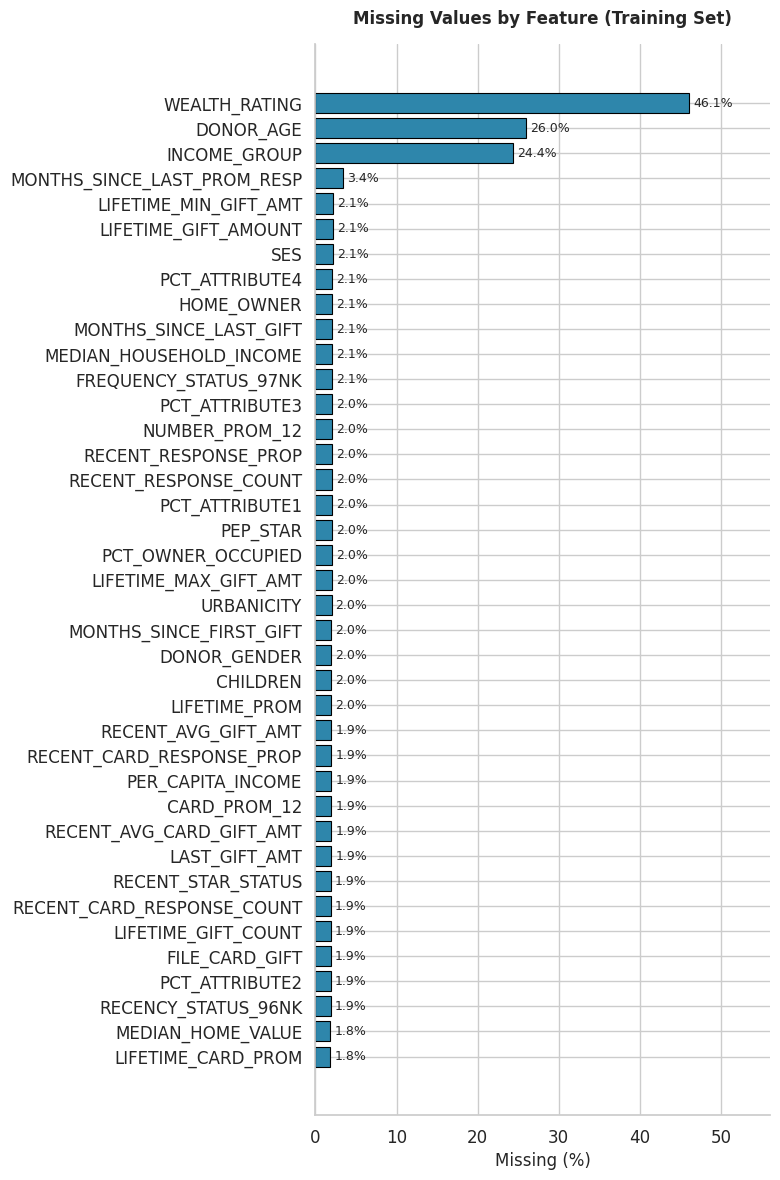

In [ ]:
# Horizontal bar chart of missing-value percentage per feature
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(missing_df.index, missing_df['Missing %'],
        color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, linewidth=0.8)

ax.set_title('Missing Values by Feature (Training Set)', pad=15, fontsize=12, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.set_xlim(0, missing_df['Missing %'].max() + 10)

# Label each bar with its percentage
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.gca().invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

### Variance and Quasi-constant

In [ ]:
# Quasi-constant analysis — variance and dominance of the most frequent value
variance_stats = []
for col in num_cols:
    series = X_train[col].dropna()
    counts = series.value_counts(normalize=True)
    if not counts.empty:
        variance_stats.append({
            'Feature'           : col,
            'Variance'          : round(series.var(), 4),
            'Top value'         : round(counts.index[0], 3),
            'Top value freq (%)': round(counts.iloc[0] * 100, 2),
        })

variance_df = (pd.DataFrame(variance_stats)
                 .sort_values('Top value freq (%)', ascending=False)
                 .reset_index(drop=True))

# Show the features most dominated by a single value
print("--- Quasi-constant analysis (Top value frequency) ---")
print(variance_df[['Feature', 'Top value', 'Top value freq (%)']].head(10).to_string(index=False))

# Flag numerical features where one value covers > 90% of rows
quasi = variance_df[variance_df['Top value freq (%)'] > 90]
if not quasi.empty:
    print("\nFeatures with top value frequency > 90%:")
    for _, row in quasi.iterrows():
        print(f"  {row['Feature']:35s}: {row['Top value freq (%)']:.1f}% are {row['Top value']}")
else:
    print("\nNo numerical features found with top value frequency > 90%.")

# Same dominance check for categorical features
print("\n--- Categorical features (Top value frequency) ---")
for col in cat_cols:
    counts = X_train[col].value_counts(normalize=True)
    if not counts.empty:
        print(f"  {col:35s}: {counts.iloc[0]*100:.1f}% are '{counts.index[0]}'")

--- Quasi-constant analysis (Top value frequency) ---
                   Feature  Top value  Top value freq (%)
            PCT_ATTRIBUTE1        0.0               76.35
        RECENT_STAR_STATUS        0.0               68.01
              CARD_PROM_12        6.0               52.94
                  PEP_STAR        1.0               49.72
     FREQUENCY_STATUS_97NK        1.0               46.20
     LIFETIME_MIN_GIFT_AMT        5.0               35.69
RECENT_CARD_RESPONSE_COUNT        1.0               32.68
            NUMBER_PROM_12       13.0               25.32
     RECENT_RESPONSE_COUNT        2.0               25.07
              INCOME_GROUP        5.0               21.25

No numerical features found with top value frequency > 90%.

--- Categorical features (Top value frequency) ---
  DONOR_GENDER                       : 54.3% are 'F'
  HOME_OWNER                         : 54.3% are 'H'
  RECENCY_STATUS_96NK                : 61.4% are 'A'
  SES                               

### Donor Behavior Analysis: RFM & Demographics vs. Target

In [ ]:
# Feature groupings for organised plotting (purely cosmetic — for the EDA visuals)
feature_groups = {
    'Demographics': [
        'DONOR_AGE', 'DONOR_GENDER', 'CHILDREN', 'HOME_OWNER',
        'URBANICITY', 'SES', 'INCOME_GROUP', 'WEALTH_RATING',
    ],
    'Recency': [
        'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT',
        'MONTHS_SINCE_LAST_PROM_RESP', 'RECENCY_STATUS_96NK',
    ],
    'Frequency': [
        'LIFETIME_GIFT_COUNT', 'FREQUENCY_STATUS_97NK',
        'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT',
        'RECENT_RESPONSE_PROP', 'RECENT_CARD_RESPONSE_PROP',
    ],
    'Monetary': [
        'LAST_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_MAX_GIFT_AMT',
        'LIFETIME_MIN_GIFT_AMT', 'FILE_CARD_GIFT', 'RECENT_AVG_GIFT_AMT',
        'RECENT_AVG_CARD_GIFT_AMT',
    ],
    'Promotion': [
        'LIFETIME_PROM', 'LIFETIME_CARD_PROM', 'NUMBER_PROM_12', 'CARD_PROM_12',
    ],
    'Donor Status': BINARY_FEATURES,  # uses the central definition
    'Neighbourhood': [
        'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'PCT_OWNER_OCCUPIED',
        'PER_CAPITA_INCOME', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2',
        'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
    ],
}

# Features plotted as bar charts (any non-continuous feature)
to_plot_as_bars = BINARY_FEATURES + CATEGORICAL_FEATURES + ORDINAL_FEATURES

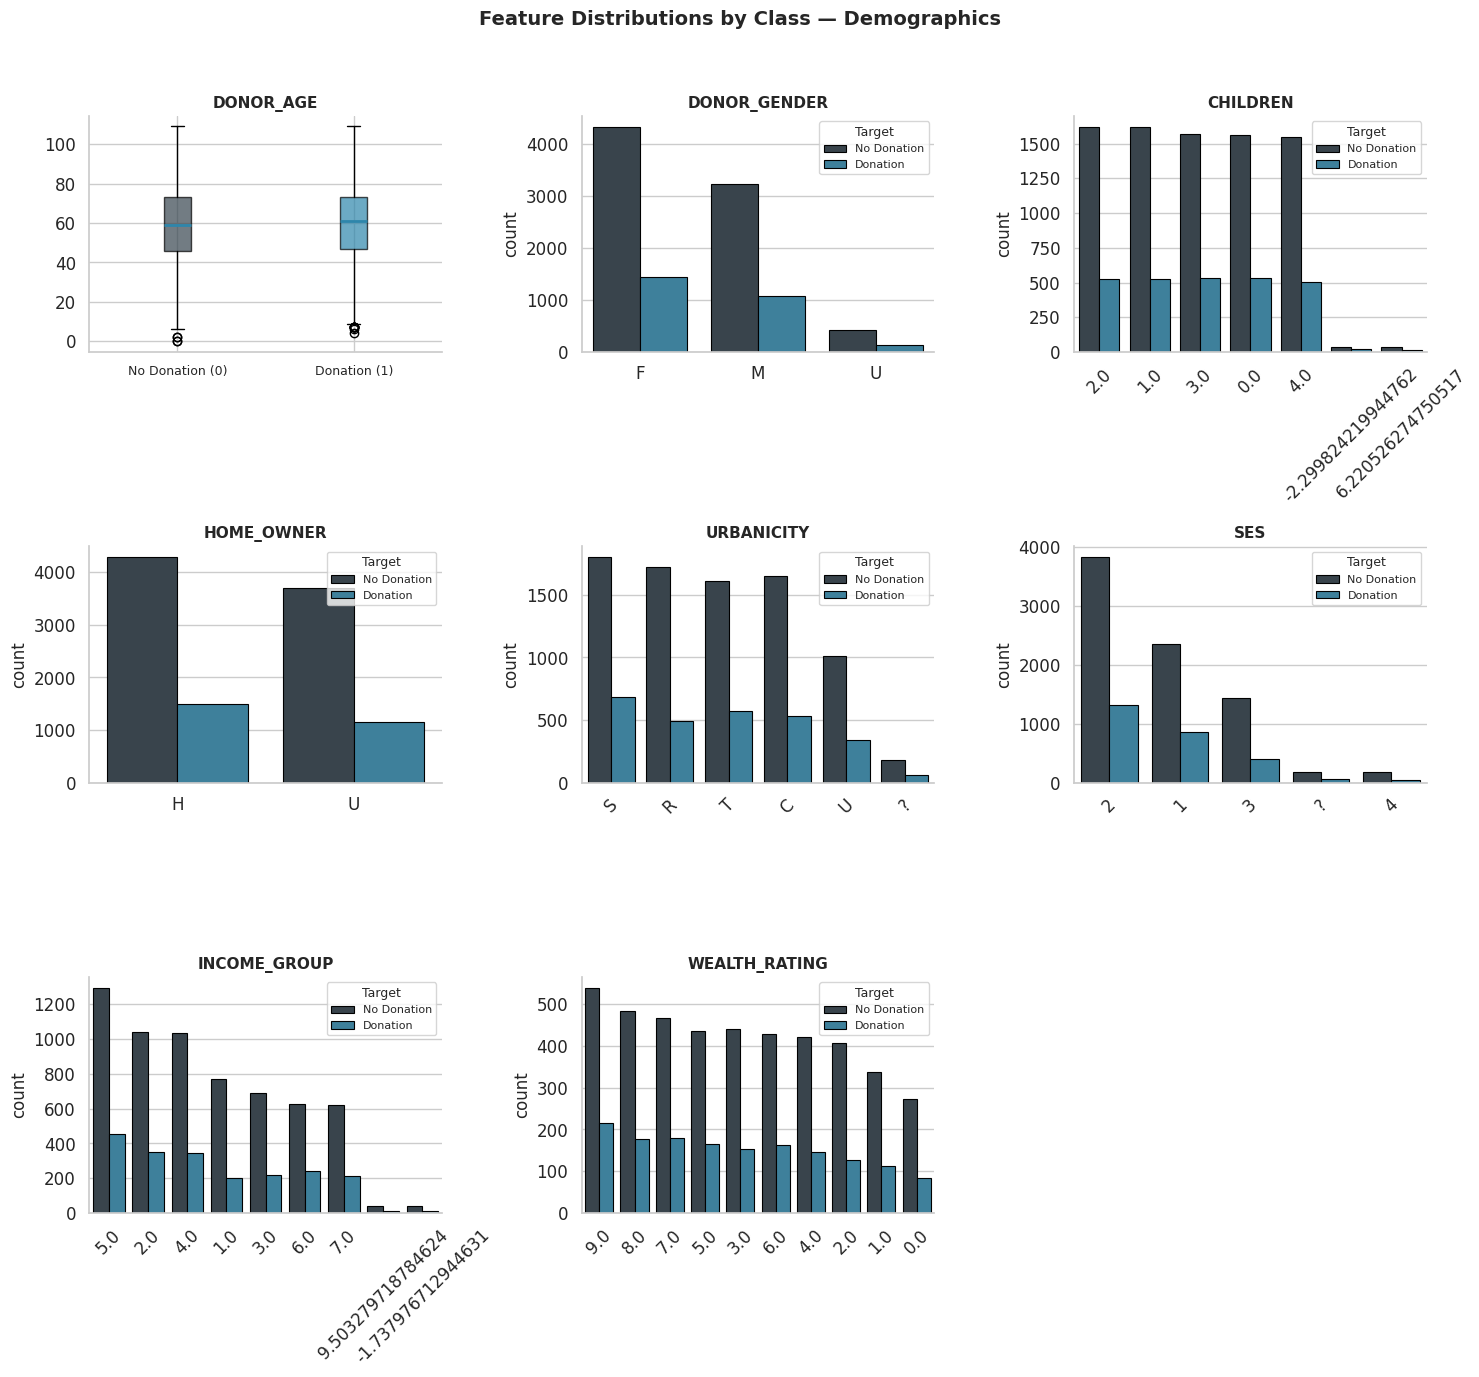

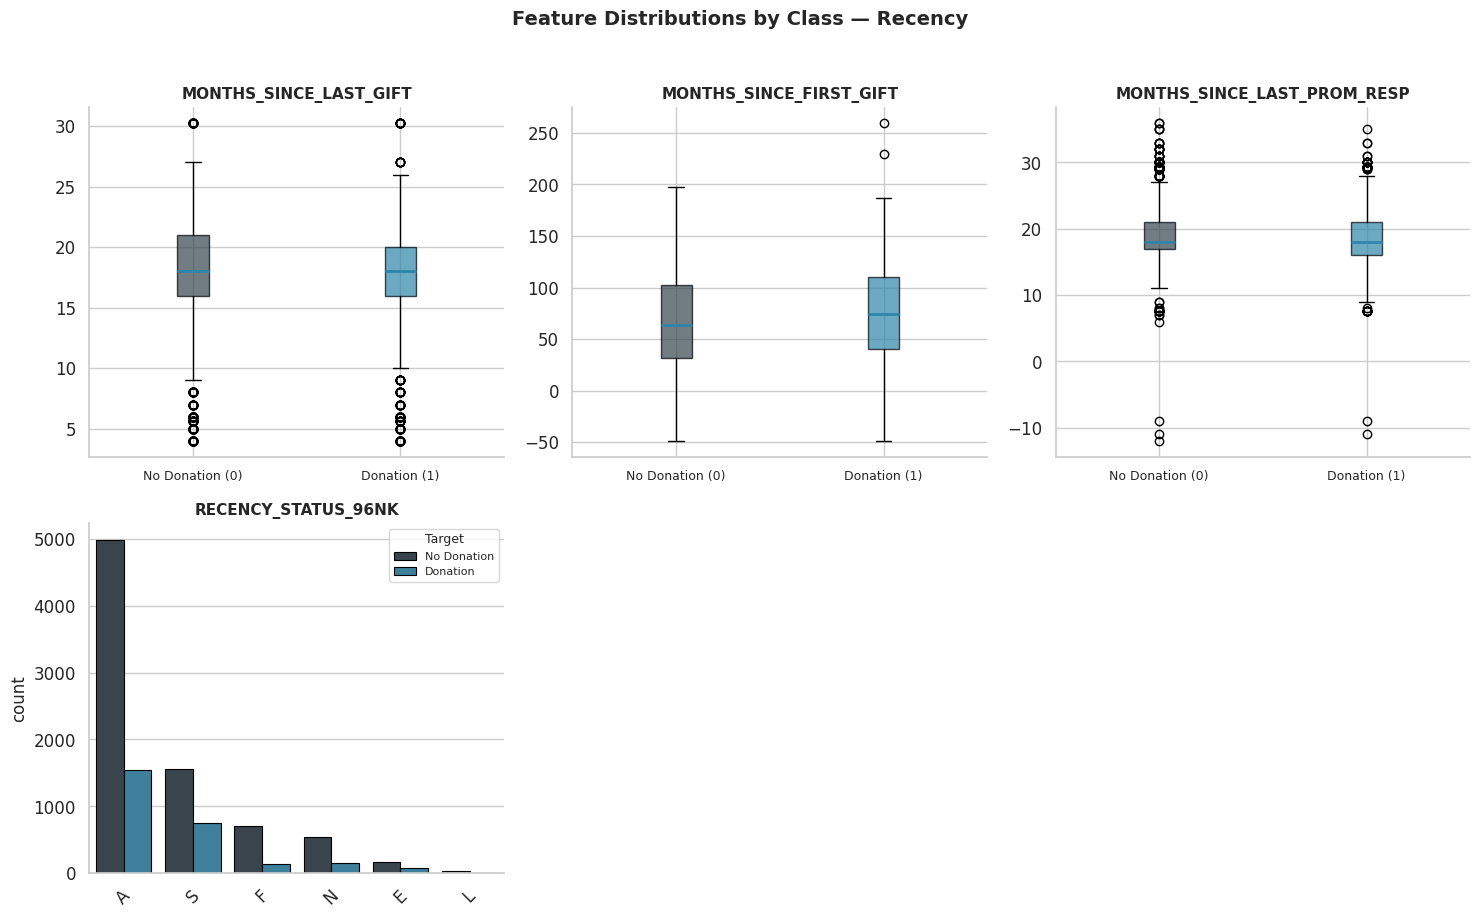

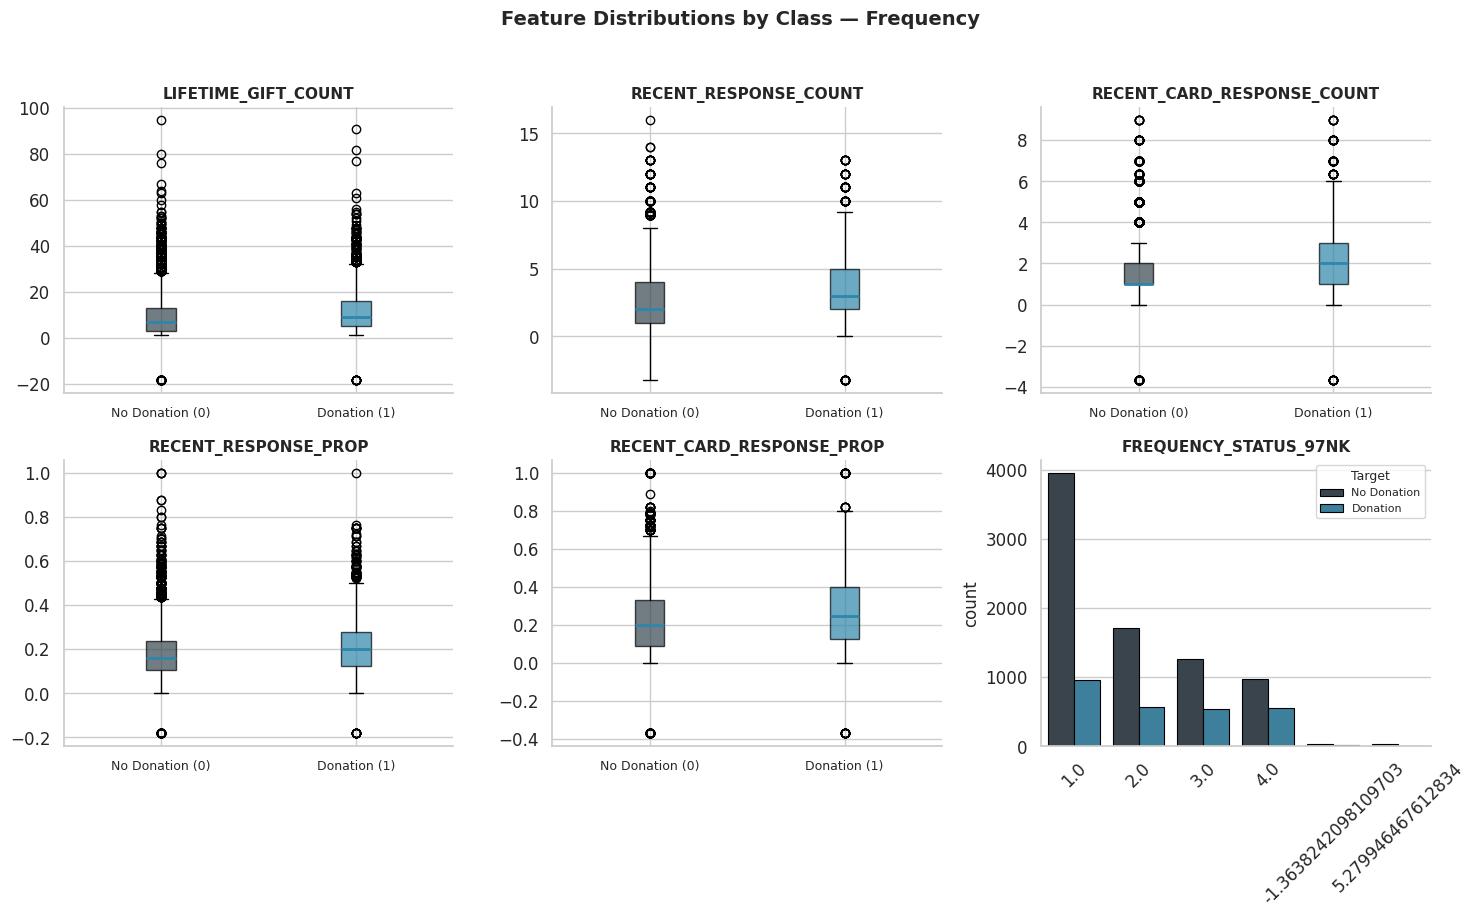

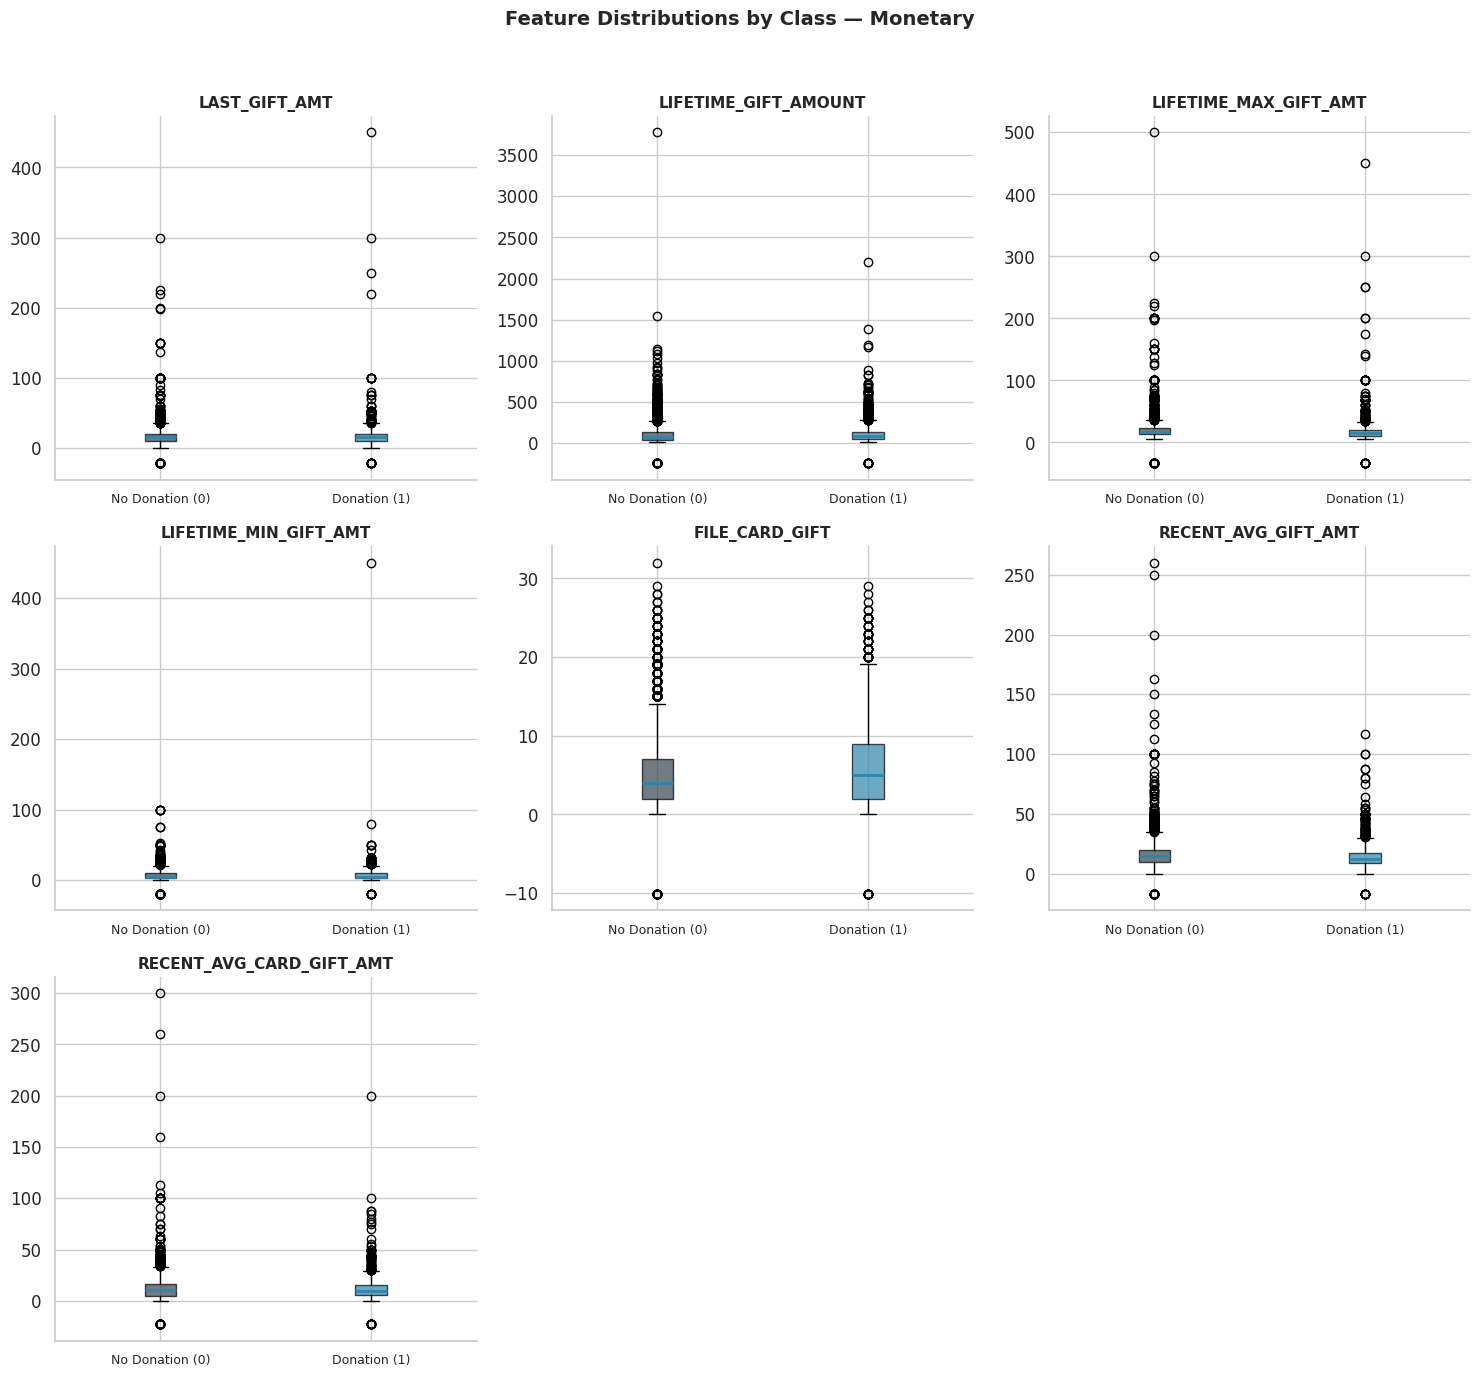

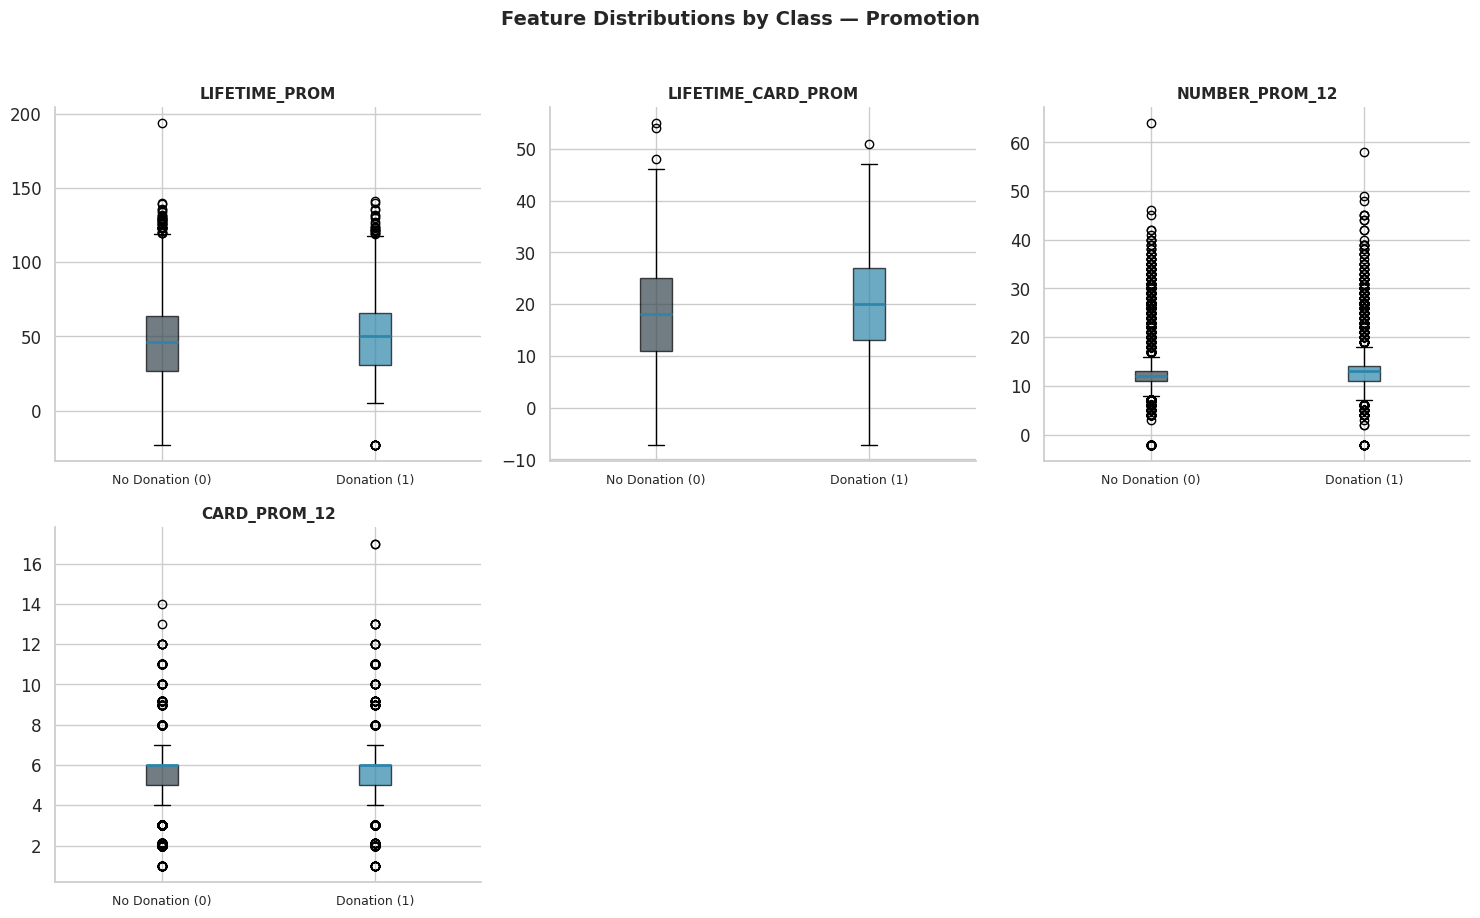

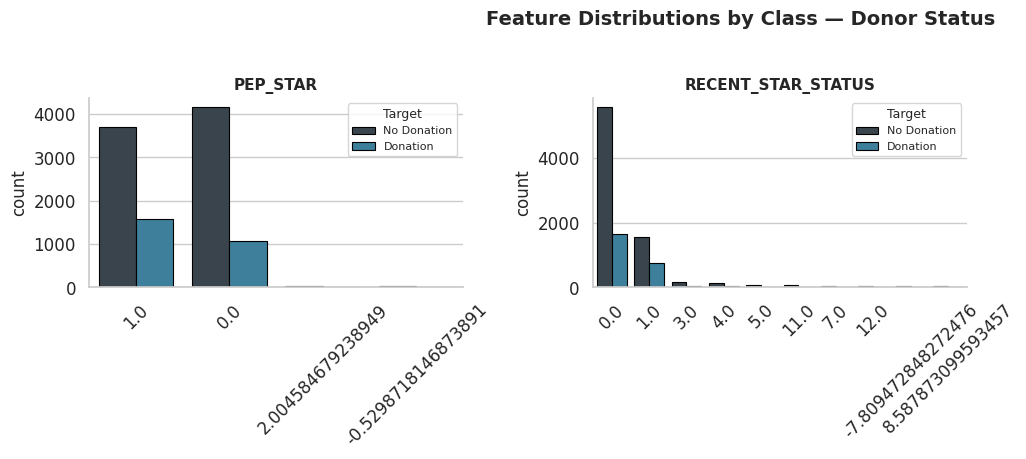

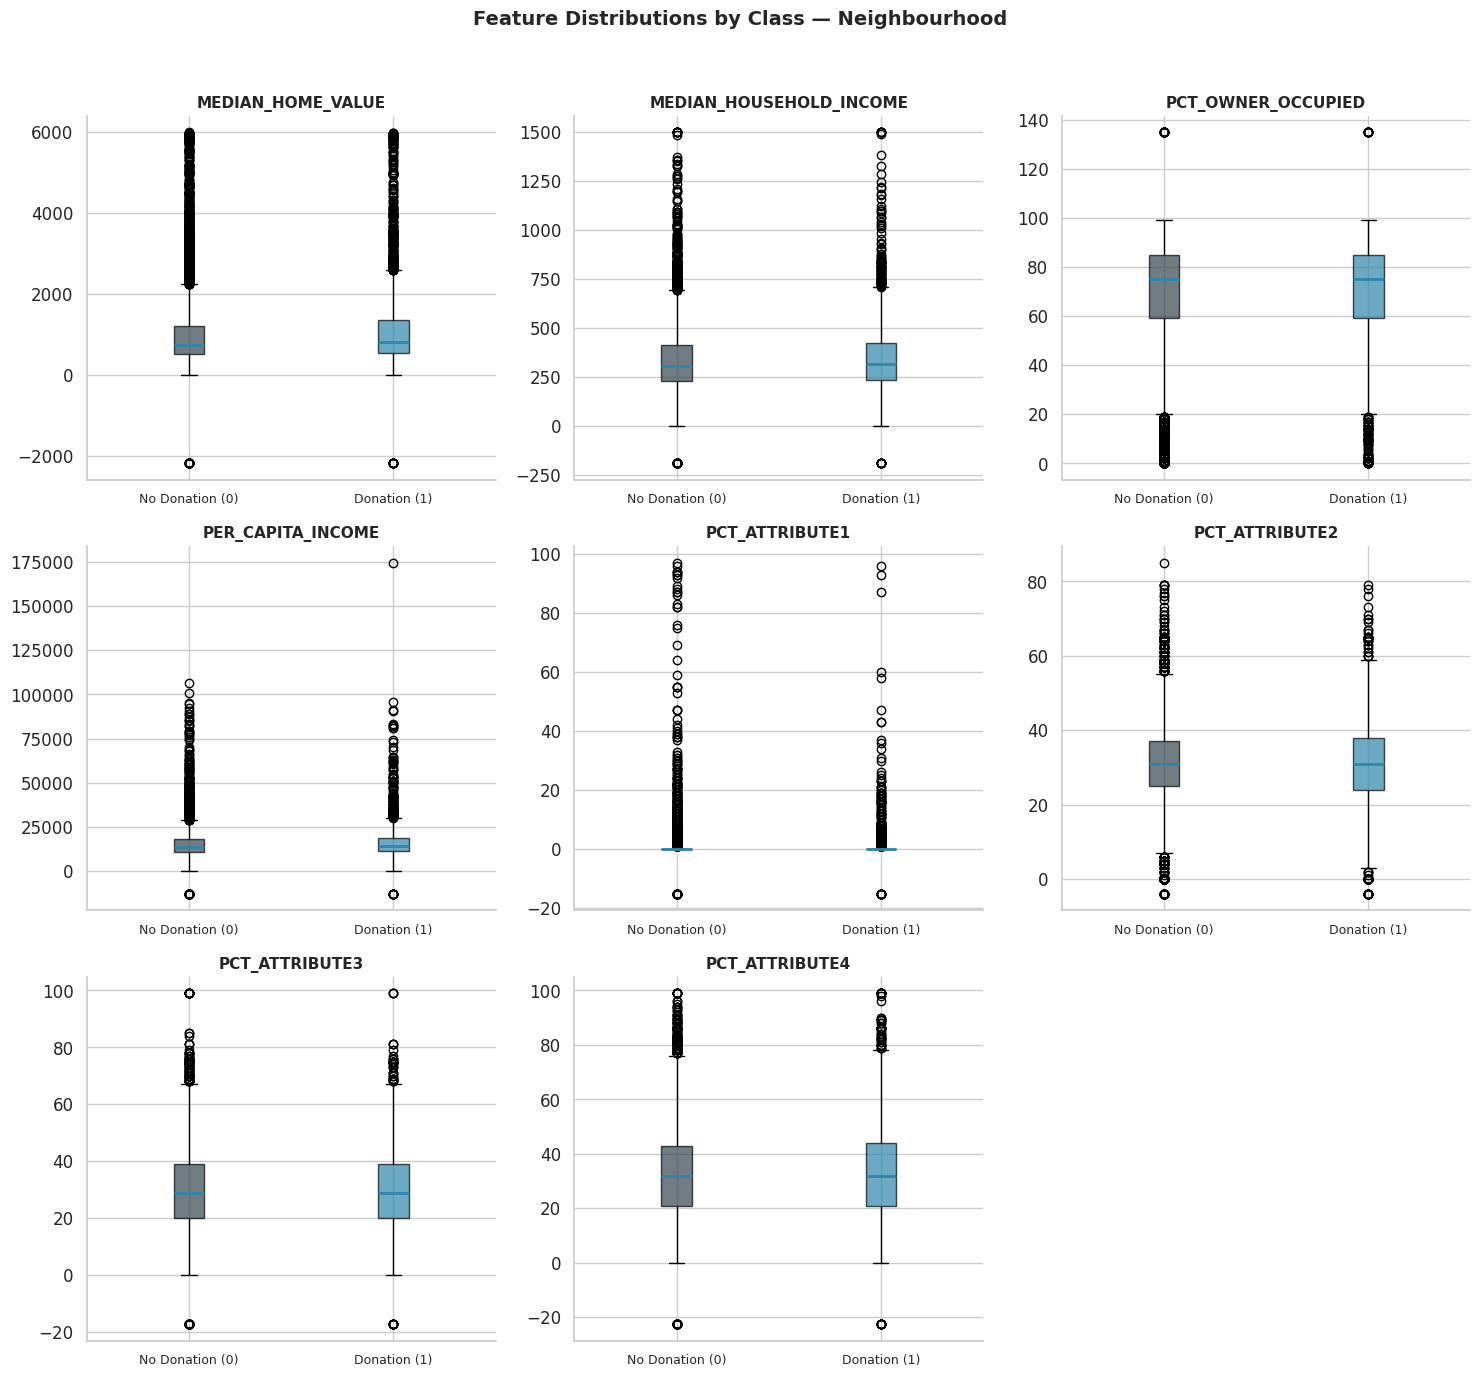

In [ ]:
# Distributions by feature group, split by TARGET_B

# Combine X_train and y_train temporarily for visualization (train only — no leakage)
plot_df = pd.concat([X_train, y_train], axis=1)
plot_df['TARGET_B'] = plot_df['TARGET_B'].astype(int)

# Class palette
palette = {0: COLOR_NEUTRAL, 1: COLOR_PRIMARY}

for group_name, features in feature_groups.items():
    current   = [f for f in features if f in X_train.columns]
    bar_feats = [f for f in current if f in to_plot_as_bars]
    box_feats = [f for f in current if f not in to_plot_as_bars]

    total_plots = len(bar_feats) + len(box_feats)
    if total_plots == 0:
        continue

    ncols = 3
    nrows = (total_plots + ncols - 1) // ncols

    # Dynamic subplot grid for this feature group
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4.5))
    axes = axes.flatten() if total_plots > 1 else [axes]
    fig.suptitle(f'Feature Distributions by Class — {group_name}',
                 fontsize=14, fontweight='bold', y=1.02)

    plot_idx = 0

    # Boxplots — continuous features, compared across classes
    for col in box_feats:
        data_0 = plot_df.loc[plot_df['TARGET_B'] == 0, col].dropna()
        data_1 = plot_df.loc[plot_df['TARGET_B'] == 1, col].dropna()
        bp = axes[plot_idx].boxplot(
            [data_0, data_1], patch_artist=True,
            medianprops=dict(color=COLOR_PRIMARY, linewidth=2),
            whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
        )
        bp['boxes'][0].set_facecolor(COLOR_NEUTRAL); bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor(COLOR_PRIMARY); bp['boxes'][1].set_alpha(0.7)
        axes[plot_idx].set_title(col, fontsize=11, fontweight='bold')
        axes[plot_idx].set_xticks([1, 2])
        axes[plot_idx].set_xticklabels(['No Donation (0)', 'Donation (1)'], fontsize=9)
        plot_idx += 1

    # Countplots — binary/categorical/ordinal, limited to the 10 most frequent values
    # (raw data still contains injected noise; capping keeps the x-axis readable)
    for col in bar_feats:
        top_vals = plot_df[col].value_counts().index[:10]
        sns.countplot(
            data=plot_df[plot_df[col].isin(top_vals)], x=col, hue='TARGET_B',
            ax=axes[plot_idx], palette=palette, order=top_vals,
            edgecolor='black', linewidth=0.8,
        )
        axes[plot_idx].set_title(col, fontsize=11, fontweight='bold')
        axes[plot_idx].tick_params(axis='x', rotation=45 if plot_df[col].nunique() > 3 else 0)
        axes[plot_idx].set_xlabel('')
        axes[plot_idx].legend(title='Target', labels=['No Donation', 'Donation'],
                              fontsize=8, title_fontsize=9, loc='upper right')
        plot_idx += 1

    # Hide any unused subplots in the grid
    for j in range(plot_idx, len(axes)):
        axes[j].set_visible(False)

    sns.despine()
    plt.tight_layout()
    plt.show()

### Outlier & Skewness Analysis

In [ ]:
# Outlier (IQR method) and skewness analysis — continuous features only
outlier_stats = []
current_num_cols = [c for c in num_cols if c in X_train.columns and c not in to_plot_as_bars]

for col in current_num_cols:
    series = X_train[col].dropna()
    if series.empty:
        continue

    # IQR bounds for outlier detection
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_outliers = ((series < lower) | (series > upper)).sum()
    outlier_stats.append({
        'Feature': col,
        'Outliers (n)': n_outliers,
        'Outliers (%)': round(n_outliers / len(series) * 100, 2),
        'Skewness': round(series.skew(), 2),
        'IQR Lower': round(lower, 2),
        'IQR Upper': round(upper, 2),
    })

outlier_df = (pd.DataFrame(outlier_stats)
              .sort_values('Outliers (%)', ascending=False)
              .reset_index(drop=True))

# Report outlier counts and skewness per feature
print("--- Outlier Analysis (IQR Method) ---")
print(outlier_df[['Feature', 'Outliers (n)', 'Outliers (%)', 'Skewness']].to_string(index=False))

# Flag highly skewed features (candidates for log transformation)
print("\n--- Highly Skewed Features (|skewness| > 1) -> Log Transform Candidates ---")
skewed = outlier_df[outlier_df['Skewness'].abs() > 1][['Feature', 'Skewness']]
if not skewed.empty:
    for _, row in skewed.iterrows():
        direction = "right" if row['Skewness'] > 0 else "left"
        print(f"  {row['Feature']:35s}: {row['Skewness']:+.2f} ({direction}-skewed)")
else:
    print("  None found.")

--- Outlier Analysis (IQR Method) ---
                    Feature  Outliers (n)  Outliers (%)  Skewness
             PCT_ATTRIBUTE1          2514         23.65     10.26
 RECENT_CARD_RESPONSE_COUNT          1405         13.20      0.99
             NUMBER_PROM_12          1393         13.11      2.51
          MEDIAN_HOME_VALUE          1057          9.93      2.14
               CARD_PROM_12          1022          9.61      0.54
             PCT_ATTRIBUTE2           732          6.88     -0.17
          PER_CAPITA_INCOME           697          6.55      3.07
      LIFETIME_MAX_GIFT_AMT           683          6.42      9.47
       LIFETIME_GIFT_AMOUNT           637          6.00      6.32
      LIFETIME_MIN_GIFT_AMT           590          5.56     14.70
     MONTHS_SINCE_LAST_GIFT           590          5.55     -0.57
         PCT_OWNER_OCCUPIED           554          5.21     -1.09
      RECENT_RESPONSE_COUNT           522          4.91      1.17
        LIFETIME_GIFT_COUNT           

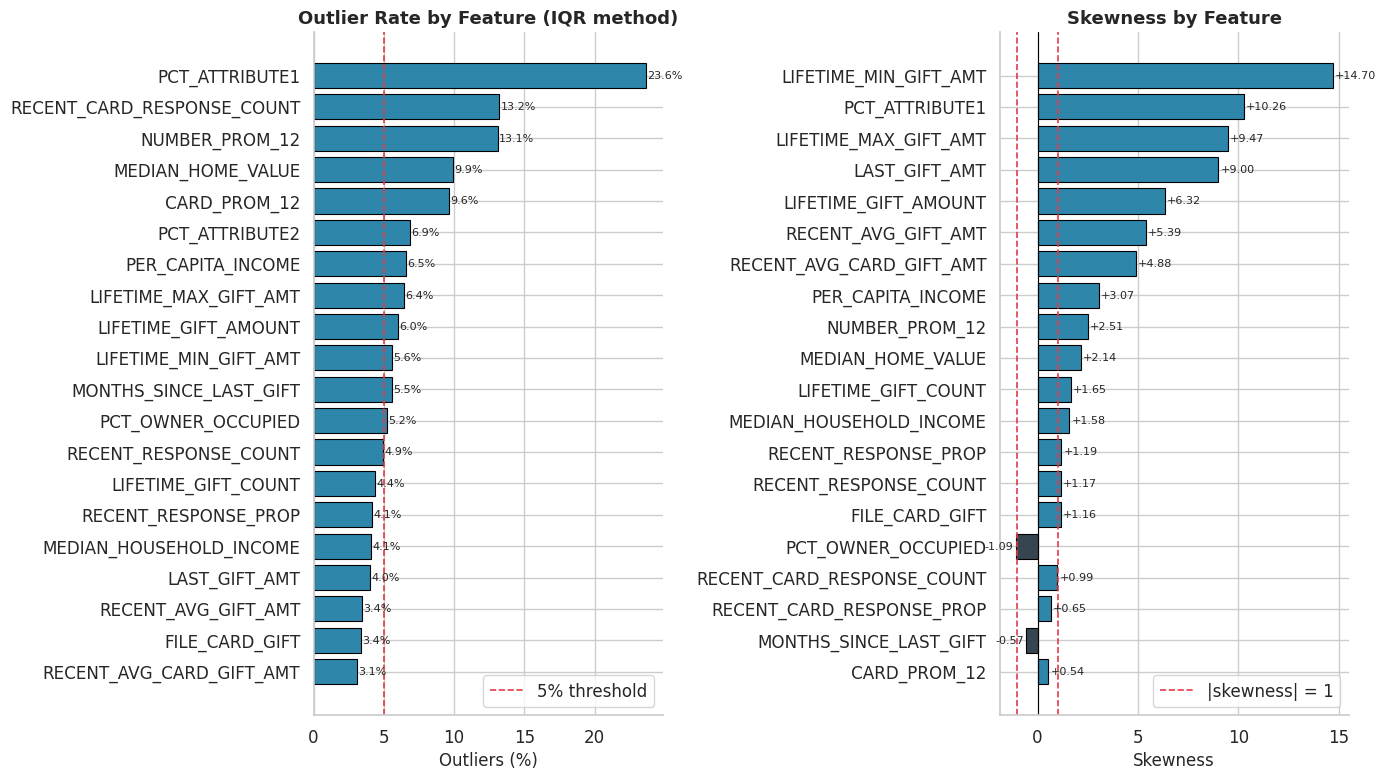

In [ ]:
# Side-by-side summary: outlier rate (left) and skewness (right) per feature
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left panel — top 20 features by outlier percentage
top_outliers = outlier_df[outlier_df['Outliers (%)'] > 0].head(20).iloc[::-1]
axes[0].barh(top_outliers['Feature'], top_outliers['Outliers (%)'],
             color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, linewidth=0.8)
axes[0].axvline(x=5, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label='5% threshold')
axes[0].set_title('Outlier Rate by Feature (IQR method)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Outliers (%)')
axes[0].legend()
for i, v in enumerate(top_outliers['Outliers (%)']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# Right panel — top 20 features by absolute skewness (colour = direction)
skew_df = outlier_df.reindex(outlier_df['Skewness'].abs().sort_values(ascending=False).index).head(20).iloc[::-1]
colors_skew = [COLOR_PRIMARY if v > 0 else COLOR_NEUTRAL for v in skew_df['Skewness']]
axes[1].barh(skew_df['Feature'], skew_df['Skewness'],
             color=colors_skew, edgecolor=COLOR_BLACK, linewidth=0.8)
axes[1].axvline(x=1, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label='|skewness| = 1')
axes[1].axvline(x=-1, color=COLOR_ACCENT, linestyle='--', linewidth=1.2)
axes[1].axvline(x=0, color=COLOR_BLACK, linewidth=0.8)
axes[1].set_title('Skewness by Feature', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Skewness')
axes[1].legend()
for i, v in enumerate(skew_df['Skewness']):
    axes[1].text(v + 0.1 if v >= 0 else v - 0.1, i, f'{v:+.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

### Correlation inter-features

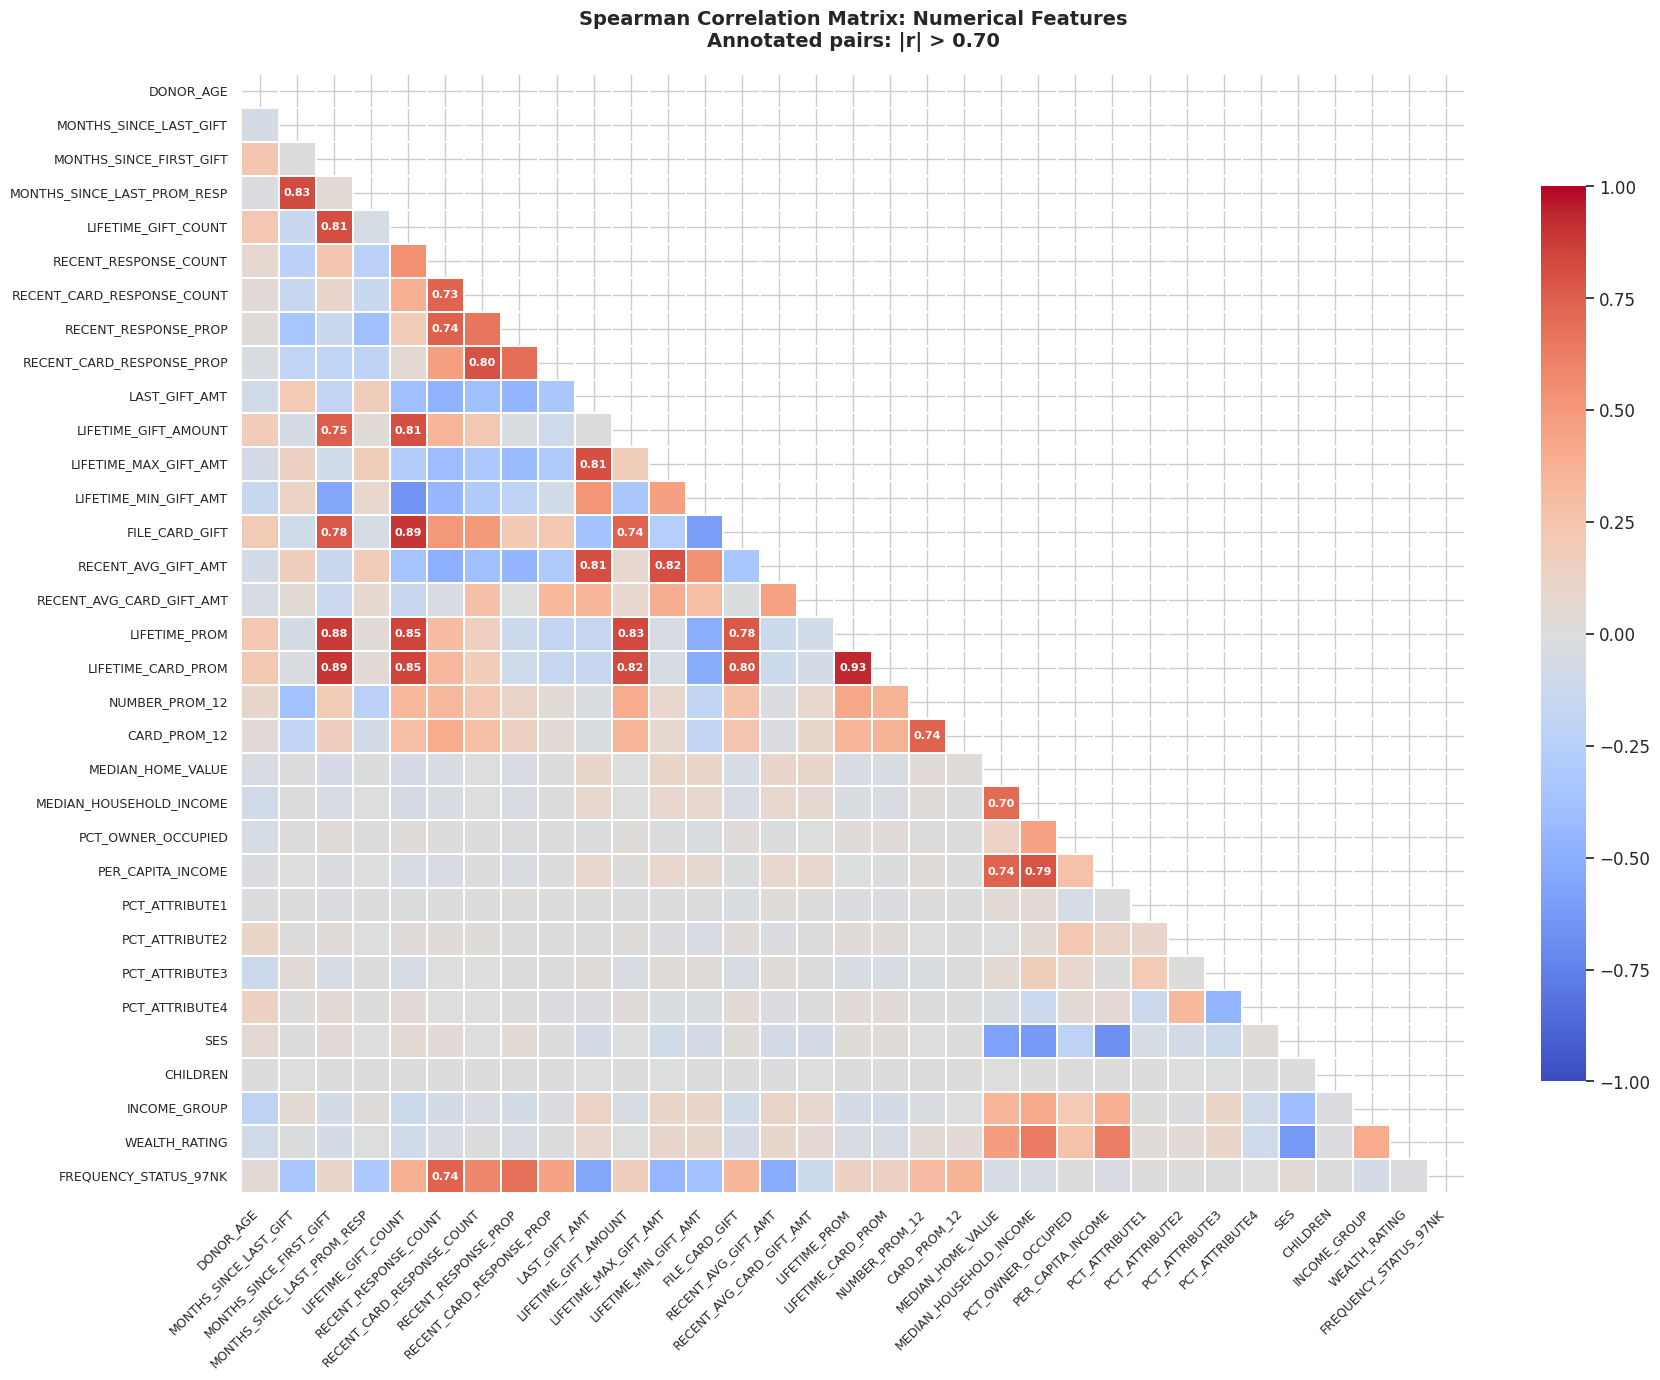

--- Critical redundancy (|r| > 0.85) — candidates for removal ---
  [!!] MONTHS_SINCE_FIRST_GIFT <-> LIFETIME_PROM: +0.88 (Positive)
  [!!] MONTHS_SINCE_FIRST_GIFT <-> LIFETIME_CARD_PROM: +0.89 (Positive)
  [!!] LIFETIME_GIFT_COUNT <-> FILE_CARD_GIFT: +0.89 (Positive)
  [!!] LIFETIME_PROM <-> LIFETIME_CARD_PROM: +0.93 (Positive)

--- Strong correlation (0.70 < |r| <= 0.85) ---
  [*]  MONTHS_SINCE_LAST_GIFT <-> MONTHS_SINCE_LAST_PROM_RESP: +0.83
  [*]  MONTHS_SINCE_FIRST_GIFT <-> LIFETIME_GIFT_COUNT: +0.81
  [*]  MONTHS_SINCE_FIRST_GIFT <-> LIFETIME_GIFT_AMOUNT: +0.75
  [*]  MONTHS_SINCE_FIRST_GIFT <-> FILE_CARD_GIFT: +0.78
  [*]  LIFETIME_GIFT_COUNT <-> LIFETIME_GIFT_AMOUNT: +0.81
  [*]  LIFETIME_GIFT_COUNT <-> LIFETIME_PROM: +0.85
  [*]  LIFETIME_GIFT_COUNT <-> LIFETIME_CARD_PROM: +0.85
  [*]  RECENT_RESPONSE_COUNT <-> RECENT_CARD_RESPONSE_COUNT: +0.73
  [*]  RECENT_RESPONSE_COUNT <-> RECENT_RESPONSE_PROP: +0.74
  [*]  RECENT_RESPONSE_COUNT <-> FREQUENCY_STATUS_97NK: +0.74
  [*]  RECE

In [ ]:
# Spearman correlation & redundancy (X_train only)
# Continuous + ordinal features (both rank-ordered); binary handled by Theil's U next.
# X_train is still raw here, so ordinals may be 'object' due to textual sentinels.
# We coerce to numeric for this computation only (sentinels -> NaN, ignored pairwise);
# the raw X_train is not modified.

spearman_cols = [c for c in (CONTINUOUS_FEATURES + ORDINAL_FEATURES) if c in X_train.columns]

# Coerce ordinals to numeric for the EDA computation only
X_train_for_spearman = X_train[spearman_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = X_train_for_spearman.corr(method='spearman')

# Mask upper triangle and annotate only strong pairs (|r| > 0.70)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annot_matrix = corr_matrix.applymap(lambda x: f'{x:.2f}' if abs(x) > 0.70 else '')

# Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax, cmap=CMAP_DIVERGING, center=0,
    vmin=-1, vmax=1, annot=annot_matrix, fmt='',
    annot_kws={'size': 8, 'weight': 'bold'},
    linewidths=0.1, linecolor='white', cbar_kws={'shrink': 0.8},
)
ax.set_title('Spearman Correlation Matrix: Numerical Features\nAnnotated pairs: |r| > 0.70',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
sns.despine(bottom=True, left=True)
plt.tight_layout()
plt.show()

# Collect all redundant pairs above 0.70 in a single pass
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.70:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

# Report critical (|r| > 0.85) and strong (0.70 < |r| <= 0.85) redundancy
print("--- Critical redundancy (|r| > 0.85) — candidates for removal ---")
critical = [p for p in pairs if abs(p[2]) > 0.85]
for c1, c2, val in critical:
    print(f"  [!!] {c1} <-> {c2}: {val:+.2f} ({'Positive' if val > 0 else 'Negative'})")
if not critical:
    print("  None found.")

print("\n--- Strong correlation (0.70 < |r| <= 0.85) ---")
strong = [p for p in pairs if 0.70 < abs(p[2]) <= 0.85]
for c1, c2, val in strong:
    print(f"  [*]  {c1} <-> {c2}: {val:+.2f}")
if not strong:
    print("  None found.")

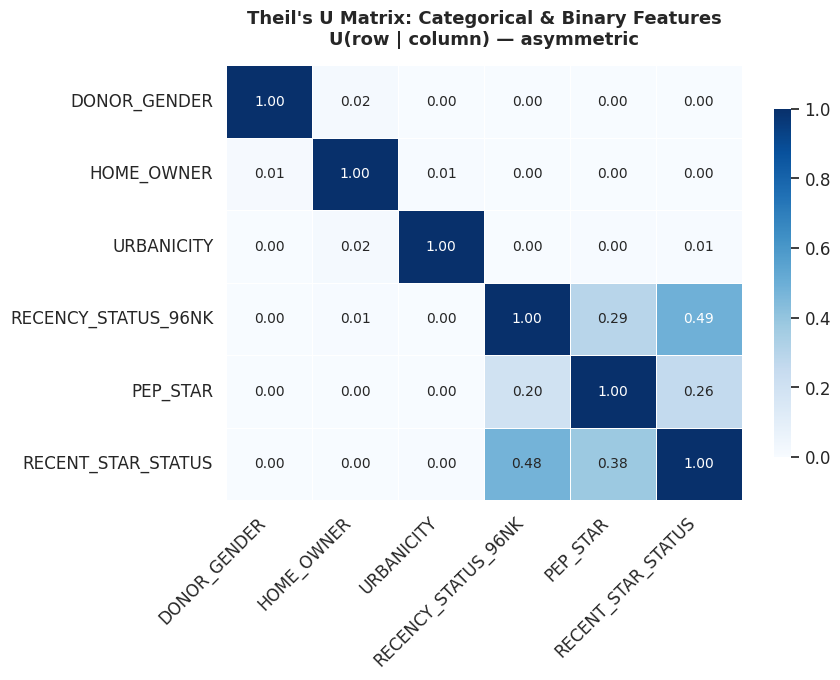

Strong inter-feature associations (U > 0.30):

  U(RECENCY_STATUS_96NK       | RECENT_STAR_STATUS       ) = 0.490
  U(RECENT_STAR_STATUS        | RECENCY_STATUS_96NK      ) = 0.480
  U(RECENT_STAR_STATUS        | PEP_STAR                 ) = 0.380


In [ ]:
# Theil's U — pairwise association for categorical & binary features (asymmetric: U(row | column))
def theils_u(x, y):
    # Pairwise-complete cases only
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if len(x) == 0:
        return 0

    # Entropy of y, and conditional entropy of y given x
    h_y = entropy(y.value_counts(normalize=True), base=2)
    if h_y == 0:
        return 0
    h_y_given_x = 0
    for val_x, p_x in x.value_counts(normalize=True).items():
        y_subset = y[x == val_x]
        h_y_given_x += p_x * entropy(y_subset.value_counts(normalize=True), base=2)

    # Uncertainty coefficient: fraction of y's entropy explained by x
    return (h_y - h_y_given_x) / h_y

# Central feature classification — categorical + binary
cols_for_theil = [c for c in (CATEGORICAL_FEATURES + BINARY_FEATURES) if c in X_train.columns]

# Build the asymmetric association matrix (diagonal = 1)
theil_matrix = pd.DataFrame(index=cols_for_theil, columns=cols_for_theil, dtype=float)
for col_i in cols_for_theil:
    for col_j in cols_for_theil:
        theil_matrix.loc[col_i, col_j] = 1.0 if col_i == col_j else theils_u(X_train[col_i], X_train[col_j])
theil_matrix = theil_matrix.round(3)

# Heatmap of the association matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    theil_matrix, ax=ax, cmap=CMAP_SEQUENTIAL,
    vmin=0, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8},
)
ax.set_title("Theil's U Matrix: Categorical & Binary Features\nU(row | column) — asymmetric",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Report strong asymmetric associations
print("Strong inter-feature associations (U > 0.30):\n")
for col_i in cols_for_theil:
    for col_j in cols_for_theil:
        if col_i != col_j and theil_matrix.loc[col_i, col_j] > 0.30:
            print(f"  U({col_i:25s} | {col_j:25s}) = {theil_matrix.loc[col_i, col_j]:.3f}")

### Feature Correlation with Target

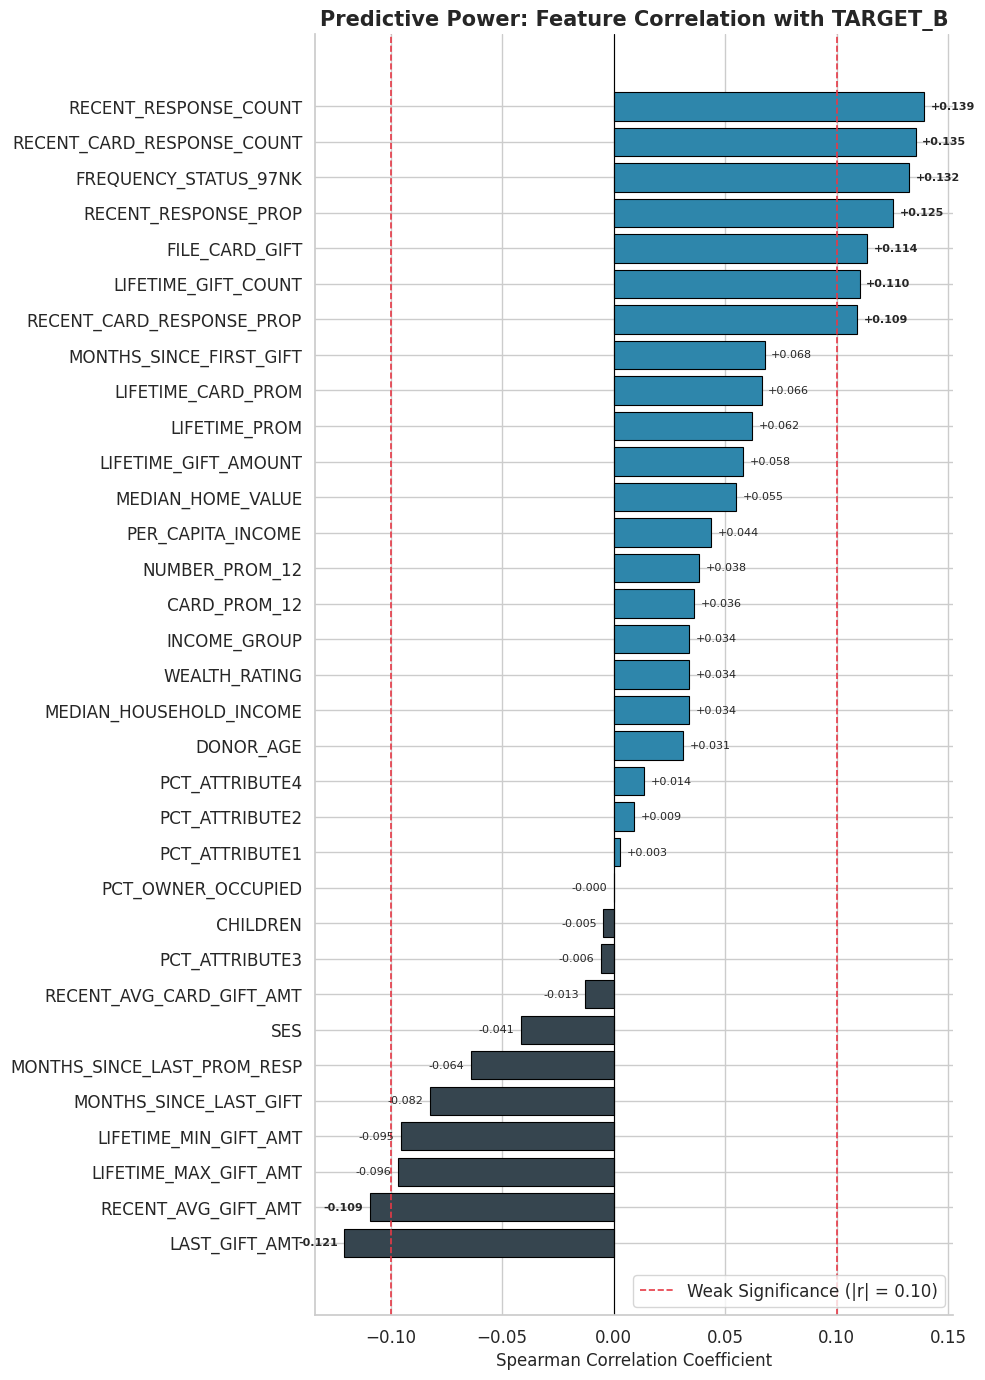

Feature correlation with TARGET_B (Spearman):
RECENT_RESPONSE_COUNT          0.139
RECENT_CARD_RESPONSE_COUNT     0.135
FREQUENCY_STATUS_97NK          0.132
RECENT_RESPONSE_PROP           0.125
LAST_GIFT_AMT                 -0.121
FILE_CARD_GIFT                 0.114
LIFETIME_GIFT_COUNT            0.110
RECENT_AVG_GIFT_AMT           -0.109
RECENT_CARD_RESPONSE_PROP      0.109
LIFETIME_MAX_GIFT_AMT         -0.096
LIFETIME_MIN_GIFT_AMT         -0.095
MONTHS_SINCE_LAST_GIFT        -0.082
MONTHS_SINCE_FIRST_GIFT        0.068
LIFETIME_CARD_PROM             0.066
MONTHS_SINCE_LAST_PROM_RESP   -0.064
LIFETIME_PROM                  0.062
LIFETIME_GIFT_AMOUNT           0.058
MEDIAN_HOME_VALUE              0.055
PER_CAPITA_INCOME              0.044
SES                           -0.041
NUMBER_PROM_12                 0.038
CARD_PROM_12                   0.036
INCOME_GROUP                   0.034
WEALTH_RATING                  0.034
MEDIAN_HOUSEHOLD_INCOME        0.034
DONOR_AGE                    

In [ ]:
# Spearman correlation of numerical features with TARGET_B
target_corr = (
    X_train_for_spearman
    .corrwith(y_train, method='spearman')
    .sort_values(ascending=True)
)

# Horizontal bar chart (colour = direction of correlation)
fig, ax = plt.subplots(figsize=(10, 14))
colors = [COLOR_PRIMARY if v > 0 else COLOR_NEUTRAL for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values,
               color=colors, edgecolor=COLOR_BLACK, linewidth=0.8)
ax.set_title('Predictive Power: Feature Correlation with TARGET_B', fontsize=15, fontweight='bold')
ax.set_xlabel('Spearman Correlation Coefficient')

# Reference lines: zero and weak-significance thresholds
ax.axvline(x=0, color=COLOR_BLACK, linewidth=0.8)
ax.axvline(x=0.10, color=COLOR_ACCENT, linestyle='--', linewidth=1.2, label='Weak Significance (|r| = 0.10)')
ax.axvline(x=-0.10, color=COLOR_ACCENT, linestyle='--', linewidth=1.2)

# Label each bar (bold if above the weak-significance threshold)
for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.003 if val >= 0 else val - 0.003,
            bar.get_y() + bar.get_height() / 2, f'{val:+.3f}',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=8, fontweight='bold' if abs(val) > 0.1 else 'normal')

ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

# Report correlations, sorted by magnitude
print("Feature correlation with TARGET_B (Spearman):")
print(target_corr.sort_values(key=abs, ascending=False).round(3).to_string())

# Highlight features above the weak-significance threshold
print("\nFeatures above |r| > 0.10:")
strong = target_corr[target_corr.abs() > 0.10]
for feat, val in strong.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:40s}: {val:+.3f}  ({'positive' if val > 0 else 'negative'})")

In [ ]:
# Theil's U — association of categorical/binary features with TARGET_B
cols_for_theil_target = [c for c in (CATEGORICAL_FEATURES + BINARY_FEATURES) if c in X_train.columns]
cat_assoc = {col: theils_u(X_train[col], y_train) for col in cols_for_theil_target}
cat_assoc_series = pd.Series(cat_assoc).sort_values(ascending=False).round(4)

# Report association strength per feature
print("Categorical / binary feature association with TARGET_B (Theil's U):")
print(cat_assoc_series.to_string())

# Highlight features with non-trivial association
print("\nPredictive candidates (U > 0.005):")
for feat, val in cat_assoc_series[cat_assoc_series > 0.005].items():
    print(f"  [+] {feat:40s}: {val:.4f}")

Categorical / binary feature association with TARGET_B (Theil's U):
PEP_STAR               0.0106
RECENCY_STATUS_96NK    0.0097
RECENT_STAR_STATUS     0.0094
URBANICITY             0.0016
HOME_OWNER             0.0004
DONOR_GENDER           0.0000

Predictive candidates (U > 0.005):
  [+] PEP_STAR                                : 0.0106
  [+] RECENCY_STATUS_96NK                     : 0.0097
  [+] RECENT_STAR_STATUS                      : 0.0094


### Out-of-Domain Values

Before invalid handling, we inspect every numerical feature against its codebook-defined domain. This reveals whether the data contains values that the codebook says are impossible (negative ages, fractional counts, percentages above 100, values outside ordinal scales).

This diagnostic is exploratory only — it informs but does not perform the cleaning, which is implemented later in the preprocessing section with full audit trail.

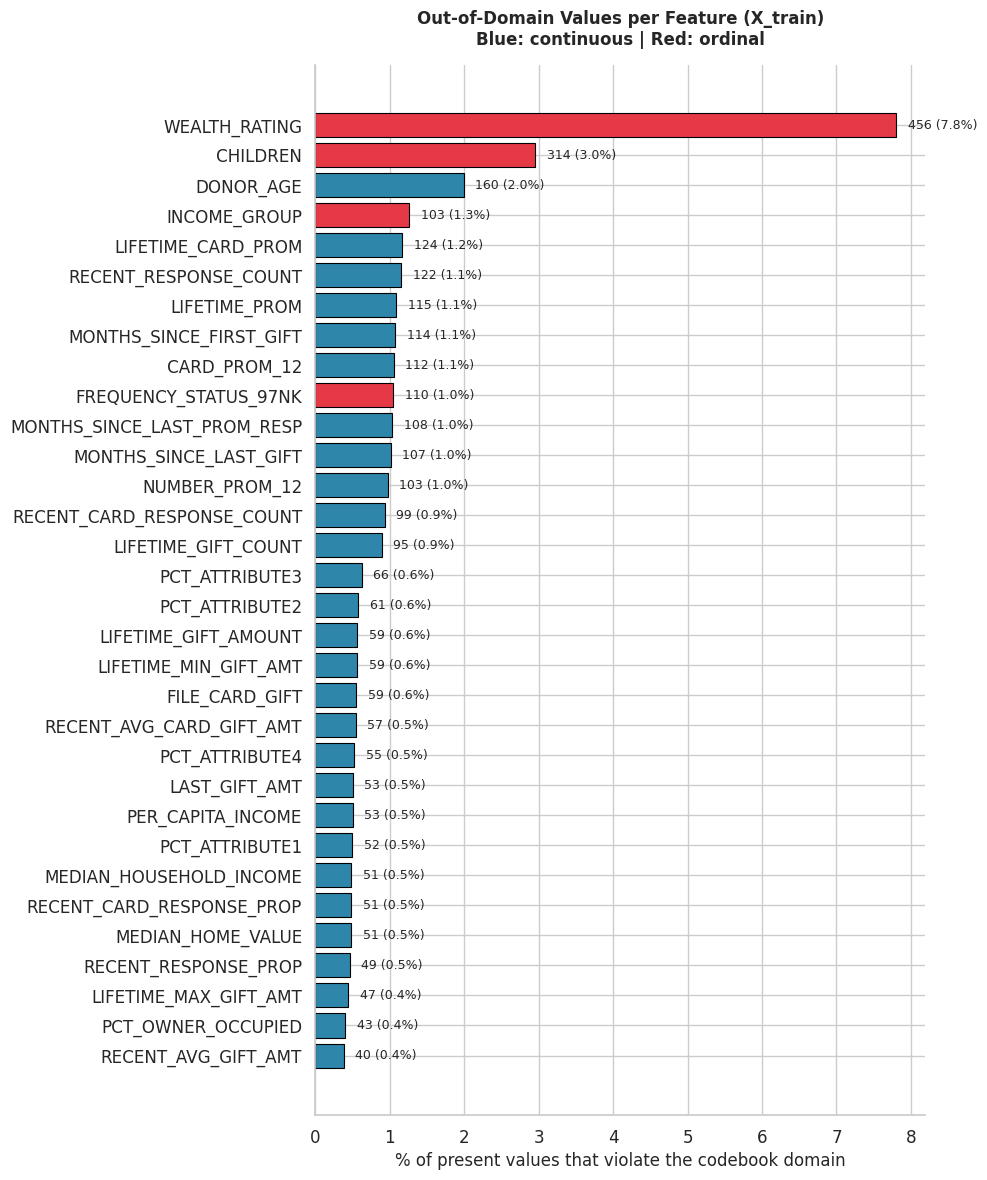

In [ ]:
# Out-of-domain diagnostic — count values violating codebook constraints per feature.
# Exploratory only: motivates the whitelist cleaning done later in preprocessing.
domain_violations = []

# Ordinal features — must fall within the codebook whitelist
ordinal_domains = {
    'SES'                  : [1, 2, 3, 4, 5],
    'INCOME_GROUP'         : [1, 2, 3, 4, 5, 6, 7],
    'WEALTH_RATING'        : list(range(1, 11)),
    'FREQUENCY_STATUS_97NK': [1, 2, 3, 4, 5],
}
for col, allowed in ordinal_domains.items():
    if col in X_train.columns:
        coerced   = pd.to_numeric(X_train[col], errors='coerce')
        n_viol    = (~coerced.isin(allowed) & coerced.notna()).sum()
        n_present = coerced.notna().sum()
        domain_violations.append({
            'Feature': col, 'Type': 'Ordinal',
            'Domain': f"{{{min(allowed)}, ..., {max(allowed)}}}",
            'Violations (n)': int(n_viol),
            'Violations (%)': round(n_viol / n_present * 100, 2) if n_present else 0,
        })

# CHILDREN — non-negative integers, no upper bound
if 'CHILDREN' in X_train.columns:
    coerced   = pd.to_numeric(X_train['CHILDREN'], errors='coerce')
    n_viol    = ((coerced < 0) | (coerced != coerced.round())).sum()
    n_present = coerced.notna().sum()
    domain_violations.append({
        'Feature': 'CHILDREN', 'Type': 'Ordinal', 'Domain': 'non-negative integer',
        'Violations (n)': int(n_viol),
        'Violations (%)': round(n_viol / n_present * 100, 2) if n_present else 0,
    })

# Continuous features — domain constraints (sign, integer, bounded ranges)
continuous_checks = {
    'DONOR_AGE'                  : lambda s: (s < 18) | (s > 120),
    'LAST_GIFT_AMT'              : lambda s: s < 0,
    'LIFETIME_GIFT_AMOUNT'       : lambda s: s < 0,
    'LIFETIME_MAX_GIFT_AMT'      : lambda s: s < 0,
    'LIFETIME_MIN_GIFT_AMT'      : lambda s: s < 0,
    'FILE_CARD_GIFT'             : lambda s: s < 0,
    'RECENT_AVG_GIFT_AMT'        : lambda s: s < 0,
    'RECENT_AVG_CARD_GIFT_AMT'   : lambda s: s < 0,
    'MONTHS_SINCE_LAST_GIFT'     : lambda s: (s < 0) | (s != s.round()),
    'MONTHS_SINCE_FIRST_GIFT'    : lambda s: (s < 0) | (s != s.round()),
    'MONTHS_SINCE_LAST_PROM_RESP': lambda s: (s < 0) | (s != s.round()),
    'LIFETIME_GIFT_COUNT'        : lambda s: (s < 0) | (s != s.round()),
    'RECENT_RESPONSE_COUNT'      : lambda s: (s < 0) | (s != s.round()),
    'RECENT_CARD_RESPONSE_COUNT' : lambda s: (s < 0) | (s != s.round()),
    'LIFETIME_PROM'              : lambda s: (s < 0) | (s != s.round()),
    'LIFETIME_CARD_PROM'         : lambda s: (s < 0) | (s != s.round()),
    'NUMBER_PROM_12'             : lambda s: (s < 0) | (s != s.round()),
    'CARD_PROM_12'               : lambda s: (s < 0) | (s != s.round()),
    'MEDIAN_HOME_VALUE'          : lambda s: s < 0,
    'MEDIAN_HOUSEHOLD_INCOME'    : lambda s: s < 0,
    'PER_CAPITA_INCOME'          : lambda s: s < 0,
    'PCT_OWNER_OCCUPIED'         : lambda s: (s < 0) | (s > 100),
    'PCT_ATTRIBUTE1'             : lambda s: (s < 0) | (s > 100),
    'PCT_ATTRIBUTE2'             : lambda s: (s < 0) | (s > 100),
    'PCT_ATTRIBUTE3'             : lambda s: (s < 0) | (s > 100),
    'PCT_ATTRIBUTE4'             : lambda s: (s < 0) | (s > 100),
    'RECENT_RESPONSE_PROP'       : lambda s: (s < 0) | (s > 1),
    'RECENT_CARD_RESPONSE_PROP'  : lambda s: (s < 0) | (s > 1),
}
domain_labels = {
    'DONOR_AGE': '[18, 120]',
    'MONTHS_SINCE_LAST_GIFT': 'non-negative integer', 'MONTHS_SINCE_FIRST_GIFT': 'non-negative integer',
    'MONTHS_SINCE_LAST_PROM_RESP': 'non-negative integer', 'LIFETIME_GIFT_COUNT': 'non-negative integer',
    'RECENT_RESPONSE_COUNT': 'non-negative integer', 'RECENT_CARD_RESPONSE_COUNT': 'non-negative integer',
    'LIFETIME_PROM': 'non-negative integer', 'LIFETIME_CARD_PROM': 'non-negative integer',
    'NUMBER_PROM_12': 'non-negative integer', 'CARD_PROM_12': 'non-negative integer',
    'PCT_OWNER_OCCUPIED': '[0, 100]', 'PCT_ATTRIBUTE1': '[0, 100]', 'PCT_ATTRIBUTE2': '[0, 100]',
    'PCT_ATTRIBUTE3': '[0, 100]', 'PCT_ATTRIBUTE4': '[0, 100]',
    'RECENT_RESPONSE_PROP': '[0, 1]', 'RECENT_CARD_RESPONSE_PROP': '[0, 1]',
}
for col, check_fn in continuous_checks.items():
    if col in X_train.columns:
        s         = pd.to_numeric(X_train[col], errors='coerce')
        n_viol    = (check_fn(s) & s.notna()).sum()
        n_present = s.notna().sum()
        domain_violations.append({
            'Feature': col, 'Type': 'Continuous',
            'Domain': domain_labels.get(col, 'non-negative'),
            'Violations (n)': int(n_viol),
            'Violations (%)': round(n_viol / n_present * 100, 2) if n_present else 0,
        })

violations_df = (pd.DataFrame(domain_violations)
                 .sort_values('Violations (%)', ascending=False)
                 .reset_index(drop=True))

# Plot features with at least one violation (colour = feature type)
fig, ax = plt.subplots(figsize=(10, 12))
plot_df = violations_df[violations_df['Violations (n)'] > 0].iloc[::-1]
bar_colors = [COLOR_PRIMARY if t == 'Continuous' else COLOR_ACCENT for t in plot_df['Type']]
ax.barh(plot_df['Feature'], plot_df['Violations (%)'],
        color=bar_colors, edgecolor=COLOR_BLACK, linewidth=0.8)
ax.set_title('Out-of-Domain Values per Feature (X_train)\nBlue: continuous | Red: ordinal',
             pad=15, fontsize=12, fontweight='bold')
ax.set_xlabel('% of present values that violate the codebook domain')

# Annotate each bar with count and percentage
for i, (n, pct) in enumerate(zip(plot_df['Violations (n)'], plot_df['Violations (%)'])):
    ax.text(pct + 0.05, i, f'  {n} ({pct:.1f}%)', va='center', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

#### Final EDA Takeaways

1. **Severe class imbalance (75/25).** Mandates F1 as primary metric and `class_weight='balanced'` in eligible models.
2. **Pervasive missingness (~2%).** Three exceptions: `WEALTH_RATING` (46%), `DONOR_AGE` (26%), `INCOME_GROUP` (24%). Imputation mandatory.
3. **Stochastic noise injection.** ~50–60 negative values across non-negative continuous features and ~100 fractional values in integer-by-construction features (`LIFETIME_GIFT_COUNT`, `MONTHS_SINCE_*`). Same pattern in ordinals. The consistency suggests **deliberate noise**, not entry errors — motivating a **whitelist approach** (only codebook-valid values retained).
4. **Skewed monetary features.** 16 continuous features have `|skewness| > 1` — log1p candidates (refined later: bounded percentages excluded).
5. **Feature redundancy.** Spearman `|r| > 0.85` among lifetime/promotion clusters (e.g., `LIFETIME_CARD_PROM` ↔ `LIFETIME_PROM`).
6. **Donor-status redundancy.** Theil's U confirms strong internal association between `RECENCY_STATUS_96NK`, `RECENT_STAR_STATUS`, `PEP_STAR`.
7. **Weak target signal.** No numerical feature exceeds `|r| = 0.14` with target. Top signals: Frequency (`RECENT_RESPONSE_COUNT`) and Monetary (`LAST_GIFT_AMT`).
8. **Negative momentum.** `LAST_GIFT_AMT` and `RECENT_AVG_GIFT_AMT` correlate **negatively** with target — donor fatigue signal.
9. **Neighbourhood features near-irrelevant.** `PCT_ATTRIBUTE1-4` have `|r| ≤ 0.06` — candidates for removal.

## B. Data Preprocessing

Every transformation is fitted on `X_train_clean` and applied to `X_val_clean` via `fit` / `transform` — no sklearn `Pipeline`, so intermediate state is inspectable at each step.

**Sequence:**
1. **Invalid handling** — whitelist of codebook-valid values; everything else → NaN.
2. **Imputation** — `SimpleImputer` with `median` (ordinal/continuous) or `most_frequent` (binary/categorical).
3. **Feature engineering** — four RFM-derived features (response rate, lifespan, gift trend, gift range).
4. **Log transformation** — `np.log1p` on non-negative, unbounded, right-skewed features.
5. **Robust scaling** — `RobustScaler` (median/IQR) on continuous features.
6. **Encoding** — `OrdinalEncoder` (preserves codebook scale) + `OneHotEncoder` (nominal categoricals).

### Outlier strategy

We **do not remove outliers**. The combination `log1p` + `RobustScaler` neutralises tail influence without discarding data. Four reasons:

- **Extreme values carry signal.** Donors with large `LIFETIME_GIFT_AMOUNT` are precisely the targets the model must identify.
- **Removing tails causes overfit to the centre** — the model would fail on val/test which we cannot clean the same way.
- **The Kaggle test set will contain outliers** we cannot preprocess separately.
- **Injected noise was already converted to NaN** by the whitelist; remaining extremes are legitimate observations.

This is consistent with Hawkins (1980), who distinguishes outliers as measurement errors (remove) from outliers as genuine extreme observations (retain + robust techniques).

### Invalid Handling — Whitelist Approach

We treat the codebook as authoritative: only values explicitly documented are retained; anything else (typos, sentinel symbols, fractional integers, negative counts, out-of-range codes) becomes `NaN` for the imputer.

**Why whitelist beats blacklist:** we can inspect `X_train` empirically but cannot anticipate `X_val` or test values. A whitelist catches both range violations (negative counts) and type violations (fractional values inside the valid range), which a sign- or range-only blacklist would miss. This matters here because the EDA out-of-domain diagnostic revealed systematic noise consistent with stochastic injection.

**Note on feature types:** binary / categorical / ordinal / continuous classification was set **a priori from the codebook**, not from EDA.

**Four sequential strategies:**
1. **Continuous** — codebook constraints (non-negativity, ranges, percentages, proportions, integer-by-construction).
2. **Bounded ordinals** (`SES`, `INCOME_GROUP`, `WEALTH_RATING`, `FREQUENCY_STATUS_97NK`) — strict whitelist of integer codes.
3. **Unbounded ordinal** (`CHILDREN`) — non-negative integers.
4. **Binary + categorical** — whitelist of codebook labels.

In [ ]:
# Working copies of the partitions (all cleaning applied to these)
X_train_clean = X_train.copy()
X_val_clean   = X_val.copy()

print("Deep copies created for X_train_clean and X_val_clean.")

Deep copies created for X_train_clean and X_val_clean.


In [ ]:
# Generic invalid-value cleaner: applies codebook range/sign/type rules.
# Out-of-spec values become NaN; coerces to numeric so textual sentinels are handled.
def clean_invalid_features(df, rules):
    df = df.copy()

    # Non-negative features: drop negatives
    for col in rules.get('non_negative', []):
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df.loc[coerced < 0, col] = np.nan

    # Bounded ranges: drop values outside [lo, hi]
    for col, (lo, hi) in rules.get('ranges', {}).items():
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            if lo is not None:
                df.loc[coerced < lo, col] = np.nan
            if hi is not None:
                df.loc[coerced > hi, col] = np.nan

    # Percentages: must be in [0, 100]
    for col in rules.get('percentages', []):
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df.loc[(coerced < 0) | (coerced > 100), col] = np.nan

    # Proportions: must be in [0, 1]
    for col in rules.get('proportions', []):
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df.loc[(coerced < 0) | (coerced > 1), col] = np.nan

    # Binary: must be 0 or 1
    for col in rules.get('binary', []):
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df.loc[~coerced.isin([0, 1]) & coerced.notna(), col] = np.nan

    # Integer counts: non-negative whole numbers only
    for col in rules.get('integer_counts', []):
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df.loc[((coerced < 0) | (coerced != coerced.round())) & coerced.notna(), col] = np.nan

    return df

In [ ]:
# Transparency report: list values converted to NaN by the invalid handler, per feature
def deep_transparency_report(original_df, cleaned_df, rules, category_name="Features"):
    """Report which values were set to NaN by the invalid handler, per feature."""
    print(f"\n--- TRANSPARENCY REPORT: {category_name} ---")
    found_issues = False

    # Collect all columns referenced in the rules (dict keys or list entries)
    all_cols = set()
    for val in rules.values():
        all_cols.update(val.keys() if isinstance(val, dict) else val)

    # For each column, count and show values that were removed (present -> NaN)
    for col in all_cols:
        if col in cleaned_df.columns:
            removed_mask = original_df[col].notna() & cleaned_df[col].isna()
            if removed_mask.sum() > 0:
                found_issues = True
                print(f"\n{col} | Set to NaN: {removed_mask.sum()} instances")
                print("Top values removed:")
                print(original_df.loc[removed_mask, col].value_counts().head(10).to_string())

    if not found_issues:
        print("No invalid values detected in this category.")

#### Numerical Continuous Invalid Treatment

Four kinds of codebook-derived constraints:

- **Non-negativity** — monetary amounts, `MONTHS_SINCE_*`, counts, neighbourhood income/value.
- **Range** — `DONOR_AGE ∈ [18, 120]`.
- **Percentage / proportion** — `PCT_*` in [0, 100], `*_PROP` in [0, 1].
- **Integer-by-construction** — `LIFETIME_GIFT_COUNT`, `MONTHS_SINCE_*`, `*_PROM*` — fractional values indicate noise.

**Excluded** from the integer constraint (legitimately continuous): `RECENT_*_PROP`, `*_AVG_GIFT_AMT`, `FILE_CARD_GIFT`, all monetary amounts.

In [ ]:
# Codebook constraints for continuous features
numeric_continuous_rules = {
    'non_negative': [
        'LAST_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_MAX_GIFT_AMT',
        'LIFETIME_MIN_GIFT_AMT', 'FILE_CARD_GIFT', 'RECENT_AVG_GIFT_AMT',
        'RECENT_AVG_CARD_GIFT_AMT',
        'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
        'LIFETIME_GIFT_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT',
        'LIFETIME_PROM', 'LIFETIME_CARD_PROM', 'NUMBER_PROM_12', 'CARD_PROM_12',
        'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'PER_CAPITA_INCOME',
    ],
    'ranges': {'DONOR_AGE': (18, 120)},
    'percentages': ['PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED'],
    'proportions': ['RECENT_RESPONSE_PROP', 'RECENT_CARD_RESPONSE_PROP'],
    'integer_counts': [
        'LIFETIME_GIFT_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT',
        'LIFETIME_PROM', 'LIFETIME_CARD_PROM', 'NUMBER_PROM_12', 'CARD_PROM_12',
        'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
    ],
}

# Apply the rules to both partitions, then report what was set to NaN
X_train_clean = clean_invalid_features(X_train_clean, numeric_continuous_rules)
X_val_clean   = clean_invalid_features(X_val_clean,   numeric_continuous_rules)
deep_transparency_report(X_train, X_train_clean, numeric_continuous_rules, "Numeric Continuous Features")


--- TRANSPARENCY REPORT: Numeric Continuous Features ---

RECENT_AVG_GIFT_AMT | Set to NaN: 40 instances
Top values removed:
RECENT_AVG_GIFT_AMT
-16.817445    40

MONTHS_SINCE_LAST_PROM_RESP | Set to NaN: 108 instances
Top values removed:
MONTHS_SINCE_LAST_PROM_RESP
 29.282221    53
 7.547111     50
-11.000000     2
-9.000000      2
-12.000000     1

MEDIAN_HOUSEHOLD_INCOME | Set to NaN: 51 instances
Top values removed:
MEDIAN_HOUSEHOLD_INCOME
-190.662683    51

CARD_PROM_12 | Set to NaN: 112 instances
Top values removed:
CARD_PROM_12
2.127207    63
9.166708    49

RECENT_CARD_RESPONSE_COUNT | Set to NaN: 99 instances
Top values removed:
RECENT_CARD_RESPONSE_COUNT
-3.695219    55
 6.336365    44

RECENT_RESPONSE_PROP | Set to NaN: 49 instances
Top values removed:
RECENT_RESPONSE_PROP
-0.181529    49

RECENT_AVG_CARD_GIFT_AMT | Set to NaN: 57 instances
Top values removed:
RECENT_AVG_CARD_GIFT_AMT
-22.840188    57

PCT_ATTRIBUTE2 | Set to NaN: 61 instances
Top values removed:
PCT_ATTRIB

#### Ordinal Invalid Treatment

Ordinal features have codebook-defined integer codes. **Whitelist approach** converts to NaN any value outside the documented codes — decimals introduced by noise, negative numbers, out-of-range integers.

`CHILDREN` is treated separately: codebook specifies non-negative integer with no upper bound.

`pd.to_numeric(..., errors='coerce')` handles columns parsed as `object` (textual sentinels) or `float64` (noise injection) robustly.

In [ ]:
# Ordinal whitelist — codebook-defined valid integer codes
ordinal_valid_values = {
    'SES'                  : [1, 2, 3, 4, 5],
    'INCOME_GROUP'         : [1, 2, 3, 4, 5, 6, 7],
    'WEALTH_RATING'        : list(range(1, 11)),
    'FREQUENCY_STATUS_97NK': [1, 2, 3, 4, 5],
}

# Whitelist cleaner: any value outside the documented codes -> NaN
def clean_ordinal_whitelist(df, valid_values):
    df = df.copy()
    for col, allowed in valid_values.items():
        if col in df.columns:
            coerced = pd.to_numeric(df[col], errors='coerce')
            df[col] = coerced.where(coerced.isin(allowed), np.nan)
    return df

# CHILDREN has no upper bound — only non-negative integers are valid
def clean_children(df):
    df = df.copy()
    if 'CHILDREN' in df.columns:
        coerced = pd.to_numeric(df['CHILDREN'], errors='coerce')
        invalid = ((coerced < 0) | (coerced != coerced.round())) & coerced.notna()
        df['CHILDREN'] = coerced.where(~invalid, np.nan)
    return df

# Apply whitelist and CHILDREN rule to both partitions
X_train_clean = clean_ordinal_whitelist(X_train_clean, ordinal_valid_values)
X_val_clean   = clean_ordinal_whitelist(X_val_clean,   ordinal_valid_values)
X_train_clean = clean_children(X_train_clean)
X_val_clean   = clean_children(X_val_clean)

# Report values removed from bounded ordinals
def ordinal_whitelist_report(original_df, cleaned_df, valid_values):
    print("\n--- TRANSPARENCY REPORT: Bounded Ordinals (Whitelist) ---")
    found = False
    for col, allowed in valid_values.items():
        if col not in cleaned_df.columns:
            continue
        original_coerced = pd.to_numeric(original_df[col], errors='coerce')
        removed = original_coerced.notna() & cleaned_df[col].isna()
        if removed.sum() > 0:
            found = True
            print(f"\n{col} | Values outside whitelist {{{min(allowed)}, ..., {max(allowed)}}}: {removed.sum()} instances")
            print(original_df.loc[removed, col].value_counts().head(10).to_string())
    if not found:
        print("All ordinal values match the codebook whitelist.")

ordinal_whitelist_report(X_train, X_train_clean, ordinal_valid_values)

# Report values removed from CHILDREN
print("\n--- TRANSPARENCY REPORT: CHILDREN (non-negative integer) ---")
original_coerced = pd.to_numeric(X_train['CHILDREN'], errors='coerce')
removed_children = original_coerced.notna() & X_train_clean['CHILDREN'].isna()
if removed_children.sum() > 0:
    print(f"CHILDREN | Non-integer or negative values converted to NaN: {removed_children.sum()} instances")
    print(X_train.loc[removed_children, 'CHILDREN'].value_counts().head(10).to_string())
else:
    print("CHILDREN: all values are non-negative integers, nothing converted.")


--- TRANSPARENCY REPORT: Bounded Ordinals (Whitelist) ---

INCOME_GROUP | Values outside whitelist {1, ..., 7}: 103 instances
INCOME_GROUP
 9.503280    52
-1.737977    51

WEALTH_RATING | Values outside whitelist {1, ..., 10}: 456 instances
WEALTH_RATING
 0.000000     356
-3.752821      56
 13.451898     44

FREQUENCY_STATUS_97NK | Values outside whitelist {1, ..., 5}: 110 instances
FREQUENCY_STATUS_97NK
-1.363824    56
 5.279946    54

--- TRANSPARENCY REPORT: CHILDREN (non-negative integer) ---
CHILDREN | Non-integer or negative values converted to NaN: 102 instances
CHILDREN
-2.299824    53
 6.220526    49


#### Binary Invalid Treatment

Only `PEP_STAR` and `RECENT_STAR_STATUS` are true binaries by the codebook (∈ {0, 1}). Values outside {0, 1} → NaN.

`HOME_OWNER` (`H`/`U`) and `DONOR_GENDER` (`F`/`M`) are binary in spirit but treated as categorical (OneHot encoded later) for consistency with other text-coded features.

In [ ]:
# Binary invalid handling — only PEP_STAR and RECENT_STAR_STATUS are codebook binaries
binary_rules = {'binary': BINARY_FEATURES}

# Apply to both partitions, then report what was set to NaN
X_train_clean = clean_invalid_features(X_train_clean, binary_rules)
X_val_clean   = clean_invalid_features(X_val_clean,   binary_rules)
deep_transparency_report(X_train, X_train_clean, binary_rules, "Binary Features")


--- TRANSPARENCY REPORT: Binary Features ---

PEP_STAR | Set to NaN: 104 instances
Top values removed:
PEP_STAR
 2.004585    53
-0.529872    51

RECENT_STAR_STATUS | Set to NaN: 1080 instances
Top values removed:
RECENT_STAR_STATUS
 3.000000     195
 4.000000     171
 5.000000     106
 11.000000    101
 7.000000      74
 12.000000     58
-7.809473      53
 8.587873      49
 6.000000      46
 10.000000     44


#### Categorical Invalid Treatment

`URBANICITY`, `RECENCY_STATUS_96NK`, `HOME_OWNER` and `DONOR_GENDER` have codebook-defined label sets. Any value outside the documented labels → NaN.



In [ ]:
# Categorical whitelist — codebook-defined valid labels
categorical_valid_values = {
    'URBANICITY'         : ['U', 'C', 'T', 'R', 'S'],
    'RECENCY_STATUS_96NK': ['A', 'E', 'F', 'L', 'N', 'S'],
    'HOME_OWNER'         : ['H', 'U'],
    'DONOR_GENDER'       : ['F', 'M'],
}

# Whitelist cleaner: any label not in the codebook set -> NaN
def clean_categorical_whitelist(df, valid_values):
    df = df.copy()
    for col, allowed in valid_values.items():
        if col in df.columns:
            df.loc[~df[col].isin(allowed) & df[col].notna(), col] = np.nan
    return df

# Apply to both partitions
X_train_clean = clean_categorical_whitelist(X_train_clean, categorical_valid_values)
X_val_clean   = clean_categorical_whitelist(X_val_clean,   categorical_valid_values)

In [ ]:
# Report categorical values removed by the whitelist
def categorical_whitelist_report(original_df, cleaned_df, valid_values):
    print("\n--- TRANSPARENCY REPORT: Categorical Features (Whitelist) ---")
    found = False
    for col, allowed in valid_values.items():
        if col not in cleaned_df.columns:
            continue
        removed = original_df[col].notna() & cleaned_df[col].isna()
        if removed.sum() > 0:
            found = True
            print(f"\n{col} | Values outside whitelist {allowed}: {removed.sum()} instances")
            print("Top values converted to NaN:")
            print(original_df.loc[removed, col].value_counts().head(10).to_string())
    if not found:
        print("All categorical values match the codebook whitelist.")

categorical_whitelist_report(X_train, X_train_clean, categorical_valid_values)


--- TRANSPARENCY REPORT: Categorical Features (Whitelist) ---

URBANICITY | Values outside whitelist ['U', 'C', 'T', 'R', 'S']: 238 instances
Top values converted to NaN:
URBANICITY
?    238

DONOR_GENDER | Values outside whitelist ['F', 'M']: 571 instances
Top values converted to NaN:
DONOR_GENDER
U    571


#### Invalid Handling — Summary

We now have a single cleaned dataset where every feature respects its codebook-defined domain. The next section performs imputation on the NaNs created here (and any pre-existing missing values) using statistics learned exclusively from `X_train_clean`.

In [ ]:
# Summary: NaNs introduced by invalid handling, per feature (increment over pre-existing NaNs)
summary_rows = []
for ftype, features in [
    ('Continuous',  CONTINUOUS_FEATURES),
    ('Ordinal',     ORDINAL_FEATURES),
    ('Binary',      BINARY_FEATURES),
    ('Categorical', CATEGORICAL_FEATURES),
]:
    for col in features:
        if col not in X_train_clean.columns:
            continue
        # Original NaN count (coerce numeric types so textual sentinels count as NaN)
        original = X_train[col] if ftype == 'Categorical' else pd.to_numeric(X_train[col], errors='coerce')
        original_nans = original.isna().sum()
        cleaned_nans  = X_train_clean[col].isna().sum()
        new_nans      = cleaned_nans - original_nans
        if new_nans > 0:
            summary_rows.append({
                'Feature': col, 'Type': ftype,
                'NaN introduced (train)': int(new_nans),
                'Total NaN now (train)' : int(cleaned_nans),
            })

summary_df = (pd.DataFrame(summary_rows)
              .sort_values('NaN introduced (train)', ascending=False)
              .reset_index(drop=True))

# Report per-feature and overall NaN counts
print("Invalid handling — summary of NaNs introduced per feature:\n")
print(summary_df.to_string(index=False))
print(f"\nTotal NaN values introduced by invalid handling (train): {summary_df['NaN introduced (train)'].sum()}")
print(f"Total NaN values now present in X_train_clean:           {X_train_clean.isna().sum().sum()}")
print(f"Total NaN values now present in X_val_clean:             {X_val_clean.isna().sum().sum()}")

Invalid handling — summary of NaNs introduced per feature:

                    Feature        Type  NaN introduced (train)  Total NaN now (train)
         RECENT_STAR_STATUS      Binary                    1080                   1287
               DONOR_GENDER Categorical                     571                    784
              WEALTH_RATING     Ordinal                     456                   5458
                 URBANICITY Categorical                     238                    453
                  DONOR_AGE  Continuous                     160                   2981
         LIFETIME_CARD_PROM  Continuous                     124                    324
      RECENT_RESPONSE_COUNT  Continuous                     122                    341
              LIFETIME_PROM  Continuous                     115                    327
    MONTHS_SINCE_FIRST_GIFT  Continuous                     114                    327
               CARD_PROM_12  Continuous                     112       

### Missing Values Imputation

All imputation uses `SimpleImputer` with `fit` on `X_train_clean` and `.transform()` on both partitions — no validation statistic leaks into the imputation step.

| Feature type | Strategy | Rationale |
|--------------|----------|-----------|
| Binary | `most_frequent` | Single most frequent of {0, 1} |
| Ordinal | `median` | Robust under high missingness (`WEALTH_RATING` at 46%) |
| Categorical | `most_frequent` | No order to preserve |
| Continuous | `median` | log1p applied later in a single consistent step |

Each fitted imputer's `statistics_` attribute is logged in the audit trail (`imputation_log`).

In [ ]:
# Audit trail: each imputed value is logged with its strategy and learned (train) value
imputation_log = []
print("Imputation tracker initialized.")

Imputation tracker initialized.


In [ ]:
# Binary imputation — most_frequent (no ordering between 0 and 1)
if BINARY_FEATURES:
    bin_imputer = SimpleImputer(strategy='most_frequent')

    # Record NaN counts before imputing (for the audit log)
    bin_train_nans = X_train_clean[BINARY_FEATURES].isna().sum()
    bin_val_nans   = X_val_clean[BINARY_FEATURES].isna().sum()

    # Fit on train only, transform both partitions
    bin_imputer.fit(X_train_clean[BINARY_FEATURES])
    X_train_clean[BINARY_FEATURES] = bin_imputer.transform(X_train_clean[BINARY_FEATURES])
    X_val_clean[BINARY_FEATURES]   = bin_imputer.transform(X_val_clean[BINARY_FEATURES])

    # Log each feature that had values filled
    for col, learned_value in zip(BINARY_FEATURES, bin_imputer.statistics_):
        if bin_train_nans[col] > 0 or bin_val_nans[col] > 0:
            imputation_log.append({
                'Feature': col, 'Strategy': 'Mode (SimpleImputer)',
                'Learned Value (from Train)': learned_value,
                'Train NaNs Filled': int(bin_train_nans[col]),
                'Val NaNs Filled':   int(bin_val_nans[col]),
            })

print(f"Binary imputation complete (mode). Features imputed: {len(BINARY_FEATURES)}")

Binary imputation complete (mode). Features imputed: 2


In [ ]:
# Ordinal imputation — median (preserves central rank; robust under high missingness)
if ORDINAL_FEATURES:
    ord_imputer = SimpleImputer(strategy='median')

    # Record NaN counts before imputing
    ord_train_nans = X_train_clean[ORDINAL_FEATURES].isna().sum()
    ord_val_nans   = X_val_clean[ORDINAL_FEATURES].isna().sum()

    # Fit on train only, transform both partitions
    ord_imputer.fit(X_train_clean[ORDINAL_FEATURES])
    X_train_clean[ORDINAL_FEATURES] = ord_imputer.transform(X_train_clean[ORDINAL_FEATURES])
    X_val_clean[ORDINAL_FEATURES]   = ord_imputer.transform(X_val_clean[ORDINAL_FEATURES])

    # Log each feature that had values filled
    for col, learned_value in zip(ORDINAL_FEATURES, ord_imputer.statistics_):
        if ord_train_nans[col] > 0 or ord_val_nans[col] > 0:
            imputation_log.append({
                'Feature': col, 'Strategy': 'Median (SimpleImputer)',
                'Learned Value (from Train)': learned_value,
                'Train NaNs Filled': int(ord_train_nans[col]),
                'Val NaNs Filled':   int(ord_val_nans[col]),
            })

print(f"Ordinal imputation complete (median). Features imputed: {len(ORDINAL_FEATURES)}")

Ordinal imputation complete (median). Features imputed: 5


In [ ]:
# Continuous imputation — median (robust to skew/outliers)
# log1p is applied LATER, after feature engineering, in a single auditable step.
# Note: CONTINUOUS_FEATURES holds the 27 original features here; engineered ones
# are added later (and imputed separately by eng_imputer).
if CONTINUOUS_FEATURES:
    cont_imputer = SimpleImputer(strategy='median')

    # Record NaN counts before imputing
    cont_train_nans = X_train_clean[CONTINUOUS_FEATURES].isna().sum()
    cont_val_nans   = X_val_clean[CONTINUOUS_FEATURES].isna().sum()

    # Fit on train only, transform both partitions
    cont_imputer.fit(X_train_clean[CONTINUOUS_FEATURES])
    X_train_clean[CONTINUOUS_FEATURES] = cont_imputer.transform(X_train_clean[CONTINUOUS_FEATURES])
    X_val_clean[CONTINUOUS_FEATURES]   = cont_imputer.transform(X_val_clean[CONTINUOUS_FEATURES])

    # Log each feature that had values filled
    for col, learned_value in zip(CONTINUOUS_FEATURES, cont_imputer.statistics_):
        if cont_train_nans[col] > 0 or cont_val_nans[col] > 0:
            imputation_log.append({
                'Feature': col, 'Strategy': 'Median (SimpleImputer)',
                'Learned Value (from Train)': round(learned_value, 4),
                'Train NaNs Filled': int(cont_train_nans[col]),
                'Val NaNs Filled':   int(cont_val_nans[col]),
            })

print(f"Continuous imputation complete (median). Features imputed: {len(CONTINUOUS_FEATURES)}")

Continuous imputation complete (median). Features imputed: 28


In [ ]:
# Categorical imputation — most_frequent (no ordering to preserve)
if CATEGORICAL_FEATURES:
    cat_imputer = SimpleImputer(strategy='most_frequent')

    # Record NaN counts before imputing
    cat_train_nans = X_train_clean[CATEGORICAL_FEATURES].isna().sum()
    cat_val_nans   = X_val_clean[CATEGORICAL_FEATURES].isna().sum()

    # Fit on train only, transform both partitions
    cat_imputer.fit(X_train_clean[CATEGORICAL_FEATURES])
    X_train_clean[CATEGORICAL_FEATURES] = cat_imputer.transform(X_train_clean[CATEGORICAL_FEATURES])
    X_val_clean[CATEGORICAL_FEATURES]   = cat_imputer.transform(X_val_clean[CATEGORICAL_FEATURES])

    # Log each feature that had values filled
    for col, learned_value in zip(CATEGORICAL_FEATURES, cat_imputer.statistics_):
        if cat_train_nans[col] > 0 or cat_val_nans[col] > 0:
            imputation_log.append({
                'Feature': col, 'Strategy': 'Mode (SimpleImputer)',
                'Learned Value (from Train)': learned_value,
                'Train NaNs Filled': int(cat_train_nans[col]),
                'Val NaNs Filled':   int(cat_val_nans[col]),
            })

print(f"Categorical imputation complete (mode). Features imputed: {len(CATEGORICAL_FEATURES)}")

Categorical imputation complete (mode). Features imputed: 4


In [ ]:
# Imputation transparency report — what was filled, per feature
print("--- IMPUTATION TRANSPARENCY REPORT ---")
if imputation_log:
    report_df = (pd.DataFrame(imputation_log)
                 .sort_values('Train NaNs Filled', ascending=False)
                 .reset_index(drop=True))
    print(report_df.to_string())
    print("-" * 75)
    print(f"Total missing values filled in Train: {report_df['Train NaNs Filled'].sum()}")
    print(f"Total missing values filled in Val:   {report_df['Val NaNs Filled'].sum()}")
else:
    print("No missing values were found to impute.")

# Confirm no NaNs remain after imputation
print(f"\nRemaining NaNs in X_train_clean: {X_train_clean.isna().sum().sum()}")
print(f"Remaining NaNs in X_val_clean  : {X_val_clean.isna().sum().sum()}")

--- IMPUTATION TRANSPARENCY REPORT ---
                        Feature                Strategy Learned Value (from Train)  Train NaNs Filled  Val NaNs Filled
0                 WEALTH_RATING  Median (SimpleImputer)                        5.0               5458             1381
1                     DONOR_AGE  Median (SimpleImputer)                       60.0               2981              775
2                  INCOME_GROUP  Median (SimpleImputer)                        4.0               2745              680
3            RECENT_STAR_STATUS    Mode (SimpleImputer)                        0.0               1287              332
4                  DONOR_GENDER    Mode (SimpleImputer)                          F                784              190
5   MONTHS_SINCE_LAST_PROM_RESP  Median (SimpleImputer)                       18.0                472              101
6                           SES  Median (SimpleImputer)                        2.0                470              100
7        

### Feature Engineering

After imputation but before log transformation/scaling/encoding, we engineer **four derived features** capturing donor-behaviour patterns from the direct-marketing literature. Each maps to one or more RFM dimensions.

**Literature grounding:**

- **Hughes (1994), *Strategic Database Marketing*** — the **RFM framework** (Recency, Frequency, Monetary), foundational structure of donor-behaviour modelling.
- **Georges & Milley (1999), *SIGKDD Explorations* 1(2):79–84** — KDD'99 Knowledge Discovery Contest, expanding on the KDD Cup 1998 PVA problem. The authors' winning approach relied on attribute selection and engineering (lifetime aggregates and response ratios) to reduce dimensionality and improve the donor model.
- **Cacciarelli & Boresta (2022), *J. Philanthropy and Marketing* 27(2):e1724** — recent peer-reviewed application to nonprofit direct marketing. Confirms donor history aggregates and temporal features remain top predictors.

**Derived features:**

| Feature | Formula | RFM dimension | Rationale |
|---------|---------|---------------|-----------|
| `LIFETIME_RESPONSE_RATE` | `LIFETIME_GIFT_COUNT / LIFETIME_PROM` | Frequency / promo efficiency | Response-ratio feature in line with KDD'98/'99 winning approach (Georges & Milley, 1999) |
| `DONOR_LIFESPAN_MONTHS` | `MONTHS_SINCE_FIRST_GIFT - MONTHS_SINCE_LAST_GIFT` | Recency / engagement | Active span as donor (Cacciarelli & Boresta, 2022) |
| `GIFT_AMOUNT_TREND` | `LAST_GIFT_AMT - RECENT_AVG_GIFT_AMT` | Monetary / momentum | Operationalises donor fatigue signal from EDA |
| `GIFT_RANGE` | `LIFETIME_MAX_GIFT_AMT - LIFETIME_MIN_GIFT_AMT` | Monetary / variability | Captures predictability vs. variance |

**Rejected** (collinearity): `GIFT_AVG_OVERALL = LIFETIME_GIFT_AMOUNT / LIFETIME_GIFT_COUNT` (overlaps `RECENT_AVG_GIFT_AMT`); `CARD_FRAC = LIFETIME_CARD_PROM / LIFETIME_PROM` (overlaps existing card-promo features).

In [ ]:
# Feature engineering — four derived features grounded in donor-marketing literature
# (Hughes 1994, Georges & Milley 1999, Cacciarelli & Boresta 2022). Built from imputed
# originals; values violating mathematical constraints are set to NaN and re-imputed (median).
ENGINEERED_FEATURES = [
    'LIFETIME_RESPONSE_RATE', 'DONOR_LIFESPAN_MONTHS',
    'GIFT_AMOUNT_TREND', 'GIFT_RANGE',
]

# Create the four features and flag impossible values, in both partitions
for df in (X_train_clean, X_val_clean):
    df['LIFETIME_RESPONSE_RATE'] = np.where(
        df['LIFETIME_PROM'] > 0,
        df['LIFETIME_GIFT_COUNT'] / df['LIFETIME_PROM'], 0.0,
    )
    df['DONOR_LIFESPAN_MONTHS'] = df['MONTHS_SINCE_FIRST_GIFT'] - df['MONTHS_SINCE_LAST_GIFT']
    df['GIFT_AMOUNT_TREND']     = df['LAST_GIFT_AMT'] - df['RECENT_AVG_GIFT_AMT']
    df['GIFT_RANGE']            = df['LIFETIME_MAX_GIFT_AMT'] - df['LIFETIME_MIN_GIFT_AMT']

    df.loc[df['LIFETIME_RESPONSE_RATE'] > 1, 'LIFETIME_RESPONSE_RATE'] = np.nan
    df.loc[df['DONOR_LIFESPAN_MONTHS'] < 0,  'DONOR_LIFESPAN_MONTHS']  = np.nan
    df.loc[df['GIFT_RANGE'] < 0,             'GIFT_RANGE']             = np.nan

# Capture NaN counts before re-imputation (for the audit log)
nans_train = X_train_clean[ENGINEERED_FEATURES].isna().sum()
nans_val   = X_val_clean[ENGINEERED_FEATURES].isna().sum()

# Re-impute flagged values with median (fit on train, transform both)
eng_imputer = SimpleImputer(strategy='median')
eng_imputer.fit(X_train_clean[ENGINEERED_FEATURES])
X_train_clean[ENGINEERED_FEATURES] = eng_imputer.transform(X_train_clean[ENGINEERED_FEATURES])
X_val_clean[ENGINEERED_FEATURES]   = eng_imputer.transform(X_val_clean[ENGINEERED_FEATURES])

# Update the imputation audit log
for col, learned in zip(ENGINEERED_FEATURES, eng_imputer.statistics_):
    if nans_train[col] > 0 or nans_val[col] > 0:
        imputation_log.append({
            'Feature': col, 'Strategy': 'Engineered + Median (SimpleImputer)',
            'Learned Value (from Train)': round(learned, 4),
            'Train NaNs Filled': int(nans_train[col]),
            'Val NaNs Filled':   int(nans_val[col]),
        })

# Audit: flagged values and post-imputation summary
print("--- Impossible values flagged and re-imputed ---")
for col in ENGINEERED_FEATURES:
    if nans_train[col] > 0 or nans_val[col] > 0:
        print(f"  {col:25s} train: {int(nans_train[col])}   val: {int(nans_val[col])}")
print("\n--- Engineered Features Audit (post-imputation) ---\n")
print(X_train_clean[ENGINEERED_FEATURES].describe().T.round(4).to_string())
print(f"\nShape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

--- Impossible values flagged and re-imputed ---
  LIFETIME_RESPONSE_RATE    train: 2   val: 0
  DONOR_LIFESPAN_MONTHS     train: 17   val: 3
  GIFT_RANGE                train: 77   val: 21

--- Engineered Features Audit (post-imputation) ---

                          count     mean      std       min      25%      50%      75%    max
LIFETIME_RESPONSE_RATE  10848.0   0.1877   0.1088    0.0213   0.1087   0.1615   0.2381    1.0
DONOR_LIFESPAN_MONTHS   10848.0  50.7849  37.1078    0.0000  16.0000  47.0000  84.0000  254.0
GIFT_AMOUNT_TREND       10848.0   1.2751   9.3988 -235.0000   0.0000   0.0000   2.5000  450.0
GIFT_RANGE              10848.0  11.8286  13.9384    0.0000   5.0000  10.0000  15.0000  490.0

Shape: X_train_clean (10848, 43) | X_val_clean (2712, 43)


In [ ]:
# Add engineered features to CONTINUOUS_FEATURES so they pass through scaling
CONTINUOUS_FEATURES = FEATURE_TYPES['continuous'] + ENGINEERED_FEATURES

print(f"Updated CONTINUOUS_FEATURES: {len(CONTINUOUS_FEATURES)} features")
print(f"  Original: {len(FEATURE_TYPES['continuous'])}")
print(f"  Engineered (new): {len(ENGINEERED_FEATURES)}")

# Assess skewness of engineered features to flag log1p candidates
print("\n--- Skewness of engineered features (X_train_clean) ---")
for col in ENGINEERED_FEATURES:
    skew = X_train_clean[col].skew()
    marker = " -> log1p candidate" if abs(skew) > 1 and (X_train_clean[col] >= 0).all() else ""
    print(f"  {col:30s} skewness = {skew:+.3f}{marker}")

# GIFT_AMOUNT_TREND can be negative -> excluded from log1p regardless of skew
print("\nNote: GIFT_AMOUNT_TREND is excluded from log1p (contains negative values).")

Updated CONTINUOUS_FEATURES: 32 features
  Original: 28
  Engineered (new): 4

--- Skewness of engineered features (X_train_clean) ---
  LIFETIME_RESPONSE_RATE         skewness = +1.718 -> log1p candidate
  DONOR_LIFESPAN_MONTHS          skewness = +0.286
  GIFT_AMOUNT_TREND              skewness = +15.127
  GIFT_RANGE                     skewness = +9.982 -> log1p candidate

Note: GIFT_AMOUNT_TREND is excluded from log1p (contains negative values).


Univariate `SimpleImputer` can produce engineered values that violate logical constraints — e.g., a noise-corrupted `LIFETIME_MAX_GIFT_AMT` imputed to median while `LIFETIME_MIN_GIFT_AMT` was preserved at a high legitimate value yields `GIFT_RANGE < 0`.

**Constraints applied to engineered features:**

| Feature | Constraint | Rationale |
|---------|-----------|-----------|
| `LIFETIME_RESPONSE_RATE` | ∈ [0, 1] | Cannot have more donations than solicitations |
| `DONOR_LIFESPAN_MONTHS` | ≥ 0 | First gift cannot post-date last gift |
| `GIFT_RANGE` | ≥ 0 | Max cannot be smaller than min |
| `GIFT_AMOUNT_TREND` | unconstrained | Negative values are meaningful (donor fatigue) |

Rows violating these are set to NaN and re-imputed via the same fit-on-train/transform-both protocol. This is the whitelist philosophy applied to derived features.

Cases where univariate imputation produced plausible-but-incorrect values cannot be detected without ground truth and are accepted as residual noise (estimated < 0.5% of training rows).

### Log Transformation

`np.log1p` applied to continuous features meeting three conditions: **non-negative**, **right-skewed** (`|skewness| > 1`), and **unbounded**. This is the **first part of the outlier strategy** — compressing long right tails without removing data. Combined with `RobustScaler` (next), it provides robust handling of all continuous features.

`np.log1p(x) = log(1 + x)` is preferred over `np.log(x)`: defined at zero and numerically stable for small values.

**Why exclude bounded features (percentages `PCT_*`, proportions `*_PROP`)?** Log compression targets long tails of *unbounded* magnitudes (amounts, counts). Bounded variables (e.g. `PCT_ATTRIBUTE1`, despite high skew) have no tail to compress, so log would distort without benefit.

**Also excluded:** features that can be negative (`GIFT_AMOUNT_TREND`), and those with `|skewness| ≤ 1`. The selection is computed dynamically from the data, so it always matches the reported skewness — consistent with the literature on log-transforming skewed monetary variables (Hastie et al., 2009).

In [ ]:
# Log Transformation — np.log1p on skewed, non-negative, unbounded features.
# Rule: apply log1p where the feature is
#   (a) non-negative   (log1p needs x >= 0)
#   (b) right-skewed   (|skewness| > 1)
#   (c) unbounded      (not a percentage PCT_* or proportion *_PROP)
# Computed dynamically so the list always matches the actual skewness (no hardcoded list).
# Deterministic (no fit) — applied identically to train and val.

# Bounded features (percentages / proportions) — excluded regardless of skewness
bounded_features = [c for c in CONTINUOUS_FEATURES
                    if c.startswith('PCT_') or c.endswith('_PROP')]

# Select features meeting all three conditions
log_transform_features = []
for col in CONTINUOUS_FEATURES:
    if col in bounded_features:
        continue
    if (X_train_clean[col] >= 0).all() and abs(X_train_clean[col].skew()) > 1:
        log_transform_features.append(col)

# Audit: features receiving log1p and the skew that justifies each (before -> after)
print(f"Log1p applied to {len(log_transform_features)} features (skew before -> after):")
for col in log_transform_features:
    before = X_train_clean[col].skew()
    after  = np.log1p(X_train_clean[col]).skew()
    print(f"  {col:28s} {before:+7.2f} -> {after:+6.2f}")
print(f"\nExcluded (bounded, log inappropriate): {bounded_features}")

# Apply log1p to both partitions (fit-free)
for col in log_transform_features:
    X_train_clean[col] = np.log1p(X_train_clean[col])
    X_val_clean[col]   = np.log1p(X_val_clean[col])

print(f"\nLog1p applied to {len(log_transform_features)} features in X_train_clean and X_val_clean.")

Log1p applied to 16 features (skew before -> after):
  LIFETIME_GIFT_COUNT            +1.94 ->  -0.11
  RECENT_RESPONSE_COUNT          +1.39 ->  +0.11
  RECENT_CARD_RESPONSE_COUNT     +1.28 ->  -0.02
  LAST_GIFT_AMT                  +9.80 ->  -0.39
  LIFETIME_GIFT_AMOUNT           +7.08 ->  +0.07
  LIFETIME_MAX_GIFT_AMT         +10.48 ->  +0.69
  LIFETIME_MIN_GIFT_AMT         +16.31 ->  +0.47
  FILE_CARD_GIFT                 +1.43 ->  -0.10
  RECENT_AVG_GIFT_AMT            +5.84 ->  -1.09
  RECENT_AVG_CARD_GIFT_AMT       +5.44 ->  -0.95
  NUMBER_PROM_12                 +2.96 ->  +0.81
  MEDIAN_HOME_VALUE              +2.49 ->  -3.30
  MEDIAN_HOUSEHOLD_INCOME        +1.82 ->  -4.86
  PER_CAPITA_INCOME              +3.46 ->  -7.59
  LIFETIME_RESPONSE_RATE         +1.72 ->  +1.30
  GIFT_RANGE                     +9.98 ->  -0.96

Excluded (bounded, log inappropriate): ['RECENT_RESPONSE_PROP', 'RECENT_CARD_RESPONSE_PROP', 'PCT_OWNER_OCCUPIED', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIB

### Scaling

In [ ]:
# Robust Scaling — median/IQR on all continuous features (original + engineered)
# RobustScaler is outlier-resistant by construction. Fit on train only, transform both.
scaler = RobustScaler()
scaler.fit(X_train_clean[CONTINUOUS_FEATURES])

# Transform both partitions with the same fitted scaler
X_train_clean[CONTINUOUS_FEATURES] = scaler.transform(X_train_clean[CONTINUOUS_FEATURES])
X_val_clean[CONTINUOUS_FEATURES]   = scaler.transform(X_val_clean[CONTINUOUS_FEATURES])

# Audit: learned center (median) and scale (IQR) per feature
scaler_audit = pd.DataFrame({
    'Feature' : CONTINUOUS_FEATURES,
    'Center (median, learned from train)': scaler.center_.round(4),
    'Scale (IQR, learned from train)'    : scaler.scale_.round(4),
})
print("--- RobustScaler audit (parameters learned from X_train_clean) ---")
print(scaler_audit.to_string(index=False))

print(f"\nFeatures scaled: {len(CONTINUOUS_FEATURES)}")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_val_clean shape  : {X_val_clean.shape}")

--- RobustScaler audit (parameters learned from X_train_clean) ---
                    Feature  Center (median, learned from train)  Scale (IQR, learned from train)
                  DONOR_AGE                              60.0000                          18.0000
     MONTHS_SINCE_LAST_GIFT                              18.0000                           4.0000
    MONTHS_SINCE_FIRST_GIFT                              65.0000                          70.0000
MONTHS_SINCE_LAST_PROM_RESP                              18.0000                           4.0000
        LIFETIME_GIFT_COUNT                               2.1972                           1.0986
      RECENT_RESPONSE_COUNT                               1.3863                           0.5108
 RECENT_CARD_RESPONSE_COUNT                               0.6931                           0.4055
       RECENT_RESPONSE_PROP                               0.1670                           0.1450
  RECENT_CARD_RESPONSE_PROP                        

### Encoding

In [ ]:
# Ordinal encoding — preserve codebook scale (fit on train, transform both)
ord_before_train = X_train_clean[ORDINAL_FEATURES].head(5).copy()   # snapshot for the report

# Codebook-defined category order (CHILDREN is unbounded -> taken from train values)
ordinal_categories = [
    [1.0, 2.0, 3.0, 4.0, 5.0],                              # SES
    sorted(X_train_clean['CHILDREN'].unique().tolist()),    # CHILDREN
    [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],                    # INCOME_GROUP
    [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],    # WEALTH_RATING
    [1.0, 2.0, 3.0, 4.0, 5.0],                              # FREQUENCY_STATUS_97NK
]
ord_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value', unknown_value=np.nan,
)

# Fit on train only, transform both
ord_encoder.fit(X_train_clean[ORDINAL_FEATURES])
X_train_clean[ORDINAL_FEATURES] = ord_encoder.transform(X_train_clean[ORDINAL_FEATURES])
X_val_clean[ORDINAL_FEATURES]   = ord_encoder.transform(X_val_clean[ORDINAL_FEATURES])

# Transparency report
print("--- OrdinalEncoder Transparency Report ---\n")

# Category-to-code mapping learned from train
print("Category-to-code mapping (learned from X_train_clean):")
for col, cats in zip(ORDINAL_FEATURES, ord_encoder.categories_):
    mapping = ', '.join([f"{c}→{i}" for i, c in enumerate(cats)])
    print(f"  {col:25s} {mapping}")

# Before/after sample
print("\nFirst 5 rows BEFORE encoding (train):")
print(ord_before_train.to_string())
print("\nFirst 5 rows AFTER encoding (train):")
print(X_train_clean[ORDINAL_FEATURES].head(5).to_string())

# Sanity check — unknowns should be 0 (whitelist already removed invalids)
print(f"\nUnknown values introduced (train): {X_train_clean[ORDINAL_FEATURES].isna().sum().sum()}")
print(f"Unknown values introduced (val)  : {X_val_clean[ORDINAL_FEATURES].isna().sum().sum()}")
print(f"\nShape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

--- OrdinalEncoder Transparency Report ---

Category-to-code mapping (learned from X_train_clean):
  SES                       1.0→0, 2.0→1, 3.0→2, 4.0→3, 5.0→4
  CHILDREN                  0.0→0, 1.0→1, 2.0→2, 3.0→3, 4.0→4
  INCOME_GROUP              1.0→0, 2.0→1, 3.0→2, 4.0→3, 5.0→4, 6.0→5, 7.0→6
  WEALTH_RATING             1.0→0, 2.0→1, 3.0→2, 4.0→3, 5.0→4, 6.0→5, 7.0→6, 8.0→7, 9.0→8, 10.0→9
  FREQUENCY_STATUS_97NK     1.0→0, 2.0→1, 3.0→2, 4.0→3, 5.0→4

First 5 rows BEFORE encoding (train):
       SES  CHILDREN  INCOME_GROUP  WEALTH_RATING  FREQUENCY_STATUS_97NK
9846   1.0       3.0           4.0            5.0                    4.0
3371   3.0       1.0           1.0            8.0                    3.0
11627  1.0       0.0           7.0            9.0                    1.0
7629   2.0       1.0           5.0            7.0                    4.0
9391   3.0       2.0           1.0            5.0                    4.0

First 5 rows AFTER encoding (train):
       SES  CHILDREN  INCO

In [ ]:
# One-hot encoding — drop first to avoid the dummy trap (fit on train, transform both)
ohe_before_train = X_train_clean[CATEGORICAL_FEATURES].head(5).copy()   # snapshot for the report

ohe = OneHotEncoder(
    drop='first',                # avoid perfect multicollinearity
    handle_unknown='ignore',     # unseen categories -> all-zero row
    sparse_output=False,
)

# Fit on train only, transform both
ohe.fit(X_train_clean[CATEGORICAL_FEATURES])
ohe_train_arr = ohe.transform(X_train_clean[CATEGORICAL_FEATURES])
ohe_val_arr   = ohe.transform(X_val_clean[CATEGORICAL_FEATURES])

# Wrap encoded arrays as DataFrames aligned to the original index
ohe_cols = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
ohe_train_df = pd.DataFrame(ohe_train_arr, columns=ohe_cols, index=X_train_clean.index)
ohe_val_df   = pd.DataFrame(ohe_val_arr,   columns=ohe_cols, index=X_val_clean.index)

# Replace the categorical columns with the encoded ones
X_train_clean = pd.concat([X_train_clean.drop(columns=CATEGORICAL_FEATURES), ohe_train_df], axis=1)
X_val_clean   = pd.concat([X_val_clean.drop(columns=CATEGORICAL_FEATURES),   ohe_val_df],   axis=1)

# Transparency report
print("--- OneHotEncoder Transparency Report ---\n")

# Categories per feature (dropped reference vs kept)
print("Categories learned from train (drop='first' eliminates the reference category):")
for col, cats in zip(CATEGORICAL_FEATURES, ohe.categories_):
    new_cols = [f"{col}_{c}" for c in cats[1:]]
    print(f"  {col:25s} dropped (reference): '{cats[0]}'  →  new columns: {new_cols}")

# Before/after sample
print("\nFirst 5 rows BEFORE encoding (categorical columns only):")
print(ohe_before_train.to_string())
print("\nFirst 5 rows AFTER encoding (corresponding OHE columns):")
print(ohe_train_df.head(5).to_string())

# Dimensionality change
print(f"\nDimensionality change:")
print(f"  Categorical columns removed: {len(CATEGORICAL_FEATURES)} ({CATEGORICAL_FEATURES})")
print(f"  One-hot columns created    : {len(ohe_cols)}")
print(f"\nFinal shape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

# Sanity check — no NaN introduced (unknowns become all-zero rows, not NaN)
print(f"\nNaN in new OHE columns (train): {X_train_clean[ohe_cols].isna().sum().sum()}")
print(f"NaN in new OHE columns (val)  : {X_val_clean[ohe_cols].isna().sum().sum()}")

--- OneHotEncoder Transparency Report ---

Categories learned from train (drop='first' eliminates the reference category):
  DONOR_GENDER              dropped (reference): 'F'  →  new columns: ['DONOR_GENDER_M']
  HOME_OWNER                dropped (reference): 'H'  →  new columns: ['HOME_OWNER_U']
  URBANICITY                dropped (reference): 'C'  →  new columns: ['URBANICITY_R', 'URBANICITY_S', 'URBANICITY_T', 'URBANICITY_U']
  RECENCY_STATUS_96NK       dropped (reference): 'A'  →  new columns: ['RECENCY_STATUS_96NK_E', 'RECENCY_STATUS_96NK_F', 'RECENCY_STATUS_96NK_L', 'RECENCY_STATUS_96NK_N', 'RECENCY_STATUS_96NK_S']

First 5 rows BEFORE encoding (categorical columns only):
      DONOR_GENDER HOME_OWNER URBANICITY RECENCY_STATUS_96NK
9846             M          U          S                   N
3371             M          U          C                   S
11627            M          H          S                   A
7629             M          H          C                   S
9391   

### Filter Feature Selection

Three sequential filters fitted on training data and applied to both partitions:

1. **Variance Threshold** — removes near-constant features (`variance < 0.01`).
2. **Correlation Redundancy** — among pairs with `|Spearman| > 0.85`, drops the one with lower Mutual Information against the target. Follows CFS principle (Hall, 1999, PhD thesis, U. Waikato): *good feature sets contain features highly correlated with the class, yet uncorrelated with each other*.
3. **Mutual Information ranking** — `SelectKBest(mutual_info_classif, k)`. MI generalises correlation to non-linear dependencies and handles mixed feature types (continuous/ordinal/binary) uniformly (Brown et al., 2012, *JMLR* 13:27–66). Threshold `k` chosen visually from cumulative-MI elbow.

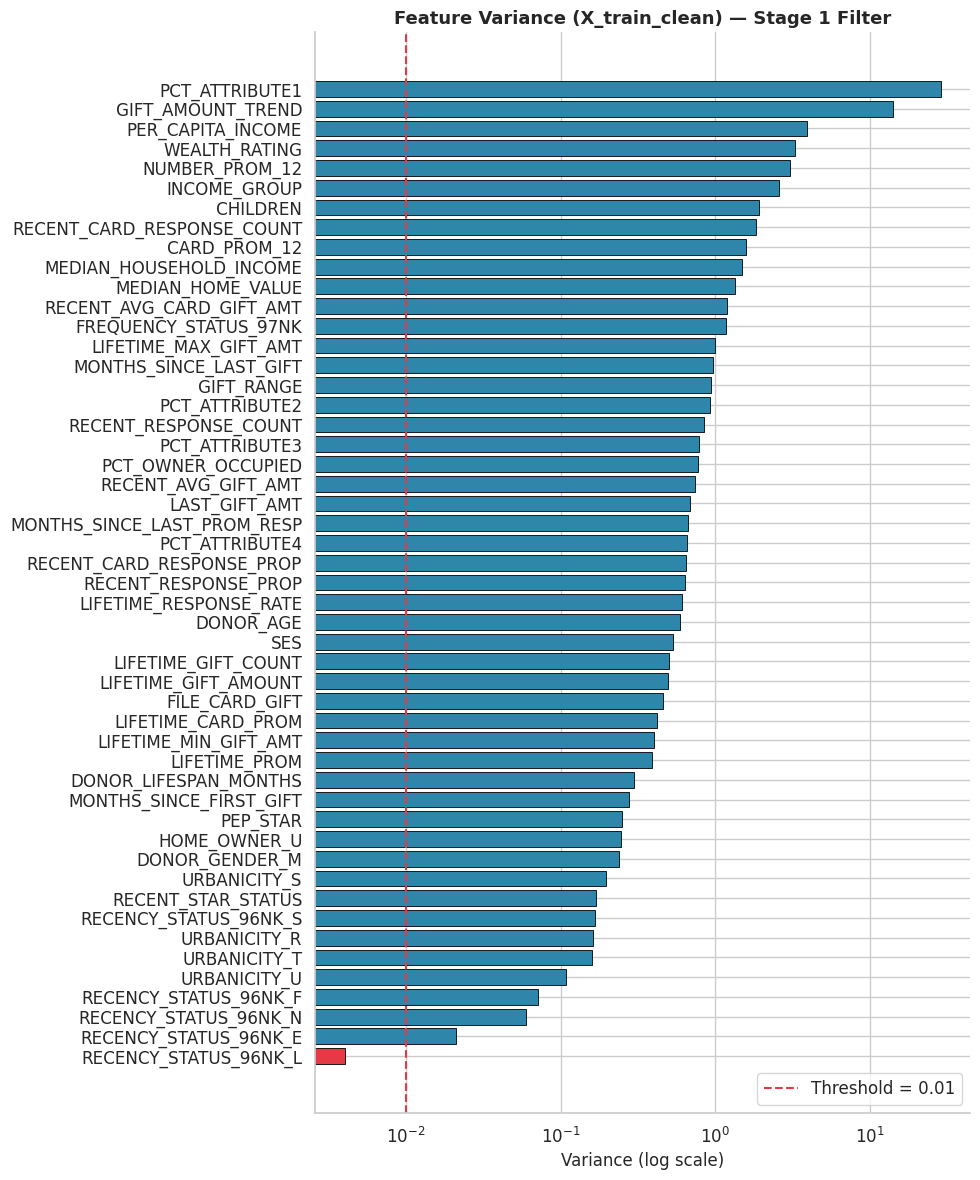

--- Variance Threshold (threshold = 0.01) ---
Features kept:    49
Features dropped: 1

Dropped features (variance < 0.01):
  RECENCY_STATUS_96NK_L          variance = 0.004040

Shape: X_train_clean (10848, 49) | X_val_clean (2712, 49)


In [ ]:
# Filter FS — Stage 1: Variance Threshold (remove near-constant features)
feature_variances = X_train_clean.var().sort_values()

# Plot variance per feature (log x-axis: variances span several orders of magnitude)
fig, ax = plt.subplots(figsize=(10, 12))
colors_var = [COLOR_ACCENT if v < 0.01 else COLOR_PRIMARY for v in feature_variances.values]
ax.barh(feature_variances.index, feature_variances.values,
        color=colors_var, edgecolor=COLOR_BLACK, linewidth=0.6)
ax.axvline(x=0.01, color=COLOR_ACCENT, linestyle='--', linewidth=1.5, label='Threshold = 0.01')
ax.set_xscale('log')
ax.set_title('Feature Variance (X_train_clean) — Stage 1 Filter', fontsize=13, fontweight='bold')
ax.set_xlabel('Variance (log scale)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

# Fit Variance Threshold on train only
VAR_THRESHOLD = 0.01
var_selector = VarianceThreshold(threshold=VAR_THRESHOLD)
var_selector.fit(X_train_clean)
cols_kept_var    = X_train_clean.columns[var_selector.get_support()].tolist()
cols_dropped_var = X_train_clean.columns[~var_selector.get_support()].tolist()

# Apply to both partitions (keep DataFrame structure)
X_train_clean = X_train_clean[cols_kept_var]
X_val_clean   = X_val_clean[cols_kept_var]

# Audit
print(f"--- Variance Threshold (threshold = {VAR_THRESHOLD}) ---")
print(f"Features kept:    {len(cols_kept_var)}")
print(f"Features dropped: {len(cols_dropped_var)}")
if cols_dropped_var:
    print(f"\nDropped features (variance < {VAR_THRESHOLD}):")
    for col in cols_dropped_var:
        print(f"  {col:30s} variance = {feature_variances[col]:.6f}")
print(f"\nShape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

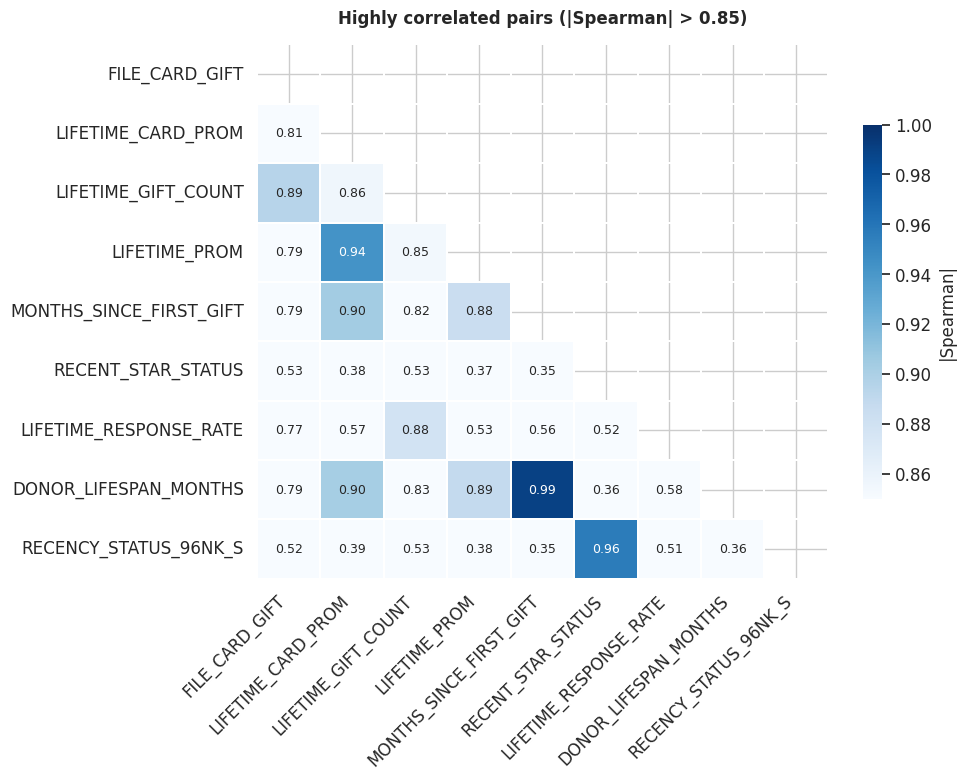


--- Correlation Redundancy Filter (|Spearman| > 0.85) ---
Features kept:    44
Features dropped: 5

Dropped features (with the feature kept in each pair):
  Dropped LIFETIME_PROM                  (MI=0.0071) in favour of MONTHS_SINCE_FIRST_GIFT        (MI=0.0085)
  Dropped RECENT_STAR_STATUS             (MI=0.0000) in favour of RECENCY_STATUS_96NK_S          (MI=0.0017)
  Dropped DONOR_LIFESPAN_MONTHS          (MI=0.0054) in favour of MONTHS_SINCE_FIRST_GIFT        (MI=0.0085)
  Dropped LIFETIME_CARD_PROM             (MI=0.0047) in favour of MONTHS_SINCE_FIRST_GIFT        (MI=0.0085)
  Dropped LIFETIME_GIFT_COUNT            (MI=0.0016) in favour of FILE_CARD_GIFT                 (MI=0.0038)

Shape: X_train_clean (10848, 44) | X_val_clean (2712, 44)


In [ ]:
# Filter FS — Stage 2: Correlation Redundancy (CFS principle, Hall 1999)
# For each pair |Spearman| > threshold, keep the feature with higher MI vs target.
CORR_THRESHOLD = 0.85   # aligned with EDA "critical redundancy" finding

# Spearman correlation matrix on training data
corr_matrix = X_train_clean.corr(method='spearman').abs()

# Identify features involved in at least one strong pair
strong_mask = corr_matrix > CORR_THRESHOLD
np.fill_diagonal(strong_mask.values, False)
strong_cols = strong_mask.any(axis=0)
strong_cols = strong_cols[strong_cols].index.tolist()

# Heatmap of the strongly correlated pairs (if any)
if strong_cols:
    fig, ax = plt.subplots(figsize=(10, 8))
    sub_matrix = corr_matrix.loc[strong_cols, strong_cols]
    mask_tri = np.triu(np.ones_like(sub_matrix, dtype=bool))
    sns.heatmap(sub_matrix, mask=mask_tri, ax=ax,
                cmap=CMAP_SEQUENTIAL, vmin=CORR_THRESHOLD, vmax=1.0,
                annot=True, fmt='.2f', annot_kws={'size': 9},
                linewidths=0.3, linecolor='white',
                cbar_kws={'shrink': 0.7, 'label': '|Spearman|'})
    ax.set_title(f'Highly correlated pairs (|Spearman| > {CORR_THRESHOLD})',
                 fontsize=12, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f"No feature pairs with |Spearman| > {CORR_THRESHOLD}.")

# Tie-breaker: MI vs target per feature (keep the more informative one in each pair)
mi_scores = pd.Series(
    mutual_info_classif(X_train_clean, y_train, random_state=GLOBAL_SEED),
    index=X_train_clean.columns,
)

# For each strong pair, drop the feature with lower MI
to_drop = set()
upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
for col_a in upper_tri.columns:
    for col_b in upper_tri.index:
        if pd.isna(upper_tri.loc[col_b, col_a]) or upper_tri.loc[col_b, col_a] <= CORR_THRESHOLD:
            continue
        if col_a in to_drop or col_b in to_drop:
            continue
        to_drop.add(col_b if mi_scores[col_a] >= mi_scores[col_b] else col_a)

cols_kept_corr = [c for c in X_train_clean.columns if c not in to_drop]

# Apply to both partitions
X_train_clean = X_train_clean[cols_kept_corr]
X_val_clean   = X_val_clean[cols_kept_corr]

# Audit
print(f"\n--- Correlation Redundancy Filter (|Spearman| > {CORR_THRESHOLD}) ---")
print(f"Features kept:    {len(cols_kept_corr)}")
print(f"Features dropped: {len(to_drop)}")
if to_drop:
    print(f"\nDropped features (with the feature kept in each pair):")
    for col in to_drop:
        partners = [p for p in corr_matrix[col][corr_matrix[col] > CORR_THRESHOLD].index
                    if p != col and p not in to_drop]
        partner = partners[0] if partners else 'N/A'
        print(f"  Dropped {col:30s} (MI={mi_scores[col]:.4f}) "
              f"in favour of {partner:30s} (MI={mi_scores.get(partner, 0):.4f})")
print(f"\nShape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

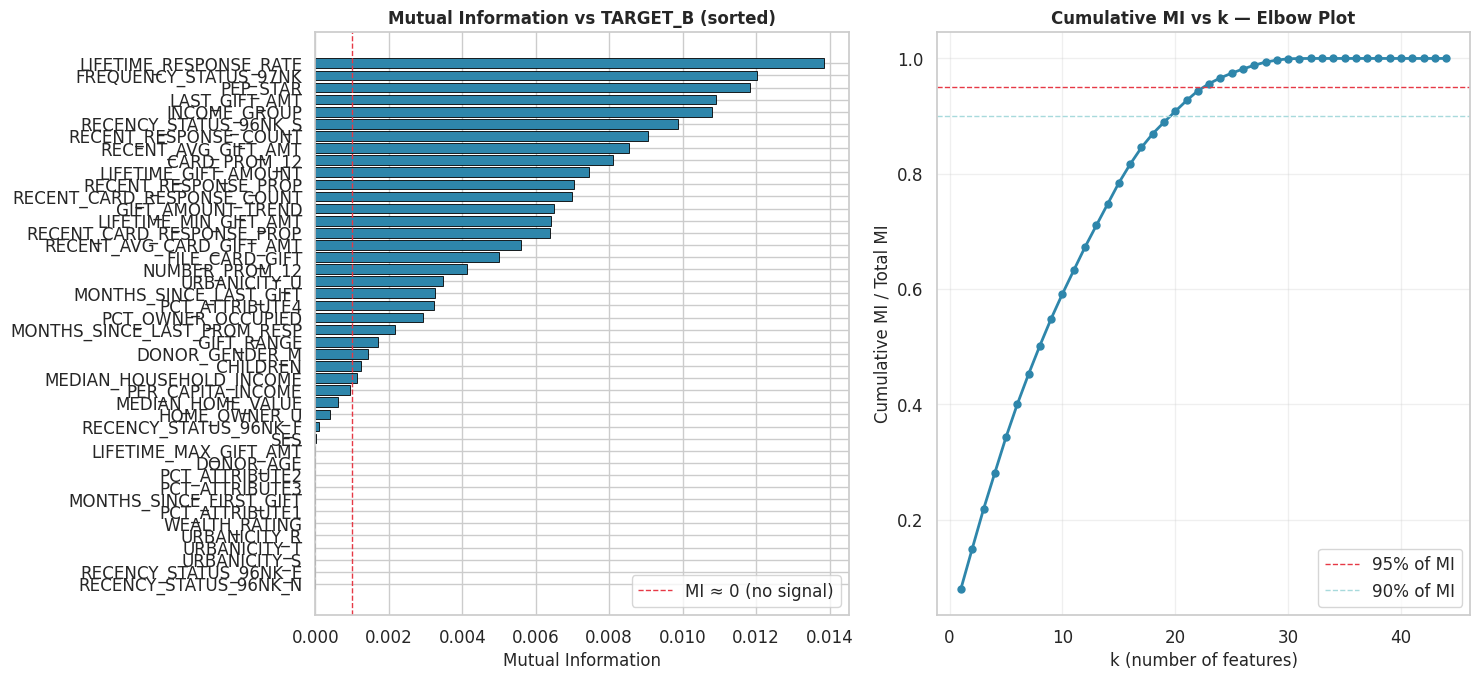

--- Mutual Information ranking (top 20) ---
LIFETIME_RESPONSE_RATE        0.013842
FREQUENCY_STATUS_97NK         0.012012
PEP_STAR                      0.011843
LAST_GIFT_AMT                 0.010901
INCOME_GROUP                  0.010812
RECENCY_STATUS_96NK_S         0.009877
RECENT_RESPONSE_COUNT         0.009045
RECENT_AVG_GIFT_AMT           0.008538
CARD_PROM_12                  0.008101
LIFETIME_GIFT_AMOUNT          0.007449
RECENT_RESPONSE_PROP          0.007035
RECENT_CARD_RESPONSE_COUNT    0.006993
GIFT_AMOUNT_TREND             0.006485
LIFETIME_MIN_GIFT_AMT         0.006417
RECENT_CARD_RESPONSE_PROP     0.006387
RECENT_AVG_CARD_GIFT_AMT      0.005593
FILE_CARD_GIFT                0.005006
NUMBER_PROM_12                0.004137
URBANICITY_U                  0.003469
MONTHS_SINCE_LAST_GIFT        0.003264

--- MI near-zero (bottom features) ---
NUMBER_PROM_12                 0.004137
URBANICITY_U                   0.003469
MONTHS_SINCE_LAST_GIFT         0.003264
PCT_ATTRIBUTE4  

In [ ]:
# Filter FS — Stage 3: Mutual Information ranking + k selection
# MI of remaining features
mi_after_filters = pd.Series(
    mutual_info_classif(X_train_clean, y_train, random_state=GLOBAL_SEED),
    index=X_train_clean.columns,
).sort_values(ascending=False)

# Two-panel view: MI per feature (left) and cumulative-MI elbow for k (right)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left — MI per feature, sorted
axes[0].barh(mi_after_filters.index[::-1], mi_after_filters.values[::-1],
             color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, linewidth=0.6)
axes[0].set_title('Mutual Information vs TARGET_B (sorted)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mutual Information')
axes[0].axvline(x=0.001, color=COLOR_ACCENT, linestyle='--', linewidth=1, label='MI ≈ 0 (no signal)')
axes[0].legend(loc='lower right')

# Right — cumulative MI vs k (elbow guides the cut-point)
cumulative = mi_after_filters.cumsum() / mi_after_filters.sum()
axes[1].plot(range(1, len(cumulative) + 1), cumulative.values,
             marker='o', color=COLOR_PRIMARY, linewidth=2, markersize=5)
axes[1].axhline(y=0.95, color=COLOR_ACCENT, linestyle='--', linewidth=1, label='95% of MI')
axes[1].axhline(y=0.90, color=COLOR_SECONDARY, linestyle='--', linewidth=1, label='90% of MI')
axes[1].set_title('Cumulative MI vs k — Elbow Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k (number of features)')
axes[1].set_ylabel('Cumulative MI / Total MI')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# MI ranking to support the choice of k
print("--- Mutual Information ranking (top 20) ---")
print(mi_after_filters.head(20).to_string())
print(f"\n--- MI near-zero (bottom features) ---")
near_zero = mi_after_filters[mi_after_filters < 0.005]
if len(near_zero) > 0:
    print(near_zero.to_string())

# k chosen from the cumulative-MI elbow (captures ~90-95% of total MI)
K_BEST = 25

# Fit SelectKBest on train only, transform both
mi_selector = SelectKBest(mutual_info_classif, k=K_BEST)
mi_selector.fit(X_train_clean, y_train)
cols_kept_mi    = X_train_clean.columns[mi_selector.get_support()].tolist()
cols_dropped_mi = X_train_clean.columns[~mi_selector.get_support()].tolist()

# Apply to both partitions
X_train_clean = X_train_clean[cols_kept_mi]
X_val_clean   = X_val_clean[cols_kept_mi]

# Audit
print(f"\n--- SelectKBest (k = {K_BEST}) ---")
print(f"Features kept:    {len(cols_kept_mi)}")
print(f"Features dropped: {len(cols_dropped_mi)}")
print(f"\nDropped features (lowest MI):")
for col in cols_dropped_mi:
    print(f"  {col:30s} MI = {mi_after_filters[col]:.6f}")
print(f"\nFinal shape: X_train_clean {X_train_clean.shape} | X_val_clean {X_val_clean.shape}")

Three-stage filter: **50 → 25 features** (50% reduction, aligned with Cacciarelli & Boresta, 2022).

- **Stage 1** dropped `RECENCY_STATUS_96NK_L` (rare "Lapsing" status).
- **Stage 2** dropped 5 features in correlation clusters — notably `DONOR_LIFESPAN_MONTHS` (redundant with `MONTHS_SINCE_FIRST_GIFT`) and lifetime-aggregated features.
- **Stage 3** selected the top 25 by MI, capturing the bulk of total MI. Max MI = **0.014** is modest, consistent with EDA noise injection and the difficulty reported for KDD Cup '98-style datasets.

**`LIFETIME_RESPONSE_RATE` is the single most informative variable** (MI = 0.014, rank 1), in line with the engineered-feature approach of Georges & Milley (1999). Two of the four engineered features survived all stages.

# III. Binary Classification and Optimization

## Baselines — ZeroR and Stratified Random

Two `DummyClassifier` baselines establish the floor any candidate must clearly beat:

1. **ZeroR** (`strategy='most_frequent'`) — always predicts non-donor. Achieves ~75% accuracy but **F1 = 0** (no donors predicted). Shows accuracy is misleading under imbalance.
2. **Stratified random** (`strategy='stratified'`) — predicts at random respecting class proportions. F1 ≈ 0.25 — the non-zero floor any model must outperform to demonstrate genuine learning.


In [ ]:
# Baseline models — floor performance for F1 and accuracy
# ZeroR: predicts majority class | Stratified: predicts respecting class proportions
baselines = {
    'ZeroR (most_frequent)': DummyClassifier(strategy='most_frequent'),
    'Stratified'           : DummyClassifier(strategy='stratified', random_state=GLOBAL_SEED),
}

# Fit each baseline and evaluate F1 + accuracy on validation
baseline_results = []
for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    baseline_results.append({
        'Baseline'        : name,
        'F1 (score)'      : round(f1_score(y_val, y_pred), 4),
        'Accuracy (score)': round((y_pred == y_val).mean(), 4),
    })

baseline_df = pd.DataFrame(baseline_results)
print("Baseline results (evaluated on X_val):")
print(baseline_df.to_string(index=False))

Baseline results (evaluated on X_val):
             Baseline  F1 (score)  Accuracy (score)
ZeroR (most_frequent)      0.0000            0.7500
           Stratified      0.2568            0.6287


## Model Screening

We screen **8 algorithms** across main families: probabilistic (GaussianNB), discriminant (LDA), linear (LR), tree (DT), bagging ensembles (RF, Bagging), boosting ensembles (AdaBoost, GB). Hyperparameters are literature-informed with **aggressive regularisation** justified by the weak signal (max MI = 0.014).

| Model | Hyperparameters | Reference |
|-------|----------------|-----------|
| **GaussianNB** | `priors=[0.5, 0.5]` | — |
| **LDA** | default + balanced priors | Fisher (1936), *Annals of Eugenics* 7:179-188 |
| **LogReg** | `class_weight='balanced'`, L2 | Hastie et al. (2009), ESL |
| **DecisionTree** | `max_depth=8, min_samples_leaf=20, class_weight='balanced'` | Hastie et al. (2009) |
| **RandomForest** | `n_estimators=300, max_depth=10, max_features='sqrt', min_samples_leaf=20` | Probst, Wright & Boulesteix (2019), *WIREs DMKD* 9:e1301 — `min_samples_leaf ≈ 0.2%` of train size is the most effective regulariser for noisy data |
| **AdaBoost** | stumps + balanced `sample_weight` | Freund & Schapire (1997), *JCSS* 55:119-139 |
| **Bagging** | base DT (`max_depth=5, min_samples_leaf=50`) | Breiman (1996), *ML* 24:123-140 — stabilised base prevents aggregating memorised noise |
| **GradientBoosting** | `learning_rate=0.05, max_depth=4, subsample=0.8, n_iter_no_change=10` | Friedman (2001), *Annals of Statistics* 29:1189-1232; Friedman (2002) — native early stopping prevents late-iteration overfit |

Top performers by F1 (val) and overfit gap proceed to error correlation analysis (Kuncheva & Whitaker, 2003).

In [ ]:
# Screening setup — fit/evaluate helper and balanced weights for boosting
# Single-threaded (N_JOBS=1) for full reproducibility: parallel aggregation can
# introduce minor numerical variation even with random_state fixed.
screening_results = {}

# Fit a model and return F1 (train/val), overfit gap, predictions, and reports
def evaluate_model(model, model_name, X_tr, y_tr, X_va, y_va,
                   verbose=True, sample_weight=None):
    t0 = time.time()
    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    y_pred_train = model.predict(X_tr)
    y_pred_val   = model.predict(X_va)
    f1_train = f1_score(y_tr, y_pred_train, pos_label=1)
    f1_val   = f1_score(y_va, y_pred_val,   pos_label=1)

    report_train = classification_report(y_tr, y_pred_train,
                                         target_names=['Non-donor', 'Donor'], digits=4)
    report_val   = classification_report(y_va, y_pred_val,
                                         target_names=['Non-donor', 'Donor'], digits=4)

    result = {
        'model': model,
        'f1_train': f1_train, 'f1_val': f1_val,
        'overfit_gap': f1_train - f1_val,
        'y_pred_train': y_pred_train, 'y_pred_val': y_pred_val,
        'fit_time': fit_time,
        'report_train': report_train, 'report_val': report_val,
    }

    if verbose:
        print(f"=== {model_name} ===")
        print(f"Fit time: {fit_time:.2f}s\n")
        print(f"F1 (train) = {f1_train:.4f}")
        print(f"F1 (val)   = {f1_val:.4f}")
        print(f"Overfit gap (train - val) = {result['overfit_gap']:+.4f}\n")
        print("--- Classification Report (TRAIN) ---")
        print(report_train)
        print("--- Classification Report (VAL) ---")
        print(report_val)

    return result

# Balanced sample weights for boosting models (used via sample_weight)
n = len(y_train)
w_pos = n / (2 * (y_train == 1).sum())
w_neg = n / (2 * (y_train == 0).sum())
sample_weights_train = np.where(y_train == 1, w_pos, w_neg)

print(f"Screening setup complete (seed={GLOBAL_SEED}, n_jobs={N_JOBS}).")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_val_clean   shape: {X_val_clean.shape}")
print(f"Balanced sample weights: w_neg={w_neg:.3f}, w_pos={w_pos:.3f}")

Screening setup complete (seed=42, n_jobs=1).
X_train_clean shape: (10848, 25)
X_val_clean   shape: (2712, 25)
Balanced sample weights: w_neg=0.667, w_pos=2.000


In [ ]:
# Screening — GaussianNB
# Bayesian classifier assuming feature independence.
# priors=[0.5, 0.5] is the NB-native equivalent of class_weight='balanced'.
gnb = GaussianNB(priors=[0.5, 0.5])

screening_results['GaussianNB'] = evaluate_model(
    gnb, 'GaussianNB',
    X_train_clean, y_train, X_val_clean, y_val,
)

=== GaussianNB ===
Fit time: 0.01s

F1 (train) = 0.3972
F1 (val)   = 0.3750
Overfit gap (train - val) = +0.0222

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.7986    0.6678    0.7274      8136
       Donor     0.3318    0.4948    0.3972      2712

    accuracy                         0.6245     10848
   macro avg     0.5652    0.5813    0.5623     10848
weighted avg     0.6819    0.6245    0.6448     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7875    0.6559    0.7157      2034
       Donor     0.3124    0.4690    0.3750       678

    accuracy                         0.6091      2712
   macro avg     0.5499    0.5624    0.5453      2712
weighted avg     0.6687    0.6091    0.6305      2712



In [ ]:
# Screening — LinearDiscriminantAnalysis
# Models within-class covariance, relaxing GaussianNB's independence assumption.
# Suited to correlated feature spaces (Fisher 1936; Hastie et al. 2009, Ch. 4).
lda = LinearDiscriminantAnalysis(priors=[0.5, 0.5])

screening_results['LDA'] = evaluate_model(
    lda, 'LDA',
    X_train_clean, y_train, X_val_clean, y_val,
)

=== LDA ===
Fit time: 0.03s

F1 (train) = 0.4125
F1 (val)   = 0.3867
Overfit gap (train - val) = +0.0258

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8073    0.6224    0.7029      8136
       Donor     0.3285    0.5542    0.4125      2712

    accuracy                         0.6054     10848
   macro avg     0.5679    0.5883    0.5577     10848
weighted avg     0.6876    0.6054    0.6303     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7922    0.6072    0.6874      2034
       Donor     0.3070    0.5221    0.3867       678

    accuracy                         0.5859      2712
   macro avg     0.5496    0.5647    0.5371      2712
weighted avg     0.6709    0.5859    0.6123      2712



In [ ]:
# Screening — LogisticRegression
# Parametric linear model with L2 regularisation; class_weight='balanced' for imbalance.
lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    random_state=GLOBAL_SEED,
    max_iter=2000,
)

screening_results['LogisticRegression'] = evaluate_model(
    lr, 'LogisticRegression',
    X_train_clean, y_train, X_val_clean, y_val,
)

=== LogisticRegression ===
Fit time: 0.08s

F1 (train) = 0.4119
F1 (val)   = 0.3882
Overfit gap (train - val) = +0.0237

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8071    0.6126    0.6965      8136
       Donor     0.3255    0.5608    0.4119      2712

    accuracy                         0.5996     10848
   macro avg     0.5663    0.5867    0.5542     10848
weighted avg     0.6867    0.5996    0.6254     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7928    0.5944    0.6794      2034
       Donor     0.3050    0.5339    0.3882       678

    accuracy                         0.5793      2712
   macro avg     0.5489    0.5642    0.5338      2712
weighted avg     0.6708    0.5793    0.6066      2712



In [ ]:
# Screening — DecisionTree
# Mild regularisation to prevent catastrophic overfit of default depth on weak signal.
dt = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=GLOBAL_SEED,
)
screening_results['DecisionTree'] = evaluate_model(
    dt, 'DecisionTree', X_train_clean, y_train, X_val_clean, y_val,
)

=== DecisionTree ===
Fit time: 0.10s

F1 (train) = 0.4563
F1 (val)   = 0.3666
Overfit gap (train - val) = +0.0897

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8312    0.6568    0.7338      8136
       Donor     0.3682    0.5999    0.4563      2712

    accuracy                         0.6426     10848
   macro avg     0.5997    0.6284    0.5951     10848
weighted avg     0.7155    0.6426    0.6644     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7803    0.5973    0.6767      2034
       Donor     0.2909    0.4956    0.3666       678

    accuracy                         0.5719      2712
   macro avg     0.5356    0.5465    0.5217      2712
weighted avg     0.6580    0.5719    0.5992      2712



In [ ]:
# Screening — RandomForest (Breiman 2001; Probst et al. 2019)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, max_features='sqrt',
    min_samples_leaf=20, min_samples_split=20,
    class_weight='balanced', random_state=GLOBAL_SEED, n_jobs=N_JOBS,
)
screening_results['RandomForest'] = evaluate_model(
    rf, 'RandomForest', X_train_clean, y_train, X_val_clean, y_val,
)

=== RandomForest ===
Fit time: 5.61s

F1 (train) = 0.5333
F1 (val)   = 0.3580
Overfit gap (train - val) = +0.1754

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8548    0.7817    0.8166      8136
       Donor     0.4789    0.6018    0.5333      2712

    accuracy                         0.7367     10848
   macro avg     0.6669    0.6917    0.6750     10848
weighted avg     0.7608    0.7367    0.7458     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7833    0.7266    0.7539      2034
       Donor     0.3261    0.3968    0.3580       678

    accuracy                         0.6442      2712
   macro avg     0.5547    0.5617    0.5559      2712
weighted avg     0.6690    0.6442    0.6549      2712



In [ ]:
# Screening — AdaBoost (Freund & Schapire 1997); balanced sample_weight applied
ab = AdaBoostClassifier(
    n_estimators=100, learning_rate=1.0, random_state=GLOBAL_SEED,
)
screening_results['AdaBoost'] = evaluate_model(
    ab, 'AdaBoost', X_train_clean, y_train, X_val_clean, y_val,
    sample_weight=sample_weights_train,
)

=== AdaBoost ===
Fit time: 1.74s

F1 (train) = 0.4114
F1 (val)   = 0.3567
Overfit gap (train - val) = +0.0547

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8063    0.6356    0.7108      8136
       Donor     0.3315    0.5420    0.4114      2712

    accuracy                         0.6122     10848
   macro avg     0.5689    0.5888    0.5611     10848
weighted avg     0.6876    0.6122    0.6360     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7755    0.6062    0.6805      2034
       Donor     0.2861    0.4735    0.3567       678

    accuracy                         0.5730      2712
   macro avg     0.5308    0.5398    0.5186      2712
weighted avg     0.6531    0.5730    0.5995      2712



In [ ]:
# Screening — Bagging (Breiman 1996); stabilised base DT
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=50,
        class_weight='balanced', random_state=GLOBAL_SEED,
    ),
    n_estimators=100, random_state=GLOBAL_SEED, n_jobs=N_JOBS,
)
screening_results['Bagging'] = evaluate_model(
    bag, 'Bagging', X_train_clean, y_train, X_val_clean, y_val,
)

=== Bagging ===
Fit time: 3.60s

F1 (train) = 0.4301
F1 (val)   = 0.3578
Overfit gap (train - val) = +0.0723

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8158    0.6645    0.7324      8136
       Donor     0.3532    0.5498    0.4301      2712

    accuracy                         0.6358     10848
   macro avg     0.5845    0.6071    0.5812     10848
weighted avg     0.7001    0.6358    0.6568     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7781    0.6362    0.7000      2034
       Donor     0.2946    0.4558    0.3578       678

    accuracy                         0.5911      2712
   macro avg     0.5363    0.5460    0.5289      2712
weighted avg     0.6572    0.5911    0.6145      2712



In [ ]:
# Screening — GradientBoosting (Friedman 2001, 2002)
# Small learning rate, shallow trees, subsampling, native early stopping.
gb = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8,
    n_iter_no_change=10, validation_fraction=0.15, tol=1e-4,
    random_state=GLOBAL_SEED,
)
screening_results['GradientBoosting'] = evaluate_model(
    gb, 'GradientBoosting', X_train_clean, y_train, X_val_clean, y_val,
    sample_weight=sample_weights_train,
)

=== GradientBoosting ===
Fit time: 1.42s

F1 (train) = 0.4491
F1 (val)   = 0.3710
Overfit gap (train - val) = +0.0781

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

   Non-donor     0.8257    0.6720    0.7409      8136
       Donor     0.3686    0.5745    0.4491      2712

    accuracy                         0.6476     10848
   macro avg     0.5971    0.6232    0.5950     10848
weighted avg     0.7114    0.6476    0.6680     10848

--- Classification Report (VAL) ---
              precision    recall  f1-score   support

   Non-donor     0.7848    0.6382    0.7039      2034
       Donor     0.3043    0.4749    0.3710       678

    accuracy                         0.5973      2712
   macro avg     0.5446    0.5565    0.5374      2712
weighted avg     0.6647    0.5973    0.6207      2712



Baselines:
  ZeroR (always majority): F1 = 0.0000
  Stratified (random):     F1 ≈ 0.2568

--- Screening Results (8 models, sorted by F1 val) ---
             Model  F1 (Train)  F1 (Val)  Overfit Gap  Fit Time (s)
LogisticRegression    0.411916  0.388204     0.023712      0.081792
               LDA    0.412515  0.386674     0.025841      0.025703
        GaussianNB    0.397218  0.375000     0.022218      0.012745
  GradientBoosting    0.449056  0.370968     0.078088      1.422104
      DecisionTree    0.456317  0.366612     0.089705      0.102077
      RandomForest    0.533333  0.357951     0.175383      5.605149
           Bagging    0.430117  0.357846     0.072271      3.598712
          AdaBoost    0.411361  0.356667     0.054695      1.740555


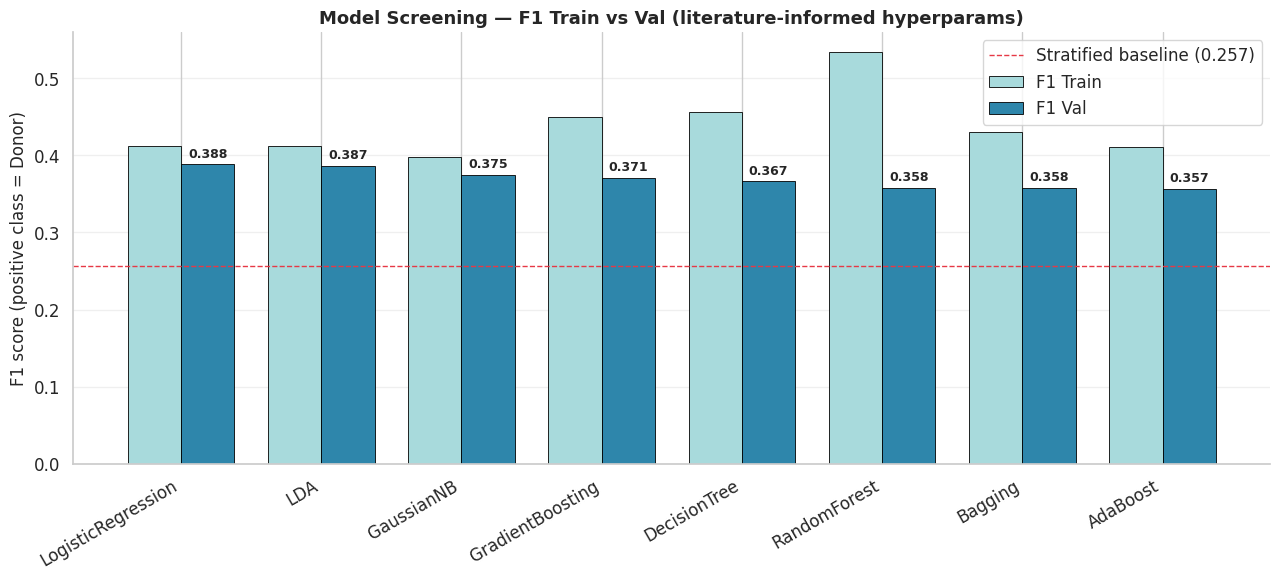


--- Top 4 by F1 val ---
             Model  F1 (Train)  F1 (Val)  Overfit Gap  Fit Time (s)
LogisticRegression    0.411916  0.388204     0.023712      0.081792
               LDA    0.412515  0.386674     0.025841      0.025703
        GaussianNB    0.397218  0.375000     0.022218      0.012745
  GradientBoosting    0.449056  0.370968     0.078088      1.422104


In [ ]:
# Screening — comparison of all models against the stratified baseline
strat_baseline = DummyClassifier(strategy='stratified', random_state=GLOBAL_SEED)
strat_baseline.fit(X_train_clean, y_train)
f1_strat_val = f1_score(y_val, strat_baseline.predict(X_val_clean), pos_label=1)

# Build sorted comparison table
comparison_df = pd.DataFrame([
    {'Model': name, 'F1 (Train)': r['f1_train'], 'F1 (Val)': r['f1_val'],
     'Overfit Gap': r['overfit_gap'], 'Fit Time (s)': r['fit_time']}
    for name, r in screening_results.items()
]).sort_values('F1 (Val)', ascending=False).reset_index(drop=True)

print("Baselines:")
print(f"  ZeroR (always majority): F1 = 0.0000")
print(f"  Stratified (random):     F1 ≈ {f1_strat_val:.4f}\n")
print(f"--- Screening Results ({len(comparison_df)} models, sorted by F1 val) ---")
print(comparison_df.to_string(index=False))

# Grouped bar chart: F1 train vs val per model
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(comparison_df))
width = 0.38
ax.bar(x - width/2, comparison_df['F1 (Train)'], width,
       label='F1 Train', color=COLOR_SECONDARY, edgecolor=COLOR_BLACK, linewidth=0.6)
bars_val = ax.bar(x + width/2, comparison_df['F1 (Val)'], width,
                  label='F1 Val', color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, linewidth=0.6)
ax.axhline(y=f1_strat_val, color=COLOR_ACCENT, linestyle='--', linewidth=1,
           label=f'Stratified baseline ({f1_strat_val:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax.set_ylabel('F1 score (positive class = Donor)')
ax.set_title('Model Screening — F1 Train vs Val (literature-informed hyperparams)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
sns.despine()
for bar, val in zip(bars_val, comparison_df['F1 (Val)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- Top 4 by F1 val ---")
print(comparison_df.head(4).to_string(index=False))

## Error Correlation Analysis between Models

Before selecting finalists we examine **error complementarity** between screened models (Kuncheva & Whitaker, 2003, *Machine Learning* 51:181-207). Ensemble methods gain accuracy when base learners commit *complementary errors*; models that misclassify the same instances add no diversity.

We compute the Pearson correlation between error vectors (1 if misclassified, 0 if correct) on the validation set:

- **corr ≈ 1.0** → identical errors (redundant)
- **corr ≈ 0.5** → moderately complementary
- **corr ≈ 0.0** → independent errors (ideal for ensembling)

Finalists are selected for **error diversity**, not raw F1 — maximising the complementarity that drives ensemble gains.

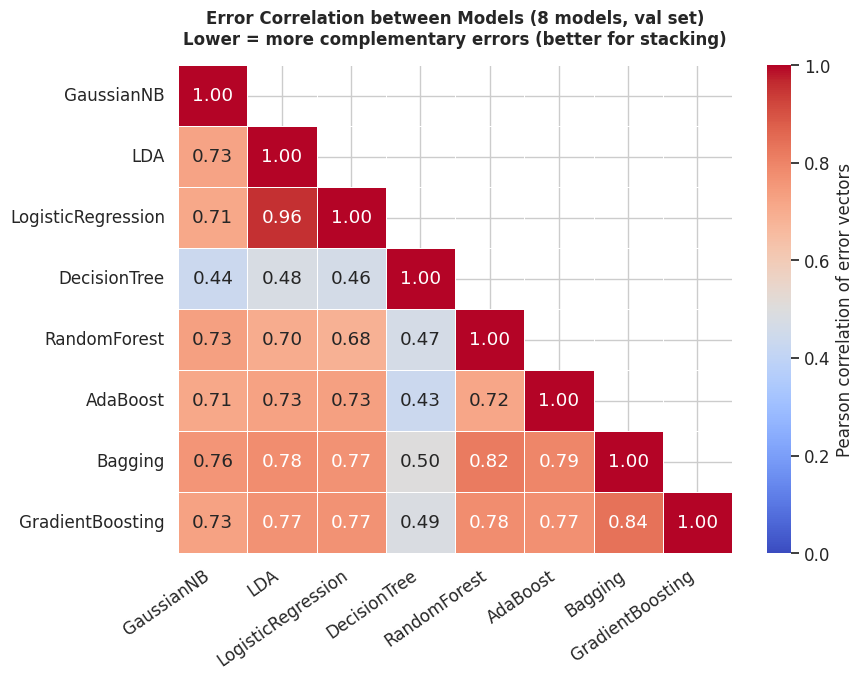

--- Most COMPLEMENTARY pairs (lowest error correlation) ---
  DecisionTree              ↔ AdaBoost                   corr = 0.434
  GaussianNB                ↔ DecisionTree               corr = 0.436
  LogisticRegression        ↔ DecisionTree               corr = 0.464
  DecisionTree              ↔ RandomForest               corr = 0.467
  LDA                       ↔ DecisionTree               corr = 0.478

--- Most REDUNDANT pairs (highest error correlation) ---
  RandomForest              ↔ GradientBoosting           corr = 0.780
  AdaBoost                  ↔ Bagging                    corr = 0.794
  RandomForest              ↔ Bagging                    corr = 0.820
  Bagging                   ↔ GradientBoosting           corr = 0.837
  LDA                       ↔ LogisticRegression         corr = 0.956


In [ ]:
# Error correlation analysis (Kuncheva & Whitaker 2003)
# For each model pair, Pearson correlation of error vectors on val
# (1 = misclassified, 0 = correct). Low correlation = complementary errors.

# Build error matrix: rows = models, columns = val instances
model_names = list(screening_results.keys())
error_matrix = np.zeros((len(model_names), len(y_val)))
for i, name in enumerate(model_names):
    error_matrix[i] = (screening_results[name]['y_pred_val'] != y_val.values).astype(int)

# Pearson correlation between every pair of error vectors
corr_matrix = np.zeros((len(model_names), len(model_names)))
for i in range(len(model_names)):
    for j in range(len(model_names)):
        corr_matrix[i, j] = 1.0 if i == j else pearsonr(error_matrix[i], error_matrix[j])[0]

# Heatmap of error correlations
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap=CMAP_DIVERGING, vmin=0, vmax=1,
    xticklabels=model_names, yticklabels=model_names,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson correlation of error vectors'}, ax=ax,
)
ax.set_title(f'Error Correlation between Models ({len(model_names)} models, val set)\n'
             'Lower = more complementary errors (better for stacking)',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Rank pairs by complementarity
pairs = []
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        pairs.append((model_names[i], model_names[j], corr_matrix[i, j]))
pairs.sort(key=lambda x: x[2])

# Most complementary (lowest correlation) and most redundant (highest)
print("--- Most COMPLEMENTARY pairs (lowest error correlation) ---")
for a, b, c in pairs[:5]:
    print(f"  {a:25s} ↔ {b:25s}  corr = {c:.3f}")
print("\n--- Most REDUNDANT pairs (highest error correlation) ---")
for a, b, c in pairs[-5:]:
    print(f"  {a:25s} ↔ {b:25s}  corr = {c:.3f}")

## Finalist Selection

Based on the error correlation matrix above, we select **four finalists** spanning four families and exhibiting low mutual error correlation:

| Finalist | Family | Selection rationale |
|----------|--------|---------------------|
| **LogisticRegression** | Linear | Top F1 + minimal overfit gap (~0.02) — anchor of the linear family |
| **GradientBoosting** | Boosting | Strong non-linear performer with controlled overfit |
| **DecisionTree** | Tree | Appears in all top complementary pairs (corr 0.43–0.48) — strongest diversifier |
| **GaussianNB** | Probabilistic | Near-zero overfit + low error correlation with DT (0.44) |

**Excluded** despite competitive F1:
- **LDA** — error correlation with LR ≈ 0.96 (functionally equivalent on scaled features); LR retained for marginally higher F1.
- **RandomForest, Bagging** — high mutual correlation (RF ↔ Bagging ≈ 0.82, Bagging ↔ GB ≈ 0.84) and RF ↔ GB ≈ 0.78; tree-based ensembles converge to similar error regions on weak-signal data, providing no diversity beyond GB.

Selection prioritises **algorithmic and error-pattern diversity** over raw F1 ranking, ensuring downstream tuning invests in genuinely complementary candidates.

## Hyperparameter Tuning

We tune the four finalists (LR, GB, DT, GNB) using a combined **Random Search + Grid Search** protocol with **5-fold StratifiedKFold within the training set**:

1. **Random Search** — wide exploration with log-scale sampling for multiplicative-effect hyperparameters (Bergstra & Bengio, 2012, *JMLR* 13:281-305). Conservative ranges avoid extreme regions that overfit CV folds.
2. **Grid Search** — narrow refinement around the best Random Search candidate.
3. **Robust selection** — among the three candidate configurations (Screening defaults, Random best, Grid best), the one with best **validation F1** is retained. This is not data leakage: val never participates in fitting; it only arbitrates between pre-defined configurations. This protocol mitigates the **CV optimization bias** (Cawley & Talbot, 2010, *JMLR* 11:2079-2107), the well-documented effect that CV-selected hyperparameters can overstate generalisation when the search space is large.

The held-out validation set is otherwise reserved for final evaluation.

In [ ]:
# Tuning setup — 5-fold StratifiedKFold inside the training set (val untouched)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
f1_scorer = make_scorer(f1_score, pos_label=1)
tuning_results = {}

print(f"5-fold StratifiedKFold ready (random_state={GLOBAL_SEED}).")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_val_clean   shape: {X_val_clean.shape} (held out — untouched)")

5-fold StratifiedKFold ready (random_state=42).
X_train_clean shape: (10848, 25)
X_val_clean   shape: (2712, 25) (held out — untouched)


In [ ]:
# Tuning — LogisticRegression: Random + Grid + Robust Selection
# Conservative C range avoids extreme regularisation (Cawley & Talbot 2010).
lr_random_space = {
    'C':       loguniform(1e-2, 1e1),
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear'],
}
lr_base = LogisticRegression(class_weight='balanced', random_state=GLOBAL_SEED, max_iter=2000)

# Random Search — wide exploration
lr_random = RandomizedSearchCV(
    estimator=lr_base, param_distributions=lr_random_space, n_iter=40,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, random_state=GLOBAL_SEED, verbose=1,
)
t0 = time.time()
lr_random.fit(X_train_clean, y_train)
print(f"\n[Random] Time: {time.time()-t0:.1f}s | Best F1 CV: {lr_random.best_score_:.4f}")
print(f"[Random] Best params: {lr_random.best_params_}\n")

# Grid Search — refine around the Random best
best_C = lr_random.best_params_['C']
lr_grid_space = {
    'C':       sorted(set([best_C/2, best_C/1.5, best_C, best_C*1.5, best_C*2])),
    'penalty': [lr_random.best_params_['penalty']],
    'solver':  [lr_random.best_params_['solver']],
}
lr_grid = GridSearchCV(
    estimator=lr_base, param_grid=lr_grid_space,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, verbose=1,
)
t0 = time.time()
lr_grid.fit(X_train_clean, y_train)
print(f"\n[Grid] Time: {time.time()-t0:.1f}s | Best F1 CV: {lr_grid.best_score_:.4f}")
print(f"[Grid] Best params: {lr_grid.best_params_}\n")

# Robust selection — compare Screening / Random / Grid on val, keep best
lr_screening = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs',
    class_weight='balanced', random_state=GLOBAL_SEED, max_iter=2000,
)
lr_screening.fit(X_train_clean, y_train)

f1_screen = f1_score(y_val, lr_screening.predict(X_val_clean), pos_label=1)
f1_random = f1_score(y_val, lr_random.best_estimator_.predict(X_val_clean), pos_label=1)
f1_grid   = f1_score(y_val, lr_grid.best_estimator_.predict(X_val_clean), pos_label=1)

candidates = {
    'Screening': (lr_screening, f1_screen),
    'Random':    (lr_random.best_estimator_, f1_random),
    'Grid':      (lr_grid.best_estimator_, f1_grid),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_estimator, best_f1 = candidates[best_name]

print("--- LR candidates (F1 on val) ---")
print(f"  Screening : {f1_screen:.4f}")
print(f"  Random    : {f1_random:.4f}")
print(f"  Grid      : {f1_grid:.4f}")
print(f"\n>>> Selected: {best_name} (F1 val = {best_f1:.4f}) <<<")

tuning_results['LR'] = {
    'best_estimator': best_estimator, 'best_params': best_estimator.get_params(),
    'selected_from': best_name, 'val_score': best_f1,
}

Fitting 5 folds for each of 40 candidates, totalling 200 fits

[Random] Time: 13.3s | Best F1 CV: 0.4084
[Random] Best params: {'C': np.float64(0.035506214270707714), 'penalty': 'l2', 'solver': 'liblinear'}

Fitting 5 folds for each of 5 candidates, totalling 25 fits

[Grid] Time: 1.2s | Best F1 CV: 0.4084
[Grid] Best params: {'C': np.float64(0.035506214270707714), 'penalty': 'l2', 'solver': 'liblinear'}

--- LR candidates (F1 on val) ---
  Screening : 0.3882
  Random    : 0.3908
  Grid      : 0.3908

>>> Selected: Random (F1 val = 0.3908) <<<


In [ ]:
# Tuning — DecisionTree: Random + Grid + Robust Selection (Hastie et al. 2009, Ch. 9)
dt_random_space = {
    'max_depth':         randint(4, 15),
    'min_samples_leaf':  randint(10, 100),
    'min_samples_split': randint(10, 50),
    'criterion':         ['gini', 'entropy'],
}
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=GLOBAL_SEED)

# Random Search
dt_random = RandomizedSearchCV(
    estimator=dt_base, param_distributions=dt_random_space, n_iter=40,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, random_state=GLOBAL_SEED, verbose=1,
)
t0 = time.time()
dt_random.fit(X_train_clean, y_train)
print(f"\n[Random] Time: {time.time()-t0:.1f}s | Best F1 CV: {dt_random.best_score_:.4f}")
print(f"[Random] Best params: {dt_random.best_params_}\n")

# Grid Search — refine around the Random best
best = dt_random.best_params_
dt_grid_space = {
    'max_depth':         sorted(set([max(2, best['max_depth']-2), best['max_depth'], best['max_depth']+2])),
    'min_samples_leaf':  sorted(set([max(2, best['min_samples_leaf']-10), best['min_samples_leaf'], best['min_samples_leaf']+10])),
    'min_samples_split': [best['min_samples_split']],
    'criterion':         [best['criterion']],
}
dt_grid = GridSearchCV(
    estimator=dt_base, param_grid=dt_grid_space,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, verbose=1,
)
t0 = time.time()
dt_grid.fit(X_train_clean, y_train)
print(f"\n[Grid] Time: {time.time()-t0:.1f}s | Best F1 CV: {dt_grid.best_score_:.4f}")
print(f"[Grid] Best params: {dt_grid.best_params_}\n")

# Robust selection on val
dt_screening = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=GLOBAL_SEED,
)
dt_screening.fit(X_train_clean, y_train)

f1_screen = f1_score(y_val, dt_screening.predict(X_val_clean), pos_label=1)
f1_random = f1_score(y_val, dt_random.best_estimator_.predict(X_val_clean), pos_label=1)
f1_grid   = f1_score(y_val, dt_grid.best_estimator_.predict(X_val_clean), pos_label=1)

candidates = {
    'Screening': (dt_screening, f1_screen),
    'Random':    (dt_random.best_estimator_, f1_random),
    'Grid':      (dt_grid.best_estimator_, f1_grid),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_estimator, best_f1 = candidates[best_name]

print("--- DT candidates (F1 on val) ---")
print(f"  Screening : {f1_screen:.4f}")
print(f"  Random    : {f1_random:.4f}")
print(f"  Grid      : {f1_grid:.4f}")
print(f"\n>>> Selected: {best_name} (F1 val = {best_f1:.4f}) <<<")

tuning_results['DT'] = {
    'best_estimator': best_estimator, 'best_params': best_estimator.get_params(),
    'selected_from': best_name, 'val_score': best_f1,
}

Fitting 5 folds for each of 40 candidates, totalling 200 fits

[Random] Time: 14.7s | Best F1 CV: 0.3906
[Random] Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 93, 'min_samples_split': 37}

Fitting 5 folds for each of 9 candidates, totalling 45 fits

[Grid] Time: 2.1s | Best F1 CV: 0.3959
[Grid] Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 83, 'min_samples_split': 37}

--- DT candidates (F1 on val) ---
  Screening : 0.3666
  Random    : 0.3652
  Grid      : 0.3800

>>> Selected: Grid (F1 val = 0.3800) <<<


In [ ]:
# Tuning — GaussianNB: Grid + Robust Selection
# Conservative var_smoothing range avoids the trivial limit.
gnb_grid_space = {'var_smoothing': np.logspace(-9, -6, 15)}
gnb_base = GaussianNB(priors=[0.5, 0.5])

# Grid Search
gnb_grid = GridSearchCV(
    estimator=gnb_base, param_grid=gnb_grid_space,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, verbose=1,
)
t0 = time.time()
gnb_grid.fit(X_train_clean, y_train)
print(f"\n[Grid] Time: {time.time()-t0:.1f}s | Best F1 CV: {gnb_grid.best_score_:.4f}")
print(f"[Grid] Best params: {gnb_grid.best_params_}\n")

# Robust selection on val
gnb_screening = GaussianNB(priors=[0.5, 0.5])
gnb_screening.fit(X_train_clean, y_train)

f1_screen = f1_score(y_val, gnb_screening.predict(X_val_clean), pos_label=1)
f1_grid   = f1_score(y_val, gnb_grid.best_estimator_.predict(X_val_clean), pos_label=1)

candidates = {
    'Screening': (gnb_screening, f1_screen),
    'Grid':      (gnb_grid.best_estimator_, f1_grid),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_estimator, best_f1 = candidates[best_name]

print("--- GNB candidates (F1 on val) ---")
print(f"  Screening : {f1_screen:.4f}")
print(f"  Grid      : {f1_grid:.4f}")
print(f"\n>>> Selected: {best_name} (F1 val = {best_f1:.4f}) <<<")

tuning_results['GNB'] = {
    'best_estimator': best_estimator, 'best_params': best_estimator.get_params(),
    'selected_from': best_name, 'val_score': best_f1,
}

Fitting 5 folds for each of 15 candidates, totalling 75 fits

[Grid] Time: 1.0s | Best F1 CV: 0.3947
[Grid] Best params: {'var_smoothing': np.float64(1e-09)}

--- GNB candidates (F1 on val) ---
  Screening : 0.3750
  Grid      : 0.3750

>>> Selected: Screening (F1 val = 0.3750) <<<


In [ ]:
# Tuning — GradientBoosting: Random + Grid + Robust Selection
# Conservative ranges + native early stopping in all candidates (Friedman 2001).
gb_random_space = {
    'n_estimators':     randint(200, 600),
    'learning_rate':    loguniform(0.03, 0.15),
    'max_depth':        randint(3, 6),
    'min_samples_leaf': randint(10, 50),
    'subsample':        uniform(0.6, 0.4),
}
# Base with early stopping forced
gb_base = GradientBoostingClassifier(
    n_iter_no_change=10, validation_fraction=0.15, tol=1e-4, random_state=GLOBAL_SEED,
)

# Random Search
gb_random = RandomizedSearchCV(
    estimator=gb_base, param_distributions=gb_random_space, n_iter=30,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, random_state=GLOBAL_SEED, verbose=1,
)
t0 = time.time()
gb_random.fit(X_train_clean, y_train, sample_weight=sample_weights_train)
print(f"\n[Random] Time: {time.time()-t0:.1f}s ({(time.time()-t0)/60:.1f} min)")
print(f"[Random] Best F1 CV: {gb_random.best_score_:.4f}")
print(f"[Random] Best params: {gb_random.best_params_}\n")

# Grid Search — refine around the Random best
best = gb_random.best_params_
gb_grid_space = {
    'n_estimators':     sorted(set([max(100, best['n_estimators']-50), best['n_estimators'], best['n_estimators']+50])),
    'learning_rate':    sorted(set([best['learning_rate']/1.5, best['learning_rate'], best['learning_rate']*1.5])),
    'max_depth':        sorted(set([max(3, best['max_depth']-1), best['max_depth'], min(6, best['max_depth']+1)])),
    'min_samples_leaf': [best['min_samples_leaf']],
    'subsample':        [best['subsample']],
}
gb_grid = GridSearchCV(
    estimator=gb_base, param_grid=gb_grid_space,
    scoring=f1_scorer, cv=cv, n_jobs=N_JOBS, verbose=1,
)
t0 = time.time()
gb_grid.fit(X_train_clean, y_train, sample_weight=sample_weights_train)
print(f"\n[Grid] Time: {time.time()-t0:.1f}s ({(time.time()-t0)/60:.1f} min)")
print(f"[Grid] Best F1 CV: {gb_grid.best_score_:.4f}")
print(f"[Grid] Best params: {gb_grid.best_params_}\n")

# Robust selection on val
gb_screening = GradientBoostingClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8,
    n_iter_no_change=10, validation_fraction=0.15, tol=1e-4, random_state=GLOBAL_SEED,
)
gb_screening.fit(X_train_clean, y_train, sample_weight=sample_weights_train)

f1_screen = f1_score(y_val, gb_screening.predict(X_val_clean), pos_label=1)
f1_random = f1_score(y_val, gb_random.best_estimator_.predict(X_val_clean), pos_label=1)
f1_grid   = f1_score(y_val, gb_grid.best_estimator_.predict(X_val_clean), pos_label=1)

candidates = {
    'Screening': (gb_screening, f1_screen),
    'Random':    (gb_random.best_estimator_, f1_random),
    'Grid':      (gb_grid.best_estimator_, f1_grid),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_estimator, best_f1 = candidates[best_name]

print("--- GB candidates (F1 on val) ---")
print(f"  Screening : {f1_screen:.4f}")
print(f"  Random    : {f1_random:.4f}")
print(f"  Grid      : {f1_grid:.4f}")
print(f"\n>>> Selected: {best_name} (F1 val = {best_f1:.4f}) <<<")

tuning_results['GB'] = {
    'best_estimator': best_estimator, 'best_params': best_estimator.get_params(),
    'selected_from': best_name, 'val_score': best_f1,
}

Fitting 5 folds for each of 30 candidates, totalling 150 fits

[Random] Time: 168.6s (2.8 min)
[Random] Best F1 CV: 0.4027
[Random] Best params: {'learning_rate': np.float64(0.054816785328198704), 'max_depth': 3, 'min_samples_leaf': 24, 'n_estimators': 306, 'subsample': np.float64(0.9118764001091078)}

Fitting 5 folds for each of 18 candidates, totalling 90 fits

[Grid] Time: 114.8s (1.9 min)
[Grid] Best F1 CV: 0.4027
[Grid] Best params: {'learning_rate': np.float64(0.054816785328198704), 'max_depth': 3, 'min_samples_leaf': 24, 'n_estimators': 256, 'subsample': np.float64(0.9118764001091078)}

--- GB candidates (F1 on val) ---
  Screening : 0.3710
  Random    : 0.3762
  Grid      : 0.3762

>>> Selected: Random (F1 val = 0.3762) <<<


--- Tuning Comparison (sorted by F1 val tuned) ---
Model  F1 Screening  F1 Val (tuned) Selected from  Improvement
   LR      0.388204        0.390841        Random     0.002638
   DT      0.366612        0.380021          Grid     0.013408
   GB      0.370968        0.376183        Random     0.005215
  GNB      0.375000        0.375000     Screening     0.000000


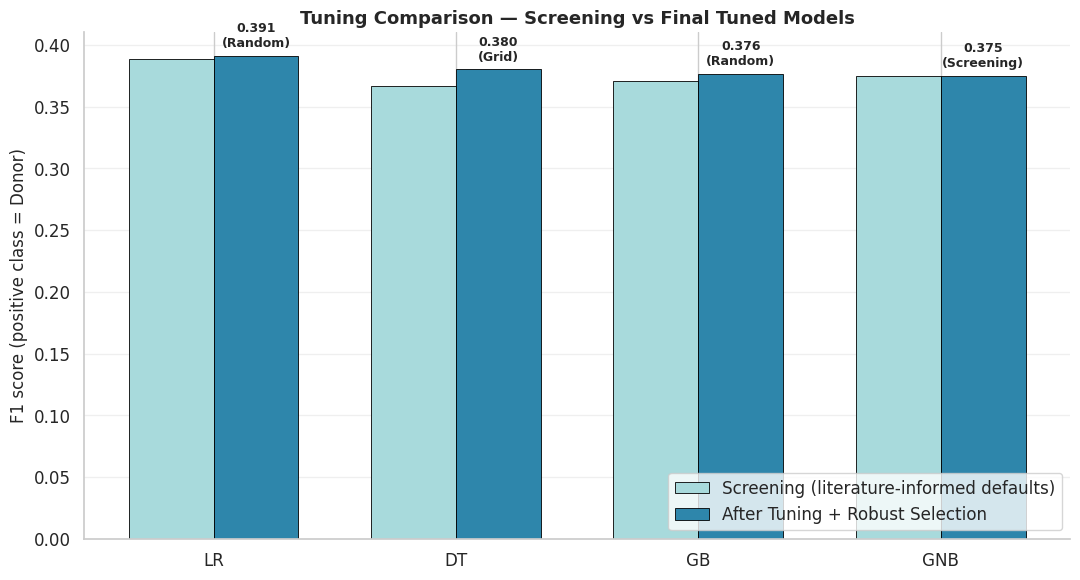


--- Best hyperparameters per finalist ---

LR (selected from Random):
  C: 0.035506214270707714
  penalty: l2
  solver: liblinear

GB (selected from Random):
  max_depth: 3
  min_samples_leaf: 24
  min_samples_split: 2
  criterion: friedman_mse
  n_estimators: 306
  learning_rate: 0.054816785328198704
  subsample: 0.9118764001091078

DT (selected from Grid):
  max_depth: 3
  min_samples_leaf: 83
  min_samples_split: 37
  criterion: gini

GNB (selected from Screening):
  var_smoothing: 1e-09


In [ ]:
# Tuning comparison: F1 before (screening) vs after (tuned + robust selection)
finalists_map = {
    'LR':  'LogisticRegression',
    'GB':  'GradientBoosting',
    'DT':  'DecisionTree',
    'GNB': 'GaussianNB',
}

# Build comparison table
rows = []
for short_name, screen_key in finalists_map.items():
    rows.append({
        'Model':          short_name,
        'F1 Screening':   screening_results[screen_key]['f1_val'],
        'F1 Val (tuned)': tuning_results[short_name]['val_score'],
        'Selected from':  tuning_results[short_name]['selected_from'],
        'Improvement':    tuning_results[short_name]['val_score'] - screening_results[screen_key]['f1_val'],
    })
tuning_df = pd.DataFrame(rows).sort_values('F1 Val (tuned)', ascending=False).reset_index(drop=True)

print("--- Tuning Comparison (sorted by F1 val tuned) ---")
print(tuning_df.to_string(index=False))

# Grouped bar chart: screening vs tuned, annotated with the selected source
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(tuning_df))
width = 0.35
ax.bar(x - width/2, tuning_df['F1 Screening'], width,
       label='Screening (literature-informed defaults)', color=COLOR_SECONDARY,
       edgecolor=COLOR_BLACK, linewidth=0.6)
bars_tuned = ax.bar(x + width/2, tuning_df['F1 Val (tuned)'], width,
                    label='After Tuning + Robust Selection', color=COLOR_PRIMARY,
                    edgecolor=COLOR_BLACK, linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(tuning_df['Model'])
ax.set_ylabel('F1 score (positive class = Donor)')
ax.set_title('Tuning Comparison — Screening vs Final Tuned Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
sns.despine()
for bar, val, source in zip(bars_tuned, tuning_df['F1 Val (tuned)'], tuning_df['Selected from']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}\n({source})', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Best hyperparameters per finalist
print("\n--- Best hyperparameters per finalist ---")
relevant_keys = ['C', 'penalty', 'solver', 'max_depth', 'min_samples_leaf',
                 'min_samples_split', 'criterion', 'n_estimators', 'learning_rate',
                 'subsample', 'var_smoothing']
for short_name in finalists_map:
    print(f"\n{short_name} (selected from {tuning_results[short_name]['selected_from']}):")
    for k in relevant_keys:
        if k in tuning_results[short_name]['best_params']:
            print(f"  {k}: {tuning_results[short_name]['best_params'][k]}")

## Threshold Tuning

The F1-optimal threshold is rarely 0.5 under class imbalance. We apply `TunedThresholdClassifierCV` (sklearn ≥1.5) to each tuned finalist — 5-fold CV on training to identify the F1-maximising threshold. Val remains untouched.

Threshold is treated as a **post-processing hyperparameter** — optimised on training only, evaluated on val.

In [ ]:
# Threshold tuning setup — F1-optimal threshold via 5-fold CV on train (val untouched)
threshold_results = {}

print("Threshold tuning ready (4 finalists: LR, GB, DT, GNB).")
print("5-fold CV inside training set; val held out.")

Threshold tuning ready (4 finalists: LR, GB, DT, GNB).
5-fold CV inside training set; val held out.


In [ ]:
# Threshold tuning — wrap each finalist with TunedThresholdClassifierCV (F1-optimal cut on train)
finalists = ['LR', 'GB', 'DT', 'GNB']

print("=" * 75)
print(f"{'Model':<6} {'Threshold':>10} {'F1 Tuned':>10} {'F1 Thresh':>10} {'Δ F1':>10}")
print("=" * 75)

for name in finalists:
    base_estimator = tuning_results[name]['best_estimator']
    f1_before = tuning_results[name]['val_score']

    # Find F1-optimal threshold via 5-fold CV on train
    t0 = time.time()
    threshold_clf = TunedThresholdClassifierCV(
        estimator=base_estimator, scoring='f1', cv=cv, random_state=GLOBAL_SEED,
    )
    threshold_clf.fit(X_train_clean, y_train)
    fit_time = time.time() - t0

    # Evaluate the tuned-threshold model on val
    f1_after = f1_score(y_val, threshold_clf.predict(X_val_clean), pos_label=1)
    best_threshold = threshold_clf.best_threshold_
    delta = f1_after - f1_before

    print(f"{name:<6} {best_threshold:>10.4f} {f1_before:>10.4f} {f1_after:>10.4f} "
          f"{delta:>+10.4f}   ({fit_time:.0f}s)")

    threshold_results[name] = {
        'estimator': threshold_clf,
        'best_threshold': best_threshold,
        'f1_before_threshold': f1_before,
        'f1_after_threshold': f1_after,
        'delta': delta, 'fit_time': fit_time,
    }

print("=" * 75)

Model   Threshold   F1 Tuned  F1 Thresh       Δ F1
LR         0.4210     0.3908     0.4116    +0.0208   (2s)
GB         0.1956     0.3762     0.4091    +0.0329   (11s)
DT         0.4068     0.3800     0.4008    +0.0208   (2s)
GNB        0.1115     0.3750     0.4042    +0.0292   (1s)


--- After Threshold Tuning (sorted by F1 val) ---
Model  F1 (tuned)  F1 (tuned + threshold)  Best threshold     Δ F1
   LR    0.390841                0.411609        0.421001 0.020768
   GB    0.376183                0.409107        0.195643 0.032925
  GNB    0.375000                0.404228        0.111538 0.029228
   DT    0.380021                0.400775        0.406814 0.020755


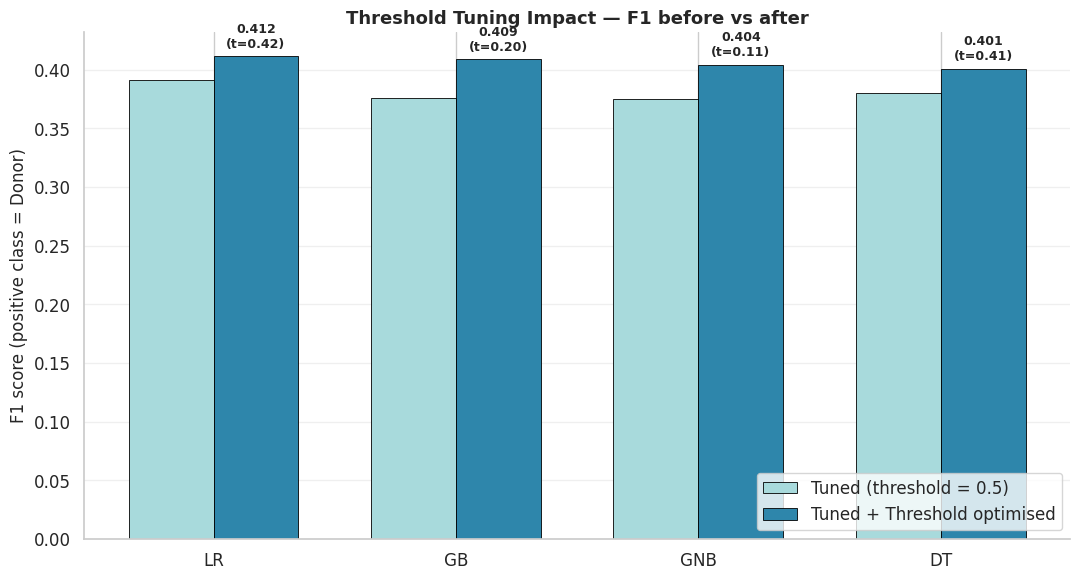


>>> Best model: LR (F1 = 0.4116, threshold = 0.4210) <<<


In [ ]:
# Threshold tuning — impact comparison (before vs after threshold optimisation)
th_df = pd.DataFrame([
    {'Model': name,
     'F1 (tuned)': threshold_results[name]['f1_before_threshold'],
     'F1 (tuned + threshold)': threshold_results[name]['f1_after_threshold'],
     'Best threshold': threshold_results[name]['best_threshold'],
     'Δ F1': threshold_results[name]['delta']}
    for name in finalists
]).sort_values('F1 (tuned + threshold)', ascending=False).reset_index(drop=True)

print("--- After Threshold Tuning (sorted by F1 val) ---")
print(th_df.to_string(index=False))

# Grouped bar chart: F1 at default 0.5 vs F1 at optimal threshold
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(th_df))
width = 0.35
ax.bar(x - width/2, th_df['F1 (tuned)'], width,
       label='Tuned (threshold = 0.5)', color=COLOR_SECONDARY, edgecolor=COLOR_BLACK, linewidth=0.6)
bars_th = ax.bar(x + width/2, th_df['F1 (tuned + threshold)'], width,
                 label='Tuned + Threshold optimised', color=COLOR_PRIMARY, edgecolor=COLOR_BLACK, linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(th_df['Model'])
ax.set_ylabel('F1 score (positive class = Donor)')
ax.set_title('Threshold Tuning Impact — F1 before vs after', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
sns.despine()
for bar, val, thr in zip(bars_th, th_df['F1 (tuned + threshold)'], th_df['Best threshold']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}\n(t={thr:.2f})', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Best finalist after threshold tuning
best_model = th_df.iloc[0]['Model']
best_f1 = th_df.iloc[0]['F1 (tuned + threshold)']
best_threshold = th_df.iloc[0]['Best threshold']
print(f"\n>>> Best model: {best_model} (F1 = {best_f1:.4f}, threshold = {best_threshold:.4f}) <<<")

## Stacking

We combine the four threshold-tuned finalists into a stacking ensemble (Wolpert, 1992, *Neural Networks* 5:241-259). Base learners produce probabilistic outputs that feed a `LogisticRegression` meta-learner, trained on out-of-fold predictions via 5-fold StratifiedKFold (sklearn default `cv=None`).

**Configuration evaluated:** `passthrough=True` (meta receives base predictions + original 25 features), with `class_weight='balanced'` on the meta to handle the raw imbalanced features.

In [ ]:
# Stacking — four threshold-tuned finalists with a LogisticRegression meta-learner.
# passthrough=True feeds the original 25 features alongside the 4 base probabilities
# to the meta; class_weight='balanced' handles the still-imbalanced raw features.
base_learners = [
    ('lr',  tuning_results['LR']['best_estimator']),
    ('gb',  tuning_results['GB']['best_estimator']),
    ('dt',  tuning_results['DT']['best_estimator']),
    ('gnb', tuning_results['GNB']['best_estimator']),
]
final_estimator = LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=GLOBAL_SEED,
)

# Meta-learner trained on out-of-fold base predictions (5-fold)
stacked = StackingClassifier(
    estimators=base_learners, final_estimator=final_estimator,
    cv=cv, passthrough=True,
)

t0 = time.time()
stacked.fit(X_train_clean, y_train)
fit_time = time.time() - t0

# Evaluate on val (single predict call)
y_pred_val = stacked.predict(X_val_clean)
f1_stacked = f1_score(y_val, y_pred_val, pos_label=1)
report = classification_report(y_val, y_pred_val, target_names=['Non-donor', 'Donor'], digits=4)

print(f"Stacking fit time: {fit_time:.1f}s ({fit_time/60:.1f} min)")
print(f"\n=== STACKING (passthrough=True, class_weight=balanced) ===")
print(f"F1 on val: {f1_stacked:.4f}\n")
print(report)

Stacking fit time: 9.5s (0.2 min)

=== STACKING (passthrough=True, class_weight=balanced) ===
F1 on val: 0.3806

              precision    recall  f1-score   support

   Non-donor     0.7888    0.6116    0.6890      2034
       Donor     0.3040    0.5088    0.3806       678

    accuracy                         0.5859      2712
   macro avg     0.5464    0.5602    0.5348      2712
weighted avg     0.6676    0.5859    0.6119      2712



In [ ]:
# Threshold-tune the final ensemble — F1-optimal cut via 5-fold CV on train
stacked_thr = TunedThresholdClassifierCV(
    estimator=stacked, scoring='f1', cv=cv, random_state=GLOBAL_SEED,
)

t0 = time.time()
stacked_thr.fit(X_train_clean, y_train)
fit_time = time.time() - t0

# Evaluate the threshold-tuned ensemble on val
y_pred_val = stacked_thr.predict(X_val_clean)
f1_stacked_thr = f1_score(y_val, y_pred_val, pos_label=1)
report = classification_report(y_val, y_pred_val, target_names=['Non-donor', 'Donor'], digits=4)

print(f"Threshold tuning time: {fit_time:.1f}s ({fit_time/60:.1f} min)")
print(f"\n=== STACKING + THRESHOLD ===")
print(f"Best threshold: {stacked_thr.best_threshold_:.4f}")
print(f"F1 (threshold=0.5): {f1_stacked:.4f}")
print(f"F1 (threshold opt): {f1_stacked_thr:.4f}")
print(f"Δ F1: {f1_stacked_thr - f1_stacked:+.4f}\n")
print(report)

Threshold tuning time: 49.5s (0.8 min)

=== STACKING + THRESHOLD ===
Best threshold: 0.4146
F1 (threshold=0.5): 0.3806
F1 (threshold opt): 0.4157
Δ F1: +0.0351

              precision    recall  f1-score   support

   Non-donor     0.8296    0.2896    0.4293      2034
       Donor     0.2782    0.8215    0.4157       678

    accuracy                         0.4226      2712
   macro avg     0.5539    0.5556    0.4225      2712
weighted avg     0.6917    0.4226    0.4259      2712



--- All candidates (sorted by F1 val) ---
                       Model   F1 val
STACKING (passthrough) + thr 0.415672
                          LR 0.411609
                          GB 0.409107
                         GNB 0.404228
                          DT 0.400775
      STACKING (passthrough) 0.380585


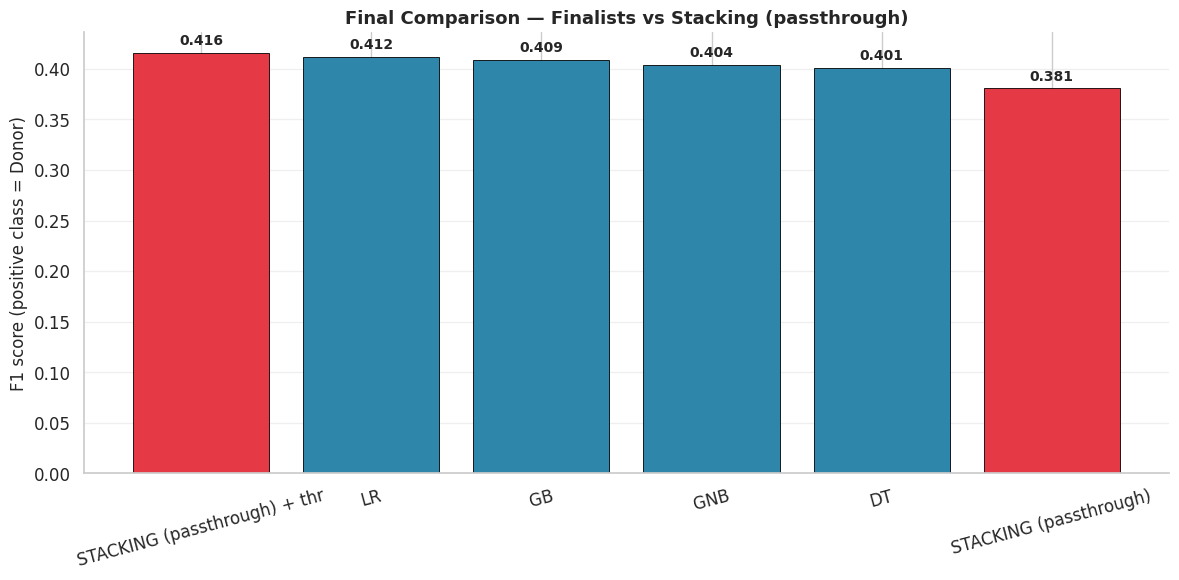


>>> Best model: STACKING (passthrough) + thr (F1 = 0.4157) <<<


In [ ]:
# Final comparison — all finalists (with threshold) vs the stacking ensemble
final_df = pd.DataFrame([
    {'Model': name, 'F1 val': threshold_results[name]['f1_after_threshold']}
    for name in finalists
] + [
    {'Model': 'STACKING (passthrough)',       'F1 val': f1_stacked},
    {'Model': 'STACKING (passthrough) + thr', 'F1 val': f1_stacked_thr},
]).sort_values('F1 val', ascending=False).reset_index(drop=True)

print("--- All candidates (sorted by F1 val) ---")
print(final_df.to_string(index=False))

# Bar chart (stacking variants highlighted in accent colour)
fig, ax = plt.subplots(figsize=(12, 6))
colors = [COLOR_ACCENT if 'STACKING' in m else COLOR_PRIMARY for m in final_df['Model']]
bars = ax.bar(final_df['Model'], final_df['F1 val'],
              color=colors, edgecolor=COLOR_BLACK, linewidth=0.6)
ax.set_ylabel('F1 score (positive class = Donor)')
ax.set_title('Final Comparison — Finalists vs Stacking (passthrough)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, axis='y', alpha=0.3)
sns.despine()
for bar, val in zip(bars, final_df['F1 val']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n>>> Best model: {final_df.iloc[0]['Model']} (F1 = {final_df.iloc[0]['F1 val']:.4f}) <<<")

### Extended Optimization — Sensitivity Analysis (summary)

To confirm the configuration was not leaving performance untapped, we ran an extensive sensitivity analysis (exploratory code removed for readability). All variants were evaluated on the validation set; none surpassed the deployed baseline:

| Variant | F1 (val) |
|---------|----------|
| **Stacking + passthrough + threshold (deployed)** | **0.416** |
| LR — Elastic Net (L1+L2) | 0.412 |
| Stacking without passthrough | 0.412 |
| GB — wide-range Random Search (n_iter=80) | 0.407 |
| GB — extended hyperparameters | 0.404 |
| LR — wide-range Random Search | 0.401 |
| DT — cost-complexity pruning (`ccp_alpha`) | 0.401 |
| F2-weighted threshold | 0.400 |

We also swept SelectKBest `k ∈ {8, …, 40}`; F1 peaked at the deployed `k = 25`, with all variations within ±0.01 — a noisy plateau, not a sharp optimum.

**Conclusion.** Across models, hyperparameters, architectures, regularisation schemes, metrics and feature counts, performance converges to F1 ≈ 0.41. This empirically confirms the problem is *data-limited* (max MI = 0.014, the Bayes-error ceiling), not model-limited — consistent with the difficulty reported for KDD Cup '98-style donor data (Cacciarelli & Boresta, 2022). The degradation under aggressive tuning is itself evidence of CV optimization bias (Cawley & Talbot, 2010): expanding the search space let configurations overfit the validation folds rather than generalise.

### Final Model Selection

We deploy **Stacking with `passthrough=True` + threshold tuning**, selected on validation F1:

| Model | F1 (val) |
|-------|----------|
| **Stacking + passthrough + threshold** | **0.416** |
| LogisticRegression + threshold | 0.412 |
| GradientBoosting (tuned) | 0.409 |
| DecisionTree + threshold | 0.401 |
| GaussianNB + threshold | 0.404 |

The stacking ensemble achieves the highest validation F1. Its architecture is empirically validated by the sensitivity analysis above: `passthrough=True` (meta-learner receives base predictions + the 25 original features) outperforms the no-passthrough variant (0.416 vs 0.381), partially mitigating the plateau "ceiling effect" reported when base learners converge (Peña et al., 2025, *Scientific Reports* 15:29420). The meta-learner uses `class_weight='balanced'`; without it the meta collapses to majority prediction (F1 = 0.02, empirically observed).

**Reproducibility.** All seeds fixed (`random_state=42`, `n_jobs=1`); threshold selected via 5-fold CV on train only; final refit on `X_train + X_val` before Kaggle prediction.

> The business implications of this choice — the recall/precision trade-off and what it means operationally for CSA — are analysed in the Open-Ended Section.

### Decision Diagnostic — ROC Curve

The ROC curve assesses the model's ranking quality independently of the chosen threshold. AUC reflects the probability that a randomly chosen donor receives a higher score than a randomly chosen non-donor — orthogonal to the threshold tuning that drives F1. We compare the deployed stacking ensemble against `LogisticRegression` to confirm both rank donors well before the operating point is fixed.

The confusion matrix and the operational precision/recall trade-off are analysed in the Open-Ended Section, in business terms.

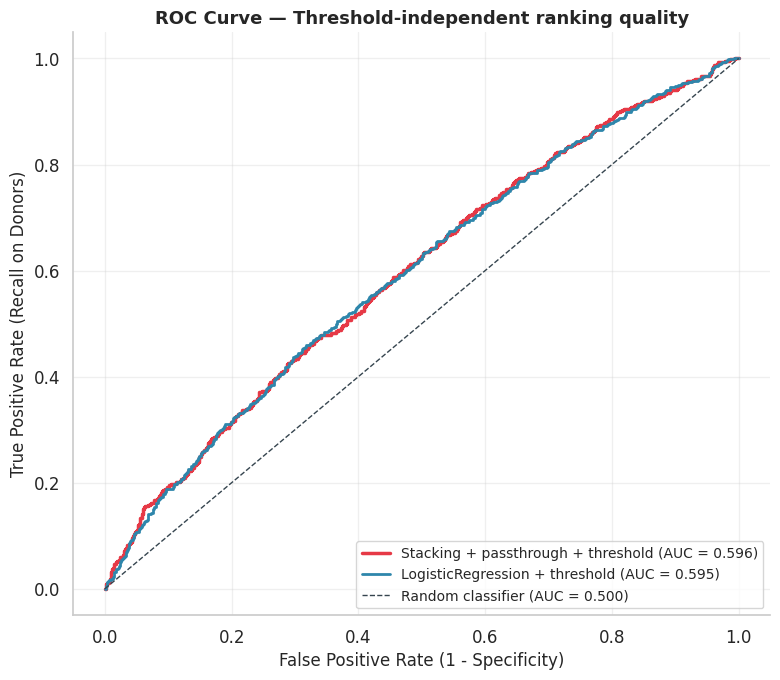

AUC — Stacking + threshold : 0.5962
AUC — LR + threshold       : 0.5949
Δ AUC                       : +0.0013


In [ ]:
# ROC curve — Stacking vs LR + threshold (ranking quality, threshold-independent)
# Predicted probabilities for the positive class (Donor)
y_proba_stacked = stacked_thr.predict_proba(X_val_clean)[:, 1]
y_proba_lr      = threshold_results['LR']['estimator'].predict_proba(X_val_clean)[:, 1]

# ROC curves and AUC for both models
fpr_st, tpr_st, _ = roc_curve(y_val, y_proba_stacked)
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_proba_lr)
auc_stacked = roc_auc_score(y_val, y_proba_stacked)
auc_lr      = roc_auc_score(y_val, y_proba_lr)

# Plot both ROC curves against the random-classifier diagonal
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_st, tpr_st, color=COLOR_ACCENT, linewidth=2.5,
        label=f'Stacking + passthrough + threshold (AUC = {auc_stacked:.3f})')
ax.plot(fpr_lr, tpr_lr, color=COLOR_PRIMARY, linewidth=2,
        label=f'LogisticRegression + threshold (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], color=COLOR_NEUTRAL, linestyle='--', linewidth=1,
        label='Random classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall on Donors)')
ax.set_title('ROC Curve — Threshold-independent ranking quality', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print(f"AUC — Stacking + threshold : {auc_stacked:.4f}")
print(f"AUC — LR + threshold       : {auc_lr:.4f}")
print(f"Δ AUC                       : {auc_stacked - auc_lr:+.4f}")

# IV. Deployment

We deploy the selected model — Stacking with passthrough + threshold tuning — to predict on the unseen Kaggle test set.

**Procedure:**
1. **Load** `donors_test.csv` (as `df_kaggle`), preserving `CONTROL_NUMBER` for the submission.
2. **Preprocess** the test set by applying the *same* fitted transformers from training, in the same sequence — encapsulated in the function `preprocess_test_set()`. No leakage: only `.transform()` is called on the test set.
3. **Refit** the final model on the full development set (`X_train + X_val`): hyperparameters and architecture are already fixed; we simply train on more data for more stable estimates.
4. **Predict** and assemble `DM2NT_Group21__Version01.csv` (columns `CONTROL_NUMBER`, `TARGET_B`).

In [ ]:
# Applies the full preprocessing sequence from Section II.B as a single reusable function.
# Every transformer was fitted ONLY on training data; here we only call .transform().
def preprocess_test_set(df_kaggle):
    """Apply the training-fitted preprocessing sequence to the Kaggle test set.
    Returns X_test_clean (25 features, same order as X_train_clean) and CONTROL_NUMBER."""

    # 0. Preserve CONTROL_NUMBER, drop it from the features
    control_nums = df_kaggle['CONTROL_NUMBER'].copy()
    X = df_kaggle.drop(columns=['CONTROL_NUMBER']).copy()

    # Original continuous features (cont_imputer was fitted on these 27 only;
    # CONTINUOUS_FEATURES was later extended with the engineered features)
    cont_original = FEATURE_TYPES['continuous']

    # 1. Invalid handling — same whitelist rules from the codebook
    X = clean_invalid_features(X, numeric_continuous_rules)
    X = clean_ordinal_whitelist(X, ordinal_valid_values)
    X = clean_children(X)
    X = clean_invalid_features(X, binary_rules)
    X = clean_categorical_whitelist(X, categorical_valid_values)

    # 2. Imputation — fitted imputers (original continuous features only)
    X[BINARY_FEATURES]      = bin_imputer.transform(X[BINARY_FEATURES])
    X[ORDINAL_FEATURES]     = ord_imputer.transform(X[ORDINAL_FEATURES])
    X[cont_original]        = cont_imputer.transform(X[cont_original])
    X[CATEGORICAL_FEATURES] = cat_imputer.transform(X[CATEGORICAL_FEATURES])

    # 3. Feature engineering — same four derived features (after imputation)
    X['LIFETIME_RESPONSE_RATE'] = np.where(X['LIFETIME_PROM'] > 0,
                                           X['LIFETIME_GIFT_COUNT'] / X['LIFETIME_PROM'], 0.0)
    X['DONOR_LIFESPAN_MONTHS']  = X['MONTHS_SINCE_FIRST_GIFT'] - X['MONTHS_SINCE_LAST_GIFT']
    X['GIFT_AMOUNT_TREND']      = X['LAST_GIFT_AMT'] - X['RECENT_AVG_GIFT_AMT']
    X['GIFT_RANGE']             = X['LIFETIME_MAX_GIFT_AMT'] - X['LIFETIME_MIN_GIFT_AMT']

    # Re-impute impossible engineered values (same engineered imputer)
    X.loc[X['LIFETIME_RESPONSE_RATE'] > 1, 'LIFETIME_RESPONSE_RATE'] = np.nan
    X.loc[X['DONOR_LIFESPAN_MONTHS'] < 0,  'DONOR_LIFESPAN_MONTHS']  = np.nan
    X.loc[X['GIFT_RANGE'] < 0,             'GIFT_RANGE']             = np.nan
    X[ENGINEERED_FEATURES] = eng_imputer.transform(X[ENGINEERED_FEATURES])

    # 4. Log transformation — same dynamic feature list learned on train
    for col in log_transform_features:
        X[col] = np.log1p(X[col])

    # 5. Robust scaling — fitted scaler (full CONTINUOUS_FEATURES, incl. engineered)
    X[CONTINUOUS_FEATURES] = scaler.transform(X[CONTINUOUS_FEATURES])

    # 6. Encoding — fitted ordinal + one-hot encoders
    X[ORDINAL_FEATURES] = ord_encoder.transform(X[ORDINAL_FEATURES])
    if X[ORDINAL_FEATURES].isna().any().any():           # unseen-category safety net
        X[ORDINAL_FEATURES] = ord_imputer.transform(X[ORDINAL_FEATURES])
    ohe_arr = ohe.transform(X[CATEGORICAL_FEATURES])
    ohe_df  = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(CATEGORICAL_FEATURES), index=X.index)
    X = pd.concat([X.drop(columns=CATEGORICAL_FEATURES), ohe_df], axis=1)

    # 7. Feature selection — same kept columns from each filter stage
    X = X[cols_kept_var]    # Stage 1 — Variance Threshold
    X = X[cols_kept_corr]   # Stage 2 — Correlation Redundancy
    X = X[cols_kept_mi]     # Stage 3 — SelectKBest (k=25)

    return X, control_nums

print("preprocess_test_set() defined.")

preprocess_test_set() defined.


In [ ]:
# Apply the full preprocessing sequence to the Kaggle test set (loaded earlier as df_kaggle)
print(f"Kaggle test set: {df_kaggle.shape[0]} rows x {df_kaggle.shape[1]} columns")

assert 'CONTROL_NUMBER' in df_kaggle.columns, "CONTROL_NUMBER missing from test set."

X_test_clean, control_nums = preprocess_test_set(df_kaggle)

# Sanity checks — must match the training feature structure exactly
assert list(X_test_clean.columns) == list(X_train_clean.columns), "Feature columns/order mismatch."
assert not X_test_clean.isna().any().any(), "Residual NaNs in X_test_clean."

print(f"X_test_clean shape : {X_test_clean.shape}")
print(f"X_train_clean (ref): {X_train_clean.shape}")
print(f"CONTROL_NUMBER kept: {len(control_nums)} ids")
print("All checks passed — test set ready for prediction.")

Kaggle test set: 5812 rows x 40 columns
X_test_clean shape : (5812, 25)
X_train_clean (ref): (10848, 25)
CONTROL_NUMBER kept: 5812 ids
All checks passed — test set ready for prediction.


### Refit on Train + Validation combined

The validation set has served its purpose (model and threshold selection). We now refit the final model on the full development set for more stable parameter estimates — standard practice before deployment. The configuration is identical to the one selected on validation.

In [ ]:
# Combine train + val into the full development set (hyperparameters already fixed)
X_full = pd.concat([X_train_clean, X_val_clean], axis=0)
y_full = pd.concat([y_train,       y_val],       axis=0)
print(f"Combined development set: {X_full.shape[0]} rows")

# Rebuild the deployed model with the same configuration selected on validation
base_learners_final = [
    ('lr',  tuning_results['LR']['best_estimator']),
    ('gb',  tuning_results['GB']['best_estimator']),
    ('dt',  tuning_results['DT']['best_estimator']),
    ('gnb', tuning_results['GNB']['best_estimator']),
]
stacked_final = StackingClassifier(
    estimators=base_learners_final,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=GLOBAL_SEED),
    cv=cv, passthrough=True,
)
stacked_thr_final = TunedThresholdClassifierCV(
    estimator=stacked_final, scoring='f1', cv=cv, random_state=GLOBAL_SEED,
)

# Refit on the full development set for more stable estimates
t0 = time.time()
stacked_thr_final.fit(X_full, y_full)
print(f"Final model refitted in {(time.time()-t0)/60:.1f} min.")
print(f"Threshold (combined set): {stacked_thr_final.best_threshold_:.4f}")

Combined development set: 13560 rows
Final model refitted in 1.0 min.
Threshold (combined set): 0.4364


### Kaggle Submission

We predict on the test set with the refitted model and assemble the submission in the required format (`CONTROL_NUMBER`, `TARGET_B`), saved as `DM2NT_Group21__Version01.csv` to the project drive for upload to Kaggle.

**Note on the predicted donor share.** The model flags a high proportion of the test set as donors (around 65%), well above the 25% prevalence. This is expected, not an error: the recall-favouring threshold (0.41) combined with `class_weight='balanced'` makes the model cast a wide net to capture most true donors (recall 0.82) at the cost of low precision (0.28). The same behaviour appears on validation (around 74% predicted as donor), confirming consistency. This recall/precision trade-off is analysed in the Open-Ended Section.

In [ ]:
# Predict on the test set and build the submission file
y_test_pred = stacked_thr_final.predict(X_test_clean)

submission = pd.DataFrame({
    'CONTROL_NUMBER': control_nums.values,
    'TARGET_B':       y_test_pred.astype(int),
})

# Sanity checks — row count and binary target
assert len(submission) == len(df_kaggle), "Row count mismatch with test set."
assert submission['TARGET_B'].isin([0, 1]).all(), "TARGET_B has non-binary values."

# Save the submission (DMII Noturno, Group 21)
output_path = '/content/drive/MyDrive/DM2_Project/DM2NT_Group21__Version01.csv'
submission.to_csv(output_path, index=False)

# Report predicted class distribution vs training reference
n_donors = submission['TARGET_B'].sum()
print(f"Submission saved: {output_path}")
print(f"Predicted donors    : {n_donors} ({100*n_donors/len(submission):.1f}%)")
print(f"Predicted non-donors: {len(submission)-n_donors} ({100*(1-n_donors/len(submission)):.1f}%)")
print(f"Training donor rate : {100*y_full.mean():.1f}%  (reference)")
print("\nReady for Kaggle upload.")

Submission saved: /content/drive/MyDrive/DM2_Project/DM2NT_Group21__Version01.csv
Predicted donors    : 3797 (65.3%)
Predicted non-donors: 2015 (34.7%)
Training donor rate : 25.0%  (reference)

Ready for Kaggle upload.


# V. Open-Ended Section

## Objective

Section III selected the model using F1, a single balanced metric. This section goes beyond the pipeline to ask questions F1 cannot answer:

1. **What does the model's operating point mean for CSA in practice** — how many donors are recovered versus how many contacts are wasted (recall/precision trade-off)?
2. **Which features drive the predictions**, and how concentrated is the predictive signal?
3. **Which donors does the model fail on**, and is that failure structural or fixable?

We then synthesise these into a business recommendation for CSA's outreach strategy (Section 4). Together they reframe a technical score as a business decision, characterise the limits of what is learnable from the data, and translate the model into actionable guidance.

## 1. Operational Impact — Recall vs Precision

We compare the two strongest candidates — the deployed **stacking ensemble** and **LogisticRegression + threshold** — on the held-out validation set, then project the rates onto the Kaggle test set (5,812 individuals CSA will actually contact). The two operate at close points (recall 0.82 vs 0.81); the comparison quantifies the marginal donors the stacking model recovers and at what cost in wasted contacts.

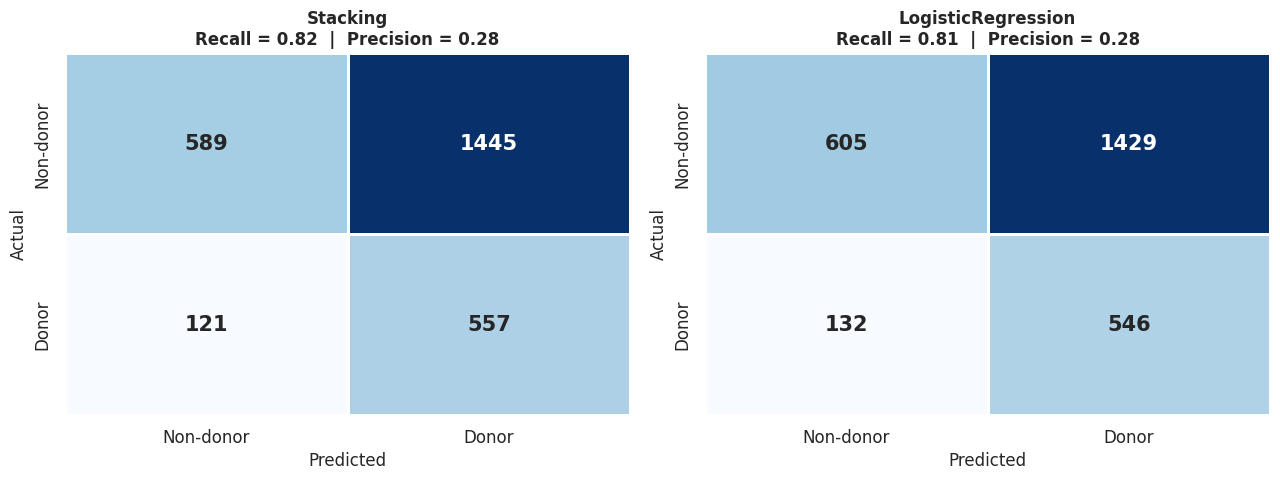

--- Validation comparison (Stacking vs LogisticRegression) ---
Metric                          Stacking          LR  Difference
Donors caught (TP)                   557         546         +11
Donors missed (FN)                   121         132         -11
Wasted contacts (FP)                1445        1429         +16
Recall (donors)                    0.822       0.805      +0.016
Precision (donors)                 0.278       0.276      +0.002

--- Stacking projected onto the test set (5812 individuals, ~25% donor rate) ---
  Expected donors        : 1453
  Donors identified (TP) : 1194
  Donors missed (FN)     : 259
  Total contacts made    : 4290
  Wasted contacts (FP)   : 3097


In [ ]:
# Compare the two strongest candidates on the held-out validation set.
# Honest evaluation: both trained on train only, val never seen.
y_pred_stacked = stacked_thr.predict(X_val_clean)
y_pred_lr      = threshold_results['LR']['estimator'].predict(X_val_clean)

# Confusion matrices and donor-class rates for each model
results = {}
for label, y_pred in [('Stacking', y_pred_stacked), ('LogisticRegression', y_pred_lr)]:
    cm = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results[label] = {
        'cm': cm, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'recall': tp / (tp + fn), 'precision': tp / (tp + fp),
    }

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, r) in zip(axes, results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap=CMAP_SEQUENTIAL,
                xticklabels=['Non-donor', 'Donor'], yticklabels=['Non-donor', 'Donor'],
                cbar=False, linewidths=0.8, linecolor='white',
                annot_kws={'size': 15, 'weight': 'bold'}, ax=ax)
    ax.set_title(f'{label}\nRecall = {r["recall"]:.2f}  |  Precision = {r["precision"]:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Numeric comparison: donors caught/missed and contacts wasted (validation)
print("--- Validation comparison (Stacking vs LogisticRegression) ---")
print(f"{'Metric':<28}{'Stacking':>12}{'LR':>12}{'Difference':>12}")
st, lr = results['Stacking'], results['LogisticRegression']
print(f"{'Donors caught (TP)':<28}{st['tp']:>12}{lr['tp']:>12}{st['tp']-lr['tp']:>+12}")
print(f"{'Donors missed (FN)':<28}{st['fn']:>12}{lr['fn']:>12}{st['fn']-lr['fn']:>+12}")
print(f"{'Wasted contacts (FP)':<28}{st['fp']:>12}{lr['fp']:>12}{st['fp']-lr['fp']:>+12}")
print(f"{'Recall (donors)':<28}{st['recall']:>12.3f}{lr['recall']:>12.3f}{st['recall']-lr['recall']:>+12.3f}")
print(f"{'Precision (donors)':<28}{st['precision']:>12.3f}{lr['precision']:>12.3f}{st['precision']-lr['precision']:>+12.3f}")

# Project the Stacking rates onto the Kaggle test set (deployment scale)
n_test     = len(X_test_clean)
donor_rate = y_full.mean()
exp_donors   = n_test * donor_rate
exp_caught   = exp_donors * st['recall']
exp_missed   = exp_donors * (1 - st['recall'])
exp_contacts = exp_caught / st['precision']
exp_wasted   = exp_contacts - exp_caught

print(f"\n--- Stacking projected onto the test set ({n_test} individuals, ~{donor_rate:.0%} donor rate) ---")
print(f"  Expected donors        : {exp_donors:.0f}")
print(f"  Donors identified (TP) : {exp_caught:.0f}")
print(f"  Donors missed (FN)     : {exp_missed:.0f}")
print(f"  Total contacts made    : {exp_contacts:.0f}")
print(f"  Wasted contacts (FP)   : {exp_wasted:.0f}")

### Why recall is the operationally consequential metric

The two error types are not symmetric in cost for CSA:

- **A missed donor (false negative)** = a lost donation *and* the lost lifetime value of that relationship — someone willing to give who was never contacted.
- **A wasted contact (false positive)** = one unsolicited email or call to a non-donor — marginal, near-zero cost, and recoverable (they can be contacted again later).

Because a missed donor is far costlier than a wasted contact, an operating point favouring **recall** aligns with CSA's mission of maximising funds raised. The deployed model's high recall means it captures most of the donor base, accepting cheap wasted contacts in exchange — the right trade for a low-cost-outreach charity.

### Strategic scenarios — the threshold as a business lever

The decision threshold is tunable, not fixed. CSA can shift the operating point to match its constraints without retraining:

- **Tight outreach budget** → raise the threshold → higher precision, fewer wasted contacts, but fewer donors captured. Appropriate when each contact has real cost (e.g. physical mail).
- **Growth / fundraising drive** → lower the threshold → higher recall, more donors captured, more (cheap) wasted contacts accepted. Appropriate for low-cost channels (email).

The deployed threshold sits in the recall-favouring region — the default-appropriate choice given CSA's low-cost outreach.

## 2. Feature Importance — What Drives the Predictions

We measure feature importance via **permutation importance** (Breiman, 2001) on the deployed stacking ensemble: each feature is randomly shuffled and the resulting drop in validation F1 is recorded. A large drop means the model relies heavily on that feature; a negligible drop means the feature carries little signal. This is model-agnostic (it treats the whole stacking ensemble as a black box) and directly interpretable. Crucially, it also tests the *data-limited* hypothesis: if even the top feature causes only a small F1 drop when shuffled, no single feature is decisive — consistent with a weak overall signal.**bold text**

--- Permutation importance (mean F1 drop when shuffled) ---
                  Feature  Importance      Std
             INCOME_GROUP    0.009870 0.004873
   MONTHS_SINCE_LAST_GIFT    0.005848 0.002814
        GIFT_AMOUNT_TREND    0.005271 0.002151
            LAST_GIFT_AMT    0.004281 0.002441
       PCT_OWNER_OCCUPIED    0.003214 0.001002
           FILE_CARD_GIFT    0.002961 0.003159
      RECENT_AVG_GIFT_AMT    0.002818 0.001568
             CARD_PROM_12    0.002775 0.002157
RECENT_CARD_RESPONSE_PROP    0.002643 0.001405
   LIFETIME_RESPONSE_RATE    0.002578 0.001163
    LIFETIME_MIN_GIFT_AMT    0.002527 0.000935
     RECENT_RESPONSE_PROP    0.002466 0.001296
 RECENT_AVG_CARD_GIFT_AMT    0.002464 0.001321
           PCT_ATTRIBUTE4    0.001595 0.003099
               GIFT_RANGE    0.001465 0.001283


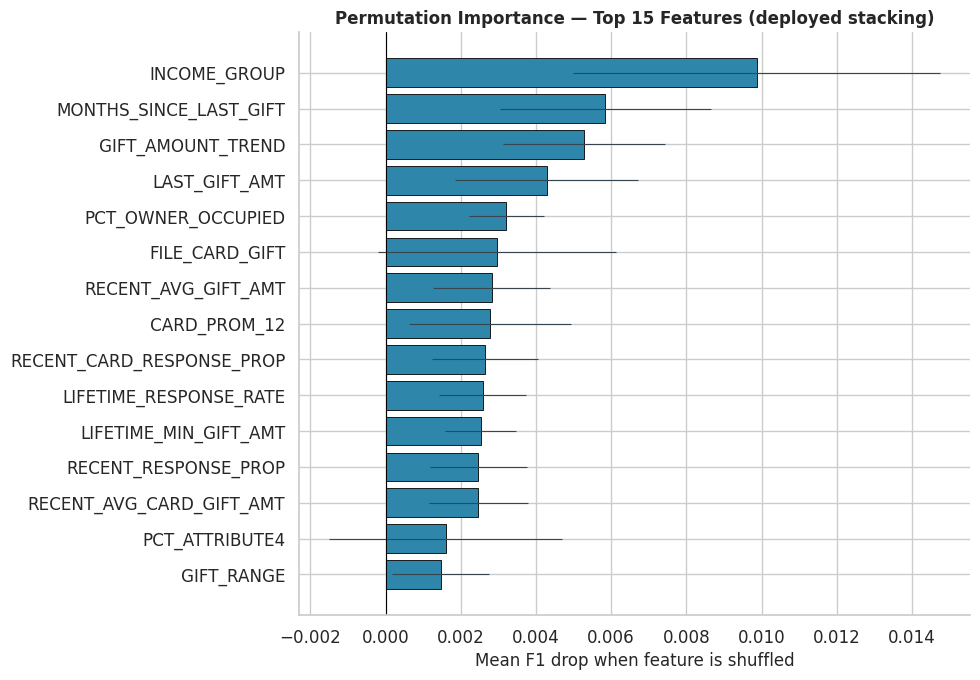


Most important feature: INCOME_GROUP (F1 drop = 0.0099)
Top-5 features account for 47% of total positive importance.


In [ ]:
# Feature importance via permutation: shuffle each feature, measure the drop in F1.
# Model-agnostic — treats the whole stacking ensemble as a black box (Breiman 2001).
from sklearn.inspection import permutation_importance

# Run on the held-out validation set (honest: model never saw it)
perm = permutation_importance(
    stacked_thr, X_val_clean, y_val,
    scoring='f1', n_repeats=10, random_state=GLOBAL_SEED, n_jobs=N_JOBS,
)

# Rank features by mean F1 drop when shuffled
importance_df = pd.DataFrame({
    'Feature': X_val_clean.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std,
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- Permutation importance (mean F1 drop when shuffled) ---")
print(importance_df.head(15).to_string(index=False))

# Plot the top 15 features by importance
top15 = importance_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15['Feature'], top15['Importance'],
        xerr=top15['Std'], color=COLOR_PRIMARY, edgecolor=COLOR_BLACK,
        linewidth=0.6, error_kw={'elinewidth': 0.8, 'ecolor': COLOR_NEUTRAL})
ax.axvline(x=0, color=COLOR_BLACK, linewidth=0.8)
ax.set_xlabel('Mean F1 drop when feature is shuffled')
ax.set_title('Permutation Importance — Top 15 Features (deployed stacking)',
             fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

# Summary: how concentrated is the signal?
top_feat = importance_df.iloc[0]
print(f"\nMost important feature: {top_feat['Feature']} (F1 drop = {top_feat['Importance']:.4f})")
print(f"Top-5 features account for "
      f"{100 * importance_df['Importance'].head(5).sum() / importance_df['Importance'].clip(lower=0).sum():.0f}% "
      f"of total positive importance.")

## 3. Error Analysis — Who the Model Misses

We compare the donors the model correctly identifies (true positives) against those it misses (false negatives), on the validation set. We focus on the most important features (from the permutation analysis above). If missed donors form a coherent profile, their misclassification is *structural* — they are genuinely indistinguishable from non-donors given the available features.

--- Mean feature values: Caught vs Missed donors (original units) ---
_group                  Caught (TP)  Missed (FN)  Difference
INCOME_GROUP                   3.10         2.92        0.18
MONTHS_SINCE_LAST_GIFT        16.89        20.80       -3.91
GIFT_AMOUNT_TREND              1.08         1.21       -0.12
LAST_GIFT_AMT                 14.03        21.01       -6.98
PCT_OWNER_OCCUPIED            71.27        73.33       -2.06
FILE_CARD_GIFT                 6.61         2.24        4.37
RECENT_AVG_GIFT_AMT           12.94        19.80       -6.85
CARD_PROM_12                   5.58         4.88        0.70


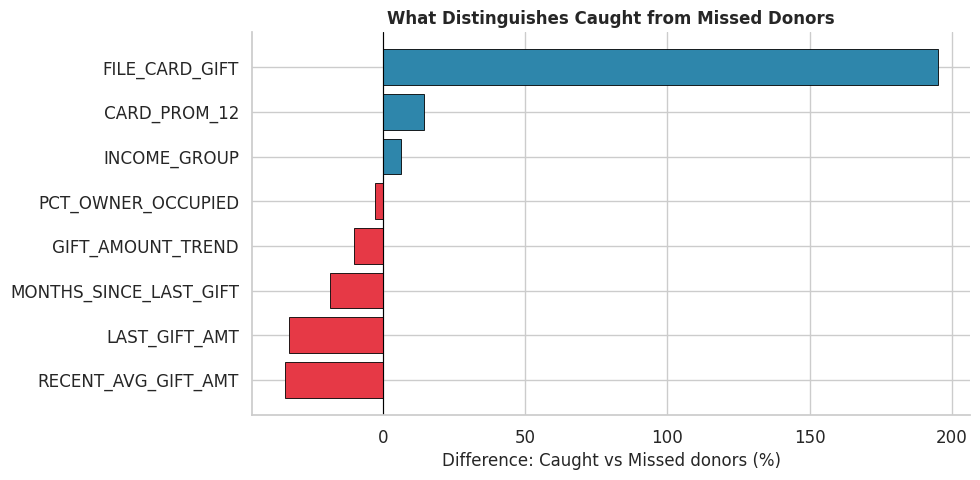

In [ ]:
# Error analysis — compare caught vs missed donors in ORIGINAL units (interpretable)
y_pred_val  = stacked_thr.predict(X_val_clean)
donor_mask  = (y_val == 1).values
pred_donors = y_pred_val[donor_mask]
X_donors    = X_val_clean[donor_mask].copy()

# Undo preprocessing (RobustScaler, then log1p) to recover human-readable values
def to_original_units(X_scaled):
    X = X_scaled.copy()
    cont = [c for c in CONTINUOUS_FEATURES if c in X.columns]
    if cont:                                      # undo RobustScaler: x * IQR + median
        idx = [CONTINUOUS_FEATURES.index(c) for c in cont]
        X[cont] = X[cont] * scaler.scale_[idx] + scaler.center_[idx]
    for col in [c for c in log_transform_features if c in X.columns]:
        X[col] = np.expm1(X[col])                 # undo log1p
    return X

X_orig = to_original_units(X_donors)
X_orig['_group'] = np.where(pred_donors == 1, 'Caught (TP)', 'Missed (FN)')

# Mean feature values for caught vs missed donors (most predictive features)
top_feats = [f for f in importance_df['Feature'].head(8) if f in X_orig.columns] \
            if 'importance_df' in dir() else \
            ['LIFETIME_RESPONSE_RATE', 'RECENT_RESPONSE_COUNT', 'LAST_GIFT_AMT',
             'FREQUENCY_STATUS_97NK', 'MONTHS_SINCE_LAST_GIFT', 'LIFETIME_GIFT_COUNT']
top_feats = [f for f in top_feats if f in X_orig.columns]

comp = X_orig.groupby('_group')[top_feats].mean().T
comp['Difference'] = comp['Caught (TP)'] - comp['Missed (FN)']
print("--- Mean feature values: Caught vs Missed donors (original units) ---")
print(comp.round(2).to_string())

# Plot the relative gap (% difference) across features of different scales
fig, ax = plt.subplots(figsize=(10, 5))
rel = ((comp['Caught (TP)'] - comp['Missed (FN)']) / comp['Missed (FN)'].abs().replace(0, np.nan) * 100)
rel = rel.sort_values()
colors = [COLOR_PRIMARY if v > 0 else COLOR_ACCENT for v in rel]
ax.barh(rel.index, rel.values, color=colors, edgecolor=COLOR_BLACK, linewidth=0.6)
ax.axvline(x=0, color=COLOR_BLACK, linewidth=0.8)
ax.set_xlabel('Difference: Caught vs Missed donors (%)')
ax.set_title('What Distinguishes Caught from Missed Donors', fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 4. Conclusion — Key Takeaways

This open-ended analysis reframed the model not as an F1 score, but as a business tool for CSA, yielding three takeaways:

**1. The metric must match the cost structure.** F1 alone treats the stacking ensemble and LogisticRegression as near-equivalent — and indeed their operating points are close (recall 0.82 vs 0.81). The stacking model recovers marginally more donors (+11 on validation) at the cost of slightly more wasted contacts (+16) — a favourable trade for a low-cost-outreach charity, where a missed donor is far costlier than a cheap, recoverable contact. The threshold remains a lever CSA can shift as its budget and channels change.

**2. The errors are structural, not fixable by modelling.** Caught and missed donors are not cleanly separable on the most important features: missed donors actually show *higher* `LAST_GIFT_AMT` and `RECENT_AVG_GIFT_AMT` than caught ones, while caught donors are distinguished mainly by card-response history (`FILE_CARD_GIFT`). The model reliably identifies card-responsive donors but misses high-value, card-inactive ones — a limit of the available features, not a modelling deficiency.

**3. The signal is genuinely weak, confirming the data-limited regime.** Permutation importance shows no single feature is decisive: the most important (`INCOME_GROUP`) degrades validation F1 by only 0.01 when shuffled. This mirrors the maximum mutual information of 0.014 found in feature selection and the plateau seen across all optimization experiments. The F1 ceiling (~0.42, confirmed on Kaggle) reflects the dataset's intrinsic limits, consistent with KDD Cup '98-style donor data (Cacciarelli & Boresta, 2022).

**Practical recommendation for CSA.** The deployed model is best used as a *prioritisation* tool, not a hard filter: it reliably ranks individuals by donation propensity, letting CSA focus limited outreach on the highest-probability segment while accepting that, on this data, perfect separation is unattainable. Richer behavioural or transactional features — beyond the area-level census attributes that proved near-irrelevant — would be the most promising path to lifting the ceiling.